# **INSTALL**

In [ ]:
!!pip install osmnx networkx
!!pip install osmnx networkx matplotlib
!!pip install geopy
!!pip install pandas osmnx networkx geopy folium
!!pip install tabulate
!!pip install osmnx networkx matplotlib numpy

['Requirement already satisfied: osmnx in /usr/local/lib/python3.11/dist-packages (2.0.5)',
 'Requirement already satisfied: networkx in /usr/local/lib/python3.11/dist-packages (3.5)',
 'Requirement already satisfied: matplotlib in /usr/local/lib/python3.11/dist-packages (3.10.0)',
 'Requirement already satisfied: numpy in /usr/local/lib/python3.11/dist-packages (2.0.2)',
 'Requirement already satisfied: geopandas>=1.0.1 in /usr/local/lib/python3.11/dist-packages (from osmnx) (1.1.1)',
 'Requirement already satisfied: pandas>=1.4 in /usr/local/lib/python3.11/dist-packages (from osmnx) (2.2.2)',
 'Requirement already satisfied: requests>=2.27 in /usr/local/lib/python3.11/dist-packages (from osmnx) (2.32.3)',
 'Requirement already satisfied: shapely>=2.0 in /usr/local/lib/python3.11/dist-packages (from osmnx) (2.1.1)',
 'Requirement already satisfied: contourpy>=1.0.1 in /usr/local/lib/python3.11/dist-packages (from matplotlib) (1.3.3)',
 'Requirement already satisfied: cycler>=0.10 in /

# **LIBRARIES**

In [ ]:
import math
import time
import heapq
import random
import folium
import numpy as np
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from time import time
from math import sqrt
from tqdm import tqdm
from folium import Element
from rich.table import Table
from tabulate import tabulate
from collections import deque
from rich.console import Console
from branca.element import Element
from geopy.distance import great_circle
from sklearn.model_selection import KFold

In [ ]:
BOLD = "\033[1m"
ITALIC = "\033[3m"
RESET = "\033[0m"
WHITE = "\033[37m"
GREEN = "\033[32m"
BLUE = "\033[34m"
RED = "\033[31m"
def bold(text):
    return f"{BOLD}{text}{RESET}"
def italic(text):
    return f"{ITALIC}{text}{RESET}"
def bold_red(text):
    return f"{BOLD}{RED}{text}{RESET}"
def white(text):
    return f"{WHITE}{text}{RESET}"
def green(text):
    return f"{GREEN}{text}{RESET}"
def blue(text):
    return f"{BLUE}{text}{RESET}"
def bold_green(text):
    return f"{BOLD}{GREEN}{text}{RESET}"

# **ALGORITMA TESTING DATASET TOTAL**

## ***DJIKSTRA***

In [ ]:
def input_coordinates():
    print(f"{BOLD}{GREEN}{'ENTER THE COORDINATE OF THE POINTS'}{RESET} {BOLD}{RED}{'LATITUDE / LONGITUDE'}{RESET} {BOLD}{GREEN}{'ONE BY ONE.'}{RESET}")
    print(f"{BOLD}{GREEN}TYPE{RESET} {BOLD}{RED}{'DONE'}{RESET} {BOLD}{GREEN}WHEN FINISHED.{RESET}\n")
    print(bold("=" * 42) + "\n")

    coordinates = []
    while True:
        lat_input = input(bold_green("LATITUDE  = ")).strip()
        if lat_input.lower() == 'done':
            print()
            print(bold("=" * 42 + "\n"))
            break

        lon_input = input(bold_green("LONGITUDE = ")).strip()

        try:
            lat_val = float(lat_input)
            lon_val = float(lon_input)
        except ValueError:
            print(bold_red("INVALID INPUT. PLEASE ENTER NUMERIC VALUES FOR LATITUDE AND LONGITUDE!\n"))
            continue

        coordinates.append((lat_val, lon_val))

        print()

    if len(coordinates) < 2:
        print(bold_red("NEED AT LEAST TWO COORDINATES TO COMPUTE ROUTES!!!"))
        return None

    return coordinates

def calculate_routes(coordinates):

    print(f"{BOLD}{GREEN}{'LOADING ROAD NETWORK GRAPH...'}{RESET} {BOLD}{ITALIC}{'THIS MIGHT TAKE A FEW SECONDS'}{RESET}")

    start_time = time.time()
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)
    load_graph_time = time.time() - start_time
    print()
    print(f"{BOLD}{GREEN}{'ROAD NETWORK GRAPH LOADED IN'}{RESET} {BOLD}{RED}{ITALIC}{load_graph_time:.2f}{RESET} {BOLD}{GREEN}{'SECONDS'}.{RESET}\n")
    print(bold("=" * 42) + "\n")

    route_calc_start = time.time()
    routes_info = []

    for i in range(len(coordinates)-1):
        start_coords = coordinates[i]
        end_coords = coordinates[i+1]

        start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
        end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])

        try:
            route = nx.dijkstra_path(G, start_node, end_node, weight='length')
        except nx.NetworkXNoPath:
            print(bold_red(f"NO PATH FOUND BETWEEN POINT {i} AND POINT {i+1}. SKIPPING ROUTE."))
            continue

        total_distance = 0
        for j in range(1, len(route)):
            u = route[j-1]
            v = route[j]
            edge_data = G.get_edge_data(u, v)
            if edge_data:
                edge_length = edge_data[list(edge_data.keys())[0]]['length']
                total_distance += edge_length

        total_distance_km = total_distance / 1000

        walking_speed_kmh = 5
        vehicle_speed_kmh = 40

        walking_time_min = (total_distance_km / walking_speed_kmh) * 60
        vehicle_time_min = (total_distance_km / vehicle_speed_kmh) * 60

        routes_info.append({
            'index': i,
            'from_point': i,
            'to_point': i+1,
            'distance_km': total_distance_km,
            'walking_time_min': walking_time_min,
            'vehicle_time_min': vehicle_time_min,
            'route_nodes': route
        })

        print(bold_green(f"📍ROUTE FROM POINT {i} → POINT {i+1} : {bold_red(f'{total_distance_km:.2f}')} KM\n"))
        print(bold_green(f"ESTIMATED WALKING TIME          : {bold_red(f'{walking_time_min:.1f}')} MINUTES\n"))
        print(bold_green(f"ESTIMATED VEHICLE TIME          : {bold_red(f'{vehicle_time_min:.1f}')} MINUTES\n"))

    route_calc_time = time.time() - route_calc_start
    print(bold("=" * 42) + "\n")
    print(bold_green(f"ROUTE CALCULATION TOOK {bold_red(f'{route_calc_time:.2f}')} SECONDS.\n"))
    print(bold("=" * 42) + "\n")

    return G, routes_info, coordinates

def visualize_routes_with_legend(coordinates, G, routes_info):
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    for idx, coord in enumerate(coordinates):
        folium.Marker(
            location=coord,
            popup=f"Point {idx}",
            icon=folium.Icon(color='green' if idx == 0 else 'red')
        ).add_to(m)

    for info in routes_info:
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        popup_text = f"Route {info['from_point']} to {info['to_point']}"
        folium.PolyLine(
            route_coords,
            color='blue',
            weight=5,
            opacity=0.7,
            popup=popup_text
        ).add_to(m)

    legend_html = '''
    <div style="
        position: fixed;
        bottom: 30px; left: 30px; width: 280px; max-height: 350px;
        background-color: #f9f9f9;
        border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.3);
        padding: 15px 20px;
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        font-size: 14px;
        color: #333;
        overflow-y: auto;
        z-index: 9999;
    ">
        <h4 style="margin-top:0; margin-bottom: 15px; font-weight: 700; border-bottom: 2px solid #4a90e2; padding-bottom: 5px; color: #4a90e2;">
            🗺️Route DJIKSTRA
        </h4>
    '''
    for info in routes_info:
        legend_html += f'''
        <div style="margin-bottom:12px; padding-bottom:8px; border-bottom: 1px solid #ddd;">
            <strong style="color:#2a7ae2;">Route {info['from_point']} → {info['to_point']}:</strong><br>
            Distance       : <span style="font-weight:600;">{info['distance_km']:.2f} km</span><br>
            Walking time   : <span style="font-weight:600;">{info['walking_time_min']:.1f} minutes</span><br>
            Vehicle time   : <span style="font-weight:600;">{info['vehicle_time_min']:.1f} minutes</span>
        </div>
        '''
    legend_html += '</div>'

    legend = Element(legend_html)
    m.get_root().html.add_child(legend)

    output_file = "ROUTE DJIKSTRA.html"
    m.save(output_file)
    print(f"Map saved to '{output_file}'.")

def main():
    coordinates = input_coordinates()
    if not coordinates:
        return
    G, routes_info, coordinates = calculate_routes(coordinates)
    visualize_routes_with_legend(coordinates, G, routes_info)

if __name__ == "__main__":
    main()


ENTER THE COORDINATE OF THE POINTS LATITUDE / LONGITUDE ONE BY ONE.
TYPE DONE WHEN FINISHED.


LATITUDE  = -8.1776808
LONGITUDE = 112.9949491

LATITUDE  = -8.1793287
LONGITUDE = 112.9978534

LATITUDE  = -8.1732222
LONGITUDE = 112.9894703

LATITUDE  = -8.1760873
LONGITUDE = 112.9840059

LATITUDE  = -8.1780388
LONGITUDE = 112.9822286

LATITUDE  = -8.204333	
LONGITUDE = 112.9894642

LATITUDE  = DONE


LOADING ROAD NETWORK GRAPH... THIS MIGHT TAKE A FEW SECONDS

ROAD NETWORK GRAPH LOADED IN 5.04 SECONDS.


📍ROUTE FROM POINT 0 → POINT 1 : 0.56 KM

ESTIMATED WALKING TIME          : 6.7 MINUTES

ESTIMATED VEHICLE TIME          : 0.8 MINUTES

📍ROUTE FROM POINT 1 → POINT 2 : 1.49 KM

ESTIMATED WALKING TIME          : 17.9 MINUTES

ESTIMATED VEHICLE TIME          : 2.2 MINUTES

📍ROUTE FROM POINT 2 → POINT 3 : 0.91 KM

ESTIMATED WALKING TIME          : 10.9 MINUTES

ESTIMATED VEHICLE TIME          : 1.4 MINUTES

📍ROUTE FROM POINT 3 → POINT 4 : 0.51 KM

ESTIMATED WALKING TIME          : 6.1 MINUTE

### **TRIALS**

In [ ]:
def generate_random_coordinates(center, radius_km, n):
    coordinates = []
    lat_center, lon_center = center
    for _ in range(n):
        angle = random.uniform(0, 2 * math.pi)
        radius = random.uniform(0, radius_km)

        delta_lat = (radius / 111) * math.cos(angle)
        delta_lon = (radius / (111 * math.cos(math.radians(lat_center)))) * math.sin(angle)

        coordinates.append((lat_center + delta_lat, lon_center + delta_lon))
    return coordinates

def print_colored_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bright_cyan")

    for col in df.columns:
        table.add_column(col)

    # Tambahkan baris dengan pewarnaan khusus pada Jarak dan Waktu
    for _, row in df.iterrows():
        jarak = row['Jarak Rute (km)']
        if jarak is None:
            jarak_str = "[bright_red]No Path[/bright_red]"
        elif jarak > 15:
            jarak_str = f"[bright_red]{jarak}[/bright_red]"
        elif jarak > 5:
            jarak_str = f"[bright_yellow]{jarak}[/bright_yellow]"
        else:
            jarak_str = f"[bright_green]{jarak}[/bright_green]"

        waktu = row['Waktu Komputasi (detik)']
        waktu_str = f"{waktu}" if waktu is not None else "[red]N/A[/red]"

        row_data = [
            str(row['Trial']),
            jarak_str,
            str(row['Jumlah Node Dilewati']),
            waktu_str
        ]
        table.add_row(*row_data)

    console.print(table)

def run_trials(start_coord, end_coord, radius_km, n_trials):
    print(bold_green("GENERATE ROUTE GRAPH..."))
    print()
    G = ox.graph_from_point(start_coord, dist=7000, network_type='drive', simplify=False)

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []
    random_targets = []
    print(bold_green(f"RUNNING {n_trials} TRIAL..."))
    print()
    for i in tqdm(range(n_trials)):
        random_end = generate_random_coordinates(end_coord, radius_km, 1)[0]
        random_targets.append(random_end)
        end_node = ox.nearest_nodes(G, random_end[1], random_end[0])

        try:
            start_time = time.time()
            route = nx.shortest_path(G, start_node, end_node, weight='length')
            elapsed = time.time() - start_time

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j - 1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    edge_length = edge_data[list(edge_data.keys())[0]]['length']
                    total_distance += edge_length
            total_distance_km = total_distance / 1000

            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(elapsed, 4)
            })
        except nx.NetworkXNoPath:
            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': None,
                'Jumlah Node Dilewati': 0,
                'Waktu Komputasi (detik)': None
            })

    df = pd.DataFrame(results)
    print()
    print(bold_green("\n========== TRIAL SUMMARY =========="))
    print_colored_table(df)

if __name__ == "__main__":
    print(bold_green("MASUKKAN KOORDINAT TITIK AWAL"))
    lat_start = float(input(bold_green("LATITUDE       : ")))
    lon_start = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")
    print(bold_green("MASUKKAN KOORDINAT TITIK TUJUAN"))
    lat_end = float(input(bold_green("LATITUDE       : ")))
    lon_end = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")

    radius = float(input(bold_green("MASUKKAN RADIUS AREA (KM)   : ")))
    print()
    trials = int(input(bold_green("MASUKKAN JUMLAH TRIAL       : ")))
    print()
    print(bold("=" * 42) + "\n")

    run_trials((lat_start, lon_start), (lat_end, lon_end), radius, trials)


MASUKKAN KOORDINAT TITIK AWAL
LATITUDE       : -8.1748428
LONGITUDE      : 112.9881571  


MASUKKAN KOORDINAT TITIK TUJUAN
LATITUDE       : -8.204169
LONGITUDE      : 112.989323


MASUKKAN RADIUS AREA (KM)   : 5000

MASUKKAN JUMLAH TRIAL       : 20


GENERATE ROUTE GRAPH...

RUNNING 20 TRIAL...



100%|██████████| 20/20 [00:02<00:00,  7.17it/s]



========== TRIAL SUMMARY ==========


┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1.0   │ 22.8            │ 1010.0               │ 0.0529                  │
│ 2.0   │ 16.168          │ 719.0                │ 0.0244                  │
│ 3.0   │ 15.326          │ 819.0                │ 0.0527                  │
│ 4.0   │ 16.441          │ 728.0                │ 0.0243                  │
│ 5.0   │ 15.3            │ 817.0                │ 0.1021                  │
│ 6.0   │ 21.633          │ 953.0                │ 0.0769                  │
│ 7.0   │ 21.549          │ 954.0                │ 0.0784                  │
│ 8.0   │ 15.326          │ 819.0                │ 0.081                   │
│ 9.0   │ 21.633          │ 953.0                │ 0.0803                  │
│ 10.0  │ 16.441          │ 728.0                │ 0.0376                  │
│ 11.0  │ 21.633          │ 953.0                │ 0.0794                  │
│ 12.0  │ 16.168          │ 719.0                │ 0.0415                  │
│ 13.0  │ 14.884          │ 734.0                │ 0.0796                  │
│ 14.0  │ 16.441          │ 728.0                │ 0.0361                  │
│ 15.0  │ 16.441          │ 728.0                │ 0.0385                  │
│ 16.0  │ 21.633          │ 953.0                │ 0.2238                  │
│ 17.0  │ 14.884          │ 734.0                │ 0.0795                  │
│ 18.0  │ 15.326          │ 819.0                │ 0.081                   │
│ 19.0  │ 21.633          │ 953.0                │ 0.0758                  │
│ 20.0  │ 15.326          │ 819.0                │ 0.0983                  │
└───────┴─────────────────┴──────────────────────┴─────────────────────────┘

## ***A STAR***

In [ ]:
def input_coordinates():
    print(f"{BOLD}{GREEN}{'ENTER THE COORDINATE OF THE POINTS'}{RESET} {BOLD}{RED}{'LATITUDE / LONGITUDE'}{RESET} {BOLD}{GREEN}{'ONE BY ONE.'}{RESET}")
    print(f"{BOLD}{GREEN}TYPE{RESET} {BOLD}{RED}{'DONE'}{RESET} {BOLD}{GREEN}WHEN FINISHED.{RESET}\n")
    print(bold("=" * 42) + "\n")

    coordinates = []
    while True:
        lat_input = input(bold_green("LATITUDE  = ")).strip()
        if lat_input.lower() == 'done':
            print()
            print(bold("=" * 42 + "\n"))
            break

        lon_input = input(bold_green("LONGITUDE = ")).strip()

        try:
            lat_val = float(lat_input)
            lon_val = float(lon_input)
        except ValueError:
            print(bold_red("INVALID INPUT. PLEASE ENTER NUMERIC VALUES FOR LATITUDE AND LONGITUDE!\n"))
            continue

        coordinates.append((lat_val, lon_val))

        print()

    if len(coordinates) < 2:
        print(bold_red("NEED AT LEAST TWO COORDINATES TO COMPUTE ROUTES!!!"))
        return None

    return coordinates

def calculate_routes(coordinates):

    print(f"{BOLD}{GREEN}{'LOADING ROAD NETWORK GRAPH...'}{RESET} {BOLD}{ITALIC}{'THIS MIGHT TAKE A FEW SECONDS'}{RESET}")

    start_time = time.time()
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)
    load_graph_time = time.time() - start_time
    print()
    print(f"{BOLD}{GREEN}{'ROAD NETWORK GRAPH LOADED IN'}{RESET} {BOLD}{RED}{ITALIC}{load_graph_time:.2f}{RESET} {BOLD}{GREEN}{'SECONDS'}.{RESET}\n")
    print(bold("=" * 42) + "\n")

    route_calc_start = time.time()
    routes_info = []

    for i in range(len(coordinates)-1):
        start_coords = coordinates[i]
        end_coords = coordinates[i+1]

        start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
        end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])

        try:
            route = nx.astar_path(G, start_node, end_node, weight='length')
        except nx.NetworkXNoPath:
            print(bold_red(f"NO PATH FOUND BETWEEN POINT {i} AND POINT {i+1}. SKIPPING ROUTE."))
            continue

        total_distance = 0
        for j in range(1, len(route)):
            u = route[j-1]
            v = route[j]
            edge_data = G.get_edge_data(u, v)
            if edge_data:
                edge_length = edge_data[list(edge_data.keys())[0]]['length']
                total_distance += edge_length

        total_distance_km = total_distance / 1000

        walking_speed_kmh = 5
        vehicle_speed_kmh = 40

        walking_time_min = (total_distance_km / walking_speed_kmh) * 60
        vehicle_time_min = (total_distance_km / vehicle_speed_kmh) * 60

        routes_info.append({
            'index': i,
            'from_point': i,
            'to_point': i+1,
            'distance_km': total_distance_km,
            'walking_time_min': walking_time_min,
            'vehicle_time_min': vehicle_time_min,
            'route_nodes': route
        })

        print(bold_green(f"📍ROUTE FROM POINT {i} → POINT {i+1} : {bold_red(f'{total_distance_km:.2f}')} KM\n"))
        print(bold_green(f"ESTIMATED WALKING TIME          : {bold_red(f'{walking_time_min:.1f}')} MINUTES\n"))
        print(bold_green(f"ESTIMATED VEHICLE TIME          : {bold_red(f'{vehicle_time_min:.1f}')} MINUTES\n"))

    route_calc_time = time.time() - route_calc_start
    print(bold("=" * 42) + "\n")
    print(bold_green(f"ROUTE CALCULATION TOOK {bold_red(f'{route_calc_time:.2f}')} SECONDS.\n"))
    print(bold("=" * 42) + "\n")

    return G, routes_info, coordinates

def visualize_routes_with_legend(coordinates, G, routes_info):
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    for idx, coord in enumerate(coordinates):
        folium.Marker(
            location=coord,
            popup=f"Point {idx}",
            icon=folium.Icon(color='green' if idx == 0 else 'red')
        ).add_to(m)

    for info in routes_info:
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        popup_text = f"Route {info['from_point']} to {info['to_point']}"
        folium.PolyLine(
            route_coords,
            color='blue',
            weight=5,
            opacity=0.7,
            popup=popup_text
        ).add_to(m)

    legend_html = '''
    <div style="
        position: fixed;
        bottom: 30px; left: 30px; width: 280px; max-height: 350px;
        background-color: #f9f9f9;
        border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.3);
        padding: 15px 20px;
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        font-size: 14px;
        color: #333;
        overflow-y: auto;
        z-index: 9999;
    ">
        <h4 style="margin-top:0; margin-bottom: 15px; font-weight: 700; border-bottom: 2px solid #4a90e2; padding-bottom: 5px; color: #4a90e2;">
            🗺️Route DJIKSTRA
        </h4>
    '''
    for info in routes_info:
        legend_html += f'''
        <div style="margin-bottom:12px; padding-bottom:8px; border-bottom: 1px solid #ddd;">
            <strong style="color:#2a7ae2;">Route {info['from_point']} → {info['to_point']}:</strong><br>
            Distance       : <span style="font-weight:600;">{info['distance_km']:.2f} km</span><br>
            Walking time   : <span style="font-weight:600;">{info['walking_time_min']:.1f} minutes</span><br>
            Vehicle time   : <span style="font-weight:600;">{info['vehicle_time_min']:.1f} minutes</span>
        </div>
        '''
    legend_html += '</div>'

    legend = Element(legend_html)
    m.get_root().html.add_child(legend)

    output_file = "ROUTE ASTAR.html"
    m.save(output_file)
    print(f"Map saved to '{output_file}'.")

def main():
    coordinates = input_coordinates()
    if not coordinates:
        return
    G, routes_info, coordinates = calculate_routes(coordinates)
    visualize_routes_with_legend(coordinates, G, routes_info)

if __name__ == "__main__":
    main()


ENTER THE COORDINATE OF THE POINTS LATITUDE / LONGITUDE ONE BY ONE.
TYPE DONE WHEN FINISHED.


LATITUDE  = -8.1776808
LONGITUDE = 112.9949491

LATITUDE  = -8.1793287
LONGITUDE = 112.9978534

LATITUDE  = -8.1732222
LONGITUDE = 112.9894703

LATITUDE  = -8.1760873
LONGITUDE = 112.9840059

LATITUDE  = -8.1780388
LONGITUDE = 112.9822286

LATITUDE  = -8.204333	
LONGITUDE = 112.9894642

LATITUDE  = done


LOADING ROAD NETWORK GRAPH... THIS MIGHT TAKE A FEW SECONDS

ROAD NETWORK GRAPH LOADED IN 4.22 SECONDS.


📍ROUTE FROM POINT 0 → POINT 1 : 0.56 KM

ESTIMATED WALKING TIME          : 6.7 MINUTES

ESTIMATED VEHICLE TIME          : 0.8 MINUTES

📍ROUTE FROM POINT 1 → POINT 2 : 1.49 KM

ESTIMATED WALKING TIME          : 17.9 MINUTES

ESTIMATED VEHICLE TIME          : 2.2 MINUTES

📍ROUTE FROM POINT 2 → POINT 3 : 0.91 KM

ESTIMATED WALKING TIME          : 10.9 MINUTES

ESTIMATED VEHICLE TIME          : 1.4 MINUTES

📍ROUTE FROM POINT 3 → POINT 4 : 0.51 KM

ESTIMATED WALKING TIME          : 6.1 MINUTE

### **TRIALS**

In [ ]:
def generate_random_coordinates(center, radius_km, n):
    coordinates = []
    lat_center, lon_center = center
    for _ in range(n):
        angle = random.uniform(0, 2 * math.pi)
        radius = random.uniform(0, radius_km)

        delta_lat = (radius / 111) * math.cos(angle)
        delta_lon = (radius / (111 * math.cos(math.radians(lat_center)))) * math.sin(angle)

        coordinates.append((lat_center + delta_lat, lon_center + delta_lon))
    return coordinates

def print_colored_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bright_cyan")

    for col in df.columns:
        table.add_column(col)

    for _, row in df.iterrows():
        jarak = row['Jarak Rute (km)']
        if jarak is None:
            jarak_str = "[bright_red]No Path[/bright_red]"
        elif jarak > 15:
            jarak_str = f"[bright_red]{jarak}[/bright_red]"
        elif jarak > 5:
            jarak_str = f"[bright_yellow]{jarak}[/bright_yellow]"
        else:
            jarak_str = f"[bright_green]{jarak}[/bright_green]"

        waktu = row['Waktu Komputasi (detik)']
        waktu_str = f"{waktu}" if waktu is not None else "[red]N/A[/red]"

        row_data = [
            str(row['Trial']),
            jarak_str,
            str(row['Jumlah Node Dilewati']),
            waktu_str
        ]
        table.add_row(*row_data)

    console.print(table)

def run_trials(start_coord, end_coord, radius_km, n_trials):
    print(bold_green("GENERATE ROUTE GRAPH..."))
    print()
    G = ox.graph_from_point(start_coord, dist=7000, network_type='drive', simplify=False)

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []
    random_targets = []
    print(bold_green(f"RUNNING {n_trials} TRIAL..."))
    print()
    for i in tqdm(range(n_trials)):
        random_end = generate_random_coordinates(end_coord, radius_km, 1)[0]
        random_targets.append(random_end)
        end_node = ox.nearest_nodes(G, random_end[1], random_end[0])

        try:
            start_time = time.time()
            route = nx.astar_path(G, start_node, end_node, weight='length')
            elapsed = time.time() - start_time

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j - 1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    edge_length = edge_data[list(edge_data.keys())[0]]['length']
                    total_distance += edge_length
            total_distance_km = total_distance / 1000

            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(elapsed, 4)
            })
        except nx.NetworkXNoPath:
            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': None,
                'Jumlah Node Dilewati': 0,
                'Waktu Komputasi (detik)': None
            })

    df = pd.DataFrame(results)
    print()
    print(bold_green("\n========== TRIAL SUMMARY =========="))
    print_colored_table(df)

if __name__ == "__main__":
    print(bold_green("MASUKKAN KOORDINAT TITIK AWAL"))
    lat_start = float(input(bold_green("LATITUDE       : ")))
    lon_start = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")
    print(bold_green("MASUKKAN KOORDINAT TITIK TUJUAN"))
    lat_end = float(input(bold_green("LATITUDE       : ")))
    lon_end = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")

    radius = float(input(bold_green("MASUKKAN RADIUS AREA (KM)   : ")))
    print()
    trials = int(input(bold_green("MASUKKAN JUMLAH TRIAL       : ")))
    print()
    print(bold("=" * 42) + "\n")

    run_trials((lat_start, lon_start), (lat_end, lon_end), radius, trials)


MASUKKAN KOORDINAT TITIK AWAL
LATITUDE       : -8.1740356
LONGITUDE      : 112.9871463  


MASUKKAN KOORDINAT TITIK TUJUAN
LATITUDE       : -8.204169
LONGITUDE      : 112.989323


MASUKKAN RADIUS AREA (KM)   : 5

MASUKKAN JUMLAH TRIAL       : 25


GENERATE ROUTE GRAPH...

RUNNING 25 TRIAL...



100%|██████████| 25/25 [00:02<00:00,  8.60it/s]



========== TRIAL SUMMARY ==========


┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1.0   │ 4.843           │ 154.0                │ 0.0154                  │
│ 2.0   │ 4.506           │ 134.0                │ 0.0123                  │
│ 3.0   │ 5.968           │ 190.0                │ 0.021                   │
│ 4.0   │ 1.804           │ 70.0                 │ 0.003                   │
│ 5.0   │ 3.931           │ 153.0                │ 0.0112                  │
│ 6.0   │ 6.043           │ 197.0                │ 0.0191                  │
│ 7.0   │ 15.709          │ 759.0                │ 0.0559                  │
│ 8.0   │ 6.683           │ 247.0                │ 0.0225                  │
│ 9.0   │ 5.138           │ 162.0                │ 0.0142                  │
│ 10.0  │ 16.255          │ 730.0                │ 0.0488                  │
│ 11.0  │ 13.364          │ 737.0                │ 0.041                   │
│ 12.0  │ 4.35            │ 126.0                │ 0.0129                  │
│ 13.0  │ 4.356           │ 125.0                │ 0.0109                  │
│ 14.0  │ 5.755           │ 325.0                │ 0.0167                  │
│ 15.0  │ 2.713           │ 55.0                 │ 0.0059                  │
│ 16.0  │ 5.755           │ 325.0                │ 0.018                   │
│ 17.0  │ 4.819           │ 152.0                │ 0.0125                  │
│ 18.0  │ 5.998           │ 214.0                │ 0.0202                  │
│ 19.0  │ 15.241          │ 741.0                │ 0.0518                  │
│ 20.0  │ 2.926           │ 74.0                 │ 0.0103                  │
│ 21.0  │ 5.219           │ 207.0                │ 0.0164                  │
│ 22.0  │ 3.343           │ 98.0                 │ 0.0082                  │
│ 23.0  │ 3.021           │ 70.0                 │ 0.0074                  │
│ 24.0  │ 6.043           │ 197.0                │ 0.0176                  │
│ 25.0  │ 4.26            │ 122.0                │ 0.0118                  │
└───────┴─────────────────┴──────────────────────┴─────────────────────────┘

## ***DEPTH FIRST SEARCH***

In [ ]:
def dfs_path(graph, start, goal):
    stack = [(start, [start])]
    visited = set()
    while stack:
        vertex, path = stack.pop()
        if vertex == goal:
            return path
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph.neighbors(vertex):
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor]))
    return None

def input_coordinates():
    print(f"{BOLD}{GREEN}{'ENTER THE COORDINATE OF THE POINTS'}{RESET} {BOLD}{RED}{'LATITUDE / LONGITUDE'}{RESET} {BOLD}{GREEN}{'ONE BY ONE.'}{RESET}")
    print(f"{BOLD}{GREEN}TYPE{RESET} {BOLD}{RED}{'DONE'}{RESET} {BOLD}{GREEN}WHEN FINISHED.{RESET}\n")
    print(bold("=" * 42) + "\n")

    coordinates = []
    while True:
        lat_input = input(bold_green("LATITUDE  = ")).strip()
        if lat_input.lower() == 'done':
            print()
            print(bold("=" * 42 + "\n"))
            break

        lon_input = input(bold_green("LONGITUDE = ")).strip()

        try:
            lat_val = float(lat_input)
            lon_val = float(lon_input)
        except ValueError:
            print(bold_red("INVALID INPUT. PLEASE ENTER NUMERIC VALUES FOR LATITUDE AND LONGITUDE!\n"))
            continue

        coordinates.append((lat_val, lon_val))
        print()

    if len(coordinates) < 2:
        print(bold_red("NEED AT LEAST TWO COORDINATES TO COMPUTE ROUTES!!!"))
        return None

    return coordinates

def calculate_routes_dfs(coordinates):

    print(f"{BOLD}{GREEN}{'LOADING ROAD NETWORK GRAPH...'}{RESET} {BOLD}{ITALIC}{'THIS MIGHT TAKE A FEW SECONDS'}{RESET}")

    start_time = time.time()
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)
    load_graph_time = time.time() - start_time
    print()
    print(f"{BOLD}{GREEN}{'ROAD NETWORK GRAPH LOADED IN'}{RESET} {BOLD}{RED}{ITALIC}{load_graph_time:.2f}{RESET} {BOLD}{GREEN}{'SECONDS'}.{RESET}\n")
    print(bold("=" * 42) + "\n")

    route_calc_start = time.time()
    routes_info = []

    for i in range(len(coordinates)-1):
        start_coords = coordinates[i]
        end_coords = coordinates[i+1]

        start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
        end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])

        route = dfs_path(G, start_node, end_node)
        if route is None:
            print(bold_red(f"NO PATH FOUND BETWEEN POINT {i} AND POINT {i+1}. SKIPPING ROUTE."))
            continue

        # Hitung jarak total sepanjang rute
        total_distance = 0
        for j in range(1, len(route)):
            u = route[j-1]
            v = route[j]
            edge_data = G.get_edge_data(u, v)
            if edge_data:
                edge_length = edge_data[list(edge_data.keys())[0]]['length']
                total_distance += edge_length

        total_distance_km = total_distance / 1000

        walking_speed_kmh = 5
        vehicle_speed_kmh = 40

        walking_time_min = (total_distance_km / walking_speed_kmh) * 60
        vehicle_time_min = (total_distance_km / vehicle_speed_kmh) * 60

        routes_info.append({
            'index': i,
            'from_point': i,
            'to_point': i+1,
            'distance_km': total_distance_km,
            'walking_time_min': walking_time_min,
            'vehicle_time_min': vehicle_time_min,
            'route_nodes': route
        })

        print(bold_green(f"📍ROUTE FROM POINT {i} → POINT {i+1} : {bold_red(f'{total_distance_km:.2f}')} KM\n"))
        print(bold_green(f"ESTIMATED WALKING TIME          : {bold_red(f'{walking_time_min:.1f}')} MINUTES\n"))
        print(bold_green(f"ESTIMATED VEHICLE TIME          : {bold_red(f'{vehicle_time_min:.1f}')} MINUTES\n"))

    route_calc_time = time.time() - route_calc_start
    print(bold("=" * 42) + "\n")
    print(bold_green(f"ROUTE CALCULATION TOOK {bold_red(f'{route_calc_time:.2f}')} SECONDS.\n"))
    print(bold("=" * 42) + "\n")

    return G, routes_info, coordinates

def visualize_routes_with_legend(coordinates, G, routes_info):
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    for idx, coord in enumerate(coordinates):
        folium.Marker(
            location=coord,
            popup=f"Point {idx}",
            icon=folium.Icon(color='green' if idx == 0 else 'red')
        ).add_to(m)

    for info in routes_info:
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        popup_text = f"Route {info['from_point']} to {info['to_point']}"
        folium.PolyLine(
            route_coords,
            color='purple',
            weight=5,
            opacity=0.7,
            popup=popup_text
        ).add_to(m)

    legend_html = '''
    <div style="
        position: fixed;
        bottom: 30px; left: 30px; width: 280px; max-height: 350px;
        background-color: #f9f9f9;
        border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.3);
        padding: 15px 20px;
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        font-size: 14px;
        color: #333;
        overflow-y: auto;
        z-index: 9999;
    ">
        <h4 style="margin-top:0; margin-bottom: 15px; font-weight: 700; border-bottom: 2px solid #800080; padding-bottom: 5px; color: #800080;">
            🗺️Route DEPTH FIRST SEARCH
        </h4>
    '''
    for info in routes_info:
        legend_html += f'''
        <div style="margin-bottom:12px; padding-bottom:8px; border-bottom: 1px solid #ddd;">
            <strong style="color:#800080;">Route {info['from_point']} → {info['to_point']}:</strong><br>
            Distance       : <span style="font-weight:600;">{info['distance_km']:.2f} km</span><br>
            Walking time   : <span style="font-weight:600;">{info['walking_time_min']:.1f} minutes</span><br>
            Vehicle time   : <span style="font-weight:600;">{info['vehicle_time_min']:.1f} minutes</span>
        </div>
        '''
    legend_html += '</div>'

    legend = Element(legend_html)
    m.get_root().html.add_child(legend)

    output_file = "ROUTE DEPTH FIRST SEARCH.html"
    m.save(output_file)
    print(f"Map saved to '{output_file}'.")

def main():
    coordinates = input_coordinates()
    if not coordinates:
        return
    G, routes_info, coordinates = calculate_routes_dfs(coordinates)
    visualize_routes_with_legend(coordinates, G, routes_info)

if __name__ == "__main__":
    main()


ENTER THE COORDINATE OF THE POINTS LATITUDE / LONGITUDE ONE BY ONE.
TYPE DONE WHEN FINISHED.


LATITUDE  = -8.1776808
LONGITUDE = 112.9949491

LATITUDE  = -8.1793287
LONGITUDE = 112.9978534

LATITUDE  = -8.1732222
LONGITUDE = 112.9894703

LATITUDE  = -8.1760873
LONGITUDE = 112.9840059

LATITUDE  = -8.1780388
LONGITUDE = 112.9822286

LATITUDE  = -8.204333	
LONGITUDE = 112.9894642

LATITUDE  = done


LOADING ROAD NETWORK GRAPH... THIS MIGHT TAKE A FEW SECONDS

ROAD NETWORK GRAPH LOADED IN 3.43 SECONDS.


📍ROUTE FROM POINT 0 → POINT 1 : 3.41 KM

ESTIMATED WALKING TIME          : 41.0 MINUTES

ESTIMATED VEHICLE TIME          : 5.1 MINUTES

📍ROUTE FROM POINT 1 → POINT 2 : 24.06 KM

ESTIMATED WALKING TIME          : 288.7 MINUTES

ESTIMATED VEHICLE TIME          : 36.1 MINUTES

📍ROUTE FROM POINT 2 → POINT 3 : 29.53 KM

ESTIMATED WALKING TIME          : 354.4 MINUTES

ESTIMATED VEHICLE TIME          : 44.3 MINUTES

📍ROUTE FROM POINT 3 → POINT 4 : 5.76 KM

ESTIMATED WALKING TIME          : 69.

### **TRIALS**

In [ ]:
def generate_random_coordinates(center, radius_km, n):
    coordinates = []
    lat_center, lon_center = center
    for _ in range(n):
        angle = random.uniform(0, 2 * math.pi)
        radius = random.uniform(0, radius_km)

        delta_lat = (radius / 111) * math.cos(angle)
        delta_lon = (radius / (111 * math.cos(math.radians(lat_center)))) * math.sin(angle)

        coordinates.append((lat_center + delta_lat, lon_center + delta_lon))
    return coordinates

def print_colored_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bright_cyan")

    for col in df.columns:
        table.add_column(col)

    for _, row in df.iterrows():
        jarak = row['Jarak Rute (km)']
        if jarak is None:
            jarak_str = "[bright_red]No Path[/bright_red]"
        elif jarak > 15:
            jarak_str = f"[bright_red]{jarak}[/bright_red]"
        elif jarak > 5:
            jarak_str = f"[bright_yellow]{jarak}[/bright_yellow]"
        else:
            jarak_str = f"[bright_green]{jarak}[/bright_green]"

        waktu = row['Waktu Komputasi (detik)']
        waktu_str = f"{waktu}" if waktu is not None else "[red]N/A[/red]"

        row_data = [
            str(row['Trial']),
            jarak_str,
            str(row['Jumlah Node Dilewati']),
            waktu_str
        ]
        table.add_row(*row_data)

    console.print(table)

def run_trials(start_coord, end_coord, radius_km, n_trials):
    print(bold_green("GENERATE ROUTE GRAPH..."))
    print()
    G = ox.graph_from_point(start_coord, dist=7000, network_type='drive', simplify=False)

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []
    random_targets = []
    print(bold_green(f"RUNNING {n_trials} TRIAL..."))
    print()
    for i in tqdm(range(n_trials)):
        random_end = generate_random_coordinates(end_coord, radius_km, 1)[0]
        random_targets.append(random_end)
        end_node = ox.nearest_nodes(G, random_end[1], random_end[0])

        try:
            start_time = time.time()
            route = dfs_path(G, start_node, end_node)
            elapsed = time.time() - start_time

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j - 1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    edge_length = edge_data[list(edge_data.keys())[0]]['length']
                    total_distance += edge_length
            total_distance_km = total_distance / 1000

            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(elapsed, 4)
            })
        except nx.NetworkXNoPath:
            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': None,
                'Jumlah Node Dilewati': 0,
                'Waktu Komputasi (detik)': None
            })

    df = pd.DataFrame(results)
    print()
    print(bold_green("\n========== TRIAL SUMMARY =========="))
    print_colored_table(df)

if __name__ == "__main__":
    print(bold_green("MASUKKAN KOORDINAT TITIK AWAL"))
    lat_start = float(input(bold_green("LATITUDE       : ")))
    lon_start = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")
    print(bold_green("MASUKKAN KOORDINAT TITIK TUJUAN"))
    lat_end = float(input(bold_green("LATITUDE       : ")))
    lon_end = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")

    radius = float(input(bold_green("MASUKKAN RADIUS AREA (KM)   : ")))
    print()
    trials = int(input(bold_green("MASUKKAN JUMLAH TRIAL       : ")))
    print()
    print(bold("=" * 42) + "\n")

    run_trials((lat_start, lon_start), (lat_end, lon_end), radius, trials)


MASUKKAN KOORDINAT TITIK AWAL
LATITUDE       : -8.1748428
LONGITUDE      : 112.9881571  


MASUKKAN KOORDINAT TITIK TUJUAN
LATITUDE       : -8.204169
LONGITUDE      : 112.989323


MASUKKAN RADIUS AREA (KM)   : 5

MASUKKAN JUMLAH TRIAL       : 25


GENERATE ROUTE GRAPH...

RUNNING 25 TRIAL...



100%|██████████| 25/25 [00:03<00:00,  7.81it/s]



========== TRIAL SUMMARY ==========


┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1.0   │ 21.754          │ 707.0                │ 0.0403                  │
│ 2.0   │ 13.122          │ 332.0                │ 0.0194                  │
│ 3.0   │ 13.36           │ 371.0                │ 0.0237                  │
│ 4.0   │ 17.078          │ 481.0                │ 0.002                   │
│ 5.0   │ 36.458          │ 1317.0               │ 0.0368                  │
│ 6.0   │ 11.194          │ 267.0                │ 0.0012                  │
│ 7.0   │ 36.94           │ 1370.0               │ 0.0397                  │
│ 8.0   │ 13.058          │ 412.0                │ 0.0177                  │
│ 9.0   │ 6.39            │ 159.0                │ 0.0435                  │
│ 10.0  │ 13.236          │ 368.0                │ 0.0429                  │
│ 11.0  │ 13.058          │ 412.0                │ 0.0202                  │
│ 12.0  │ 13.243          │ 343.0                │ 0.0171                  │
│ 13.0  │ 8.963           │ 212.0                │ 0.0396                  │
│ 14.0  │ 5.933           │ 145.0                │ 0.0414                  │
│ 15.0  │ 16.051          │ 456.0                │ 0.0016                  │
│ 16.0  │ 20.469          │ 657.0                │ 0.0186                  │
│ 17.0  │ 17.628          │ 515.0                │ 0.0023                  │
│ 18.0  │ 20.626          │ 656.0                │ 0.0364                  │
│ 19.0  │ 9.762           │ 238.0                │ 0.0408                  │
│ 20.0  │ 3.536           │ 104.0                │ 0.0397                  │
│ 21.0  │ 20.76           │ 786.0                │ 0.0043                  │
│ 22.0  │ 15.85           │ 438.0                │ 0.0022                  │
│ 23.0  │ 9.215           │ 223.0                │ 0.0418                  │
│ 24.0  │ 13.215          │ 339.0                │ 0.0166                  │
│ 25.0  │ 13.252          │ 345.0                │ 0.0181                  │
└───────┴─────────────────┴──────────────────────┴─────────────────────────┘

## ***BREADTH FIRST SEARCH***

In [ ]:
from collections import deque

def bfs_path(graph, start, goal):
    queue = deque([(start, [start])])
    visited = set([start])
    while queue:
        vertex, path = queue.popleft()
        if vertex == goal:
            return path
        for neighbor in graph.neighbors(vertex):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None

def input_coordinates():
    print(f"{BOLD}{GREEN}{'ENTER THE COORDINATE OF THE POINTS'}{RESET} {BOLD}{RED}{'LATITUDE / LONGITUDE'}{RESET} {BOLD}{GREEN}{'ONE BY ONE.'}{RESET}")
    print(f"{BOLD}{GREEN}TYPE{RESET} {BOLD}{RED}{'DONE'}{RESET} {BOLD}{GREEN}WHEN FINISHED.{RESET}\n")
    print(bold("=" * 42) + "\n")

    coordinates = []
    while True:
        lat_input = input(bold_green("LATITUDE  = ")).strip()
        if lat_input.lower() == 'done':
            print()
            print(bold("=" * 42 + "\n"))
            break

        lon_input = input(bold_green("LONGITUDE = ")).strip()

        try:
            lat_val = float(lat_input)
            lon_val = float(lon_input)
        except ValueError:
            print(bold_red("INVALID INPUT. PLEASE ENTER NUMERIC VALUES FOR LATITUDE AND LONGITUDE!\n"))
            continue

        coordinates.append((lat_val, lon_val))

        print()

    if len(coordinates) < 2:
        print(bold_red("NEED AT LEAST TWO COORDINATES TO COMPUTE ROUTES!!!"))
        return None

    return coordinates

def calculate_routes_bfs(coordinates):

    print(f"{BOLD}{GREEN}{'LOADING ROAD NETWORK GRAPH...'}{RESET} {BOLD}{ITALIC}{'THIS MIGHT TAKE A FEW SECONDS'}{RESET}")

    start_time = time.time()
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)
    load_graph_time = time.time() - start_time
    print()
    print(f"{BOLD}{GREEN}{'ROAD NETWORK GRAPH LOADED IN'}{RESET} {BOLD}{RED}{ITALIC}{load_graph_time:.2f}{RESET} {BOLD}{GREEN}{'SECONDS'}.{RESET}\n")
    print(bold("=" * 42) + "\n")

    route_calc_start = time.time()
    routes_info = []

    for i in range(len(coordinates)-1):
        start_coords = coordinates[i]
        end_coords = coordinates[i+1]

        start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
        end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])

        route = bfs_path(G, start_node, end_node)
        if route is None:
            print(bold_red(f"NO PATH FOUND BETWEEN POINT {i} AND POINT {i+1}. SKIPPING ROUTE."))
            continue

        total_distance = 0
        for j in range(1, len(route)):
            u = route[j-1]
            v = route[j]
            edge_data = G.get_edge_data(u, v)
            if edge_data:
                edge_length = edge_data[list(edge_data.keys())[0]]['length']
                total_distance += edge_length

        total_distance_km = total_distance / 1000

        walking_speed_kmh = 5
        vehicle_speed_kmh = 40

        walking_time_min = (total_distance_km / walking_speed_kmh) * 60
        vehicle_time_min = (total_distance_km / vehicle_speed_kmh) * 60

        routes_info.append({
            'index': i,
            'from_point': i,
            'to_point': i+1,
            'distance_km': total_distance_km,
            'walking_time_min': walking_time_min,
            'vehicle_time_min': vehicle_time_min,
            'route_nodes': route
        })

        print(bold_green(f"📍ROUTE FROM POINT {i} → POINT {i+1} : {bold_red(f'{total_distance_km:.2f}')} KM\n"))
        print(bold_green(f"ESTIMATED WALKING TIME          : {bold_red(f'{walking_time_min:.1f}')} MINUTES\n"))
        print(bold_green(f"ESTIMATED VEHICLE TIME          : {bold_red(f'{vehicle_time_min:.1f}')} MINUTES\n"))

    route_calc_time = time.time() - route_calc_start
    print(bold("=" * 42) + "\n")
    print(bold_green(f"ROUTE CALCULATION TOOK {bold_red(f'{route_calc_time:.2f}')} SECONDS.\n"))
    print(bold("=" * 42) + "\n")

    return G, routes_info, coordinates

def visualize_routes_with_legend(coordinates, G, routes_info):
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    for idx, coord in enumerate(coordinates):
        folium.Marker(
            location=coord,
            popup=f"Point {idx}",
            icon=folium.Icon(color='green' if idx == 0 else 'red')
        ).add_to(m)

    for info in routes_info:
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        popup_text = f"Route {info['from_point']} to {info['to_point']}"
        folium.PolyLine(
            route_coords,
            color='darkorange',
            weight=5,
            opacity=0.7,
            popup=popup_text
        ).add_to(m)

    legend_html = '''
    <div style="
        position: fixed;
        bottom: 30px; left: 30px; width: 280px; max-height: 350px;
        background-color: #f9f9f9;
        border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.3);
        padding: 15px 20px;
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        font-size: 14px;
        color: #333;
        overflow-y: auto;
        z-index: 9999;
    ">
        <h4 style="margin-top:0; margin-bottom: 15px; font-weight: 700; border-bottom: 2px solid #FF8C00; padding-bottom: 5px; color: #FF8C00;">
            🗺️Route BREADTH FIRST SEARCH
        </h4>
    '''
    for info in routes_info:
        legend_html += f'''
        <div style="margin-bottom:12px; padding-bottom:8px; border-bottom: 1px solid #ddd;">
            <strong style="color:#FF8C00;">Route {info['from_point']} → {info['to_point']}:</strong><br>
            Distance       : <span style="font-weight:600;">{info['distance_km']:.2f} km</span><br>
            Walking time   : <span style="font-weight:600;">{info['walking_time_min']:.1f} minutes</span><br>
            Vehicle time   : <span style="font-weight:600;">{info['vehicle_time_min']:.1f} minutes</span>
        </div>
        '''
    legend_html += '</div>'

    legend = Element(legend_html)
    m.get_root().html.add_child(legend)

    output_file = "ROUTE BREADTH FIRST SEARCH.html"
    m.save(output_file)
    print(f"Map saved to '{output_file}'.")

def main():
    coordinates = input_coordinates()
    if not coordinates:
        return
    G, routes_info, coordinates = calculate_routes_bfs(coordinates)
    visualize_routes_with_legend(coordinates, G, routes_info)

if __name__ == "__main__":
    main()

ENTER THE COORDINATE OF THE POINTS LATITUDE / LONGITUDE ONE BY ONE.
TYPE DONE WHEN FINISHED.


LATITUDE  = -8.1776808
LONGITUDE = 112.9949491

LATITUDE  = -8.1793287
LONGITUDE = 112.9978534

LATITUDE  = -8.1732222
LONGITUDE = 112.9894703

LATITUDE  = -8.1760873
LONGITUDE = 112.9840059

LATITUDE  = -8.1780388
LONGITUDE = 112.9822286

LATITUDE  = -8.204333
LONGITUDE = 112.9894642

LATITUDE  = done


LOADING ROAD NETWORK GRAPH... THIS MIGHT TAKE A FEW SECONDS

ROAD NETWORK GRAPH LOADED IN 3.30 SECONDS.


📍ROUTE FROM POINT 0 → POINT 1 : 0.75 KM

ESTIMATED WALKING TIME          : 9.0 MINUTES

ESTIMATED VEHICLE TIME          : 1.1 MINUTES

📍ROUTE FROM POINT 1 → POINT 2 : 1.49 KM

ESTIMATED WALKING TIME          : 17.9 MINUTES

ESTIMATED VEHICLE TIME          : 2.2 MINUTES

📍ROUTE FROM POINT 2 → POINT 3 : 1.04 KM

ESTIMATED WALKING TIME          : 12.5 MINUTES

ESTIMATED VEHICLE TIME          : 1.6 MINUTES

📍ROUTE FROM POINT 3 → POINT 4 : 0.51 KM

ESTIMATED WALKING TIME          : 6.1 MINUTES

### **TRIALS**

In [ ]:
def generate_random_coordinates(center, radius_km, n):
    coordinates = []
    lat_center, lon_center = center
    for _ in range(n):
        angle = random.uniform(0, 2 * math.pi)
        radius = random.uniform(0, radius_km)

        delta_lat = (radius / 111) * math.cos(angle)
        delta_lon = (radius / (111 * math.cos(math.radians(lat_center)))) * math.sin(angle)

        coordinates.append((lat_center + delta_lat, lon_center + delta_lon))
    return coordinates

def print_colored_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bright_cyan")

    for col in df.columns:
        table.add_column(col)

    for _, row in df.iterrows():
        jarak = row['Jarak Rute (km)']
        if jarak is None:
            jarak_str = "[bright_red]No Path[/bright_red]"
        elif jarak > 15:
            jarak_str = f"[bright_red]{jarak}[/bright_red]"
        elif jarak > 5:
            jarak_str = f"[bright_yellow]{jarak}[/bright_yellow]"
        else:
            jarak_str = f"[bright_green]{jarak}[/bright_green]"

        waktu = row['Waktu Komputasi (detik)']
        waktu_str = f"{waktu}" if waktu is not None else "[red]N/A[/red]"

        row_data = [
            str(row['Trial']),
            jarak_str,
            str(row['Jumlah Node Dilewati']),
            waktu_str
        ]
        table.add_row(*row_data)

    console.print(table)

def run_trials(start_coord, end_coord, radius_km, n_trials):
    print(bold_green("GENERATE ROUTE GRAPH..."))
    print()
    G = ox.graph_from_point(start_coord, dist=7000, network_type='drive', simplify=False)

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []
    random_targets = []
    print(bold_green(f"RUNNING {n_trials} TRIAL..."))
    print()
    for i in tqdm(range(n_trials)):
        random_end = generate_random_coordinates(end_coord, radius_km, 1)[0]
        random_targets.append(random_end)
        end_node = ox.nearest_nodes(G, random_end[1], random_end[0])

        try:
            start_time = time.time()
            route = nx.shortest_path(G, source=start_node, target=end_node)
            elapsed = time.time() - start_time

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j - 1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    edge_length = edge_data[list(edge_data.keys())[0]]['length']
                    total_distance += edge_length
            total_distance_km = total_distance / 1000

            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(elapsed, 4)
            })
        except nx.NetworkXNoPath:
            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': None,
                'Jumlah Node Dilewati': 0,
                'Waktu Komputasi (detik)': None
            })

    df = pd.DataFrame(results)
    print()
    print(bold_green("\n========== TRIAL SUMMARY =========="))
    print_colored_table(df)

if __name__ == "__main__":
    print(bold_green("MASUKKAN KOORDINAT TITIK AWAL"))
    lat_start = float(input(bold_green("LATITUDE       : ")))
    lon_start = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")
    print(bold_green("MASUKKAN KOORDINAT TITIK TUJUAN"))
    lat_end = float(input(bold_green("LATITUDE       : ")))
    lon_end = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")

    radius = float(input(bold_green("MASUKKAN RADIUS AREA (KM)   : ")))
    print()
    trials = int(input(bold_green("MASUKKAN JUMLAH TRIAL       : ")))
    print()
    print(bold("=" * 42) + "\n")

    run_trials((lat_start, lon_start), (lat_end, lon_end), radius, trials)


MASUKKAN KOORDINAT TITIK AWAL
LATITUDE       : -8.1748428
LONGITUDE      : 112.9881571  


MASUKKAN KOORDINAT TITIK TUJUAN
LATITUDE       : -8.204169
LONGITUDE      : 112.989323


MASUKKAN RADIUS AREA (KM)   : 5

MASUKKAN JUMLAH TRIAL       : 25


GENERATE ROUTE GRAPH...

RUNNING 25 TRIAL...



100%|██████████| 25/25 [00:02<00:00, 10.50it/s]



========== TRIAL SUMMARY ==========


┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1.0   │ 6.008           │ 130.0                │ 0.0025                  │
│ 2.0   │ 6.101           │ 137.0                │ 0.002                   │
│ 3.0   │ 15.285          │ 644.0                │ 0.0077                  │
│ 4.0   │ 2.224           │ 63.0                 │ 0.0005                  │
│ 5.0   │ 2.666           │ 51.0                 │ 0.0012                  │
│ 6.0   │ 3.916           │ 53.0                 │ 0.0016                  │
│ 7.0   │ 6.008           │ 130.0                │ 0.002                   │
│ 8.0   │ 14.688          │ 612.0                │ 0.0073                  │
│ 9.0   │ 3.24            │ 95.0                 │ 0.0013                  │
│ 10.0  │ 6.008           │ 130.0                │ 0.002                   │
│ 11.0  │ 2.034           │ 32.0                 │ 0.0005                  │
│ 12.0  │ 4.068           │ 66.0                 │ 0.0013                  │
│ 13.0  │ 4.462           │ 111.0                │ 0.0017                  │
│ 14.0  │ 4.829           │ 95.0                 │ 0.0015                  │
│ 15.0  │ 4.003           │ 56.0                 │ 0.0013                  │
│ 16.0  │ 4.256           │ 61.0                 │ 0.0013                  │
│ 17.0  │ 5.289           │ 179.0                │ 0.0019                  │
│ 18.0  │ 4.185           │ 89.0                 │ 0.0022                  │
│ 19.0  │ 12.774          │ 570.0                │ 0.0082                  │
│ 20.0  │ 1.418           │ 23.0                 │ 0.0003                  │
│ 21.0  │ 3.878           │ 65.0                 │ 0.0014                  │
│ 22.0  │ 15.298          │ 645.0                │ 0.0083                  │
│ 23.0  │ 4.413           │ 69.0                 │ 0.0014                  │
│ 24.0  │ 4.454           │ 163.0                │ 0.0016                  │
│ 25.0  │ 7.836           │ 184.0                │ 0.0028                  │
└───────┴─────────────────┴──────────────────────┴─────────────────────────┘

In [ ]:
def main():
    print(f"{BOLD}{GREEN}MASUKKAN KOORDINAT TITIK (LAT/LON) SATU PER SATU.{RESET}")
    print(f"Ketik {BOLD}{RED}DONE{RESET} jika sudah selesai.\n")
    print(bold("=" * 42) + "\n")

    coordinates = []
    while True:
        lat_input = input(f"{bold_green('LATITUDE  = ')}").strip()
        if lat_input.lower() == 'done':
            print("\n" + bold("=" * 42) + "\n")
            break

        lon_input = input(f"{bold_green('LONGITUDE = ')}").strip()

        try:
            lat_val = float(lat_input)
            lon_val = float(lon_input)
        except ValueError:
            print(bold_red("INPUT TIDAK VALID. MASUKKAN ANGKA!\n"))
            continue

        coordinates.append((lat_val, lon_val))
        print()

    if len(coordinates) < 2:
        print(bold_red("BUTUH MINIMAL DUA KOORDINAT UNTUK MENGHITUNG RUTE!"))
        return

    start_coords = coordinates[0]

    print(f"{BOLD}{GREEN}MEMUAT JARINGAN JALAN...{RESET} {BOLD}{ITALIC}(tunggu sebentar){RESET}")
    start_time = time.time()
    G = ox.graph_from_point(start_coords, dist=5000, network_type='drive', simplify=False)
    print(f"Jaringan dimuat dalam {time.time() - start_time:.2f} detik.\n")

    print(bold("=" * 42) + "\n")
    route_calc_start = time.time()

    for i in range(1, len(coordinates)):
        end_coords = coordinates[i]
        start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
        end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])

        try:
            route_bfs = nx.shortest_path(G, source=start_node, target=end_node)
        except nx.NetworkXNoPath:
            print(bold_red(f"TIDAK ADA RUTE BFS ANTARA TITIK 0 DAN {i}. LEWATI."))
            continue

        length_bfs = 0
        for j in range(1, len(route_bfs)):
            u = route_bfs[j-1]
            v = route_bfs[j]
            edge_data = G.get_edge_data(u, v)
            if edge_data:
                edge_length = edge_data[list(edge_data.keys())[0]]['length']
                length_bfs += edge_length

        try:
            route_dijkstra = nx.dijkstra_path(G, source=start_node, target=end_node, weight='length')
        except nx.NetworkXNoPath:
            print(bold_red(f"TIDAK ADA RUTE DIJKSTRA ANTARA TITIK 0 DAN {i}. LEWATI."))
            continue

        length_dijkstra = 0
        for j in range(1, len(route_dijkstra)):
            u = route_dijkstra[j-1]
            v = route_dijkstra[j]
            edge_data = G.get_edge_data(u, v)
            if edge_data:
                edge_length = edge_data[list(edge_data.keys())[0]]['length']
                length_dijkstra += edge_length

        print(bold_green(f"📍 PERBANDINGAN RUTE TITIK 0 → {i}"))
        print(f"BFS      → {len(route_bfs)} simpul, {length_bfs/1000:.2f} km")
        print(f"Dijkstra → {len(route_dijkstra)} simpul, {length_dijkstra/1000:.2f} km\n")

    print(bold("=" * 42))
    print(bold_green(f"PERHITUNGAN SELESAI DALAM {time.time() - route_calc_start:.2f} DETIK\n"))

    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    for idx, coord in enumerate(coordinates):
        folium.Marker(
            location=coord,
            popup=f"Titik {idx}",
            icon=folium.Icon(color='green' if idx == 0 else 'red')
        ).add_to(m)

    for i in range(1, len(coordinates)):
        end_coords = coordinates[i]
        start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
        end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])

        try:
            route_bfs = nx.shortest_path(G, source=start_node, target=end_node)
            route_dijkstra = nx.dijkstra_path(G, source=start_node, target=end_node, weight='length')
        except:
            continue

        coords_bfs = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_bfs]
        coords_dijkstra = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_dijkstra]

        folium.PolyLine(coords_bfs, color='purple', weight=4, opacity=0.5, tooltip='BFS').add_to(m)
        folium.PolyLine(coords_dijkstra, color='blue', weight=4, opacity=0.7, tooltip='Dijkstra').add_to(m)

    m.save("ROUTE_COMPARISON.html")
    print("🗺️  Peta disimpan sebagai 'ROUTE_COMPARISON.html'.")

if __name__ == "__main__":
    main()

MASUKKAN KOORDINAT TITIK (LAT/LON) SATU PER SATU.
Ketik DONE jika sudah selesai.


LATITUDE  = -8.1748428
LONGITUDE = 112.9881571  

LATITUDE  = -8.1770262 
LONGITUDE = 112.9854849 

LATITUDE  = -8.1740356
LONGITUDE = 112.9871463  

LATITUDE  = -8.204169
LONGITUDE = 112.989323

LATITUDE  = DONE


MEMUAT JARINGAN JALAN... (tunggu sebentar)
Jaringan dimuat dalam 2.37 detik.


📍 PERBANDINGAN RUTE TITIK 0 → 1
BFS      → 13 simpul, 0.41 km
Dijkstra → 13 simpul, 0.41 km

📍 PERBANDINGAN RUTE TITIK 0 → 2
BFS      → 4 simpul, 0.17 km
Dijkstra → 4 simpul, 0.17 km

📍 PERBANDINGAN RUTE TITIK 0 → 3
BFS      → 69 simpul, 4.09 km
Dijkstra → 116 simpul, 3.97 km

PERHITUNGAN SELESAI DALAM 0.25 DETIK

🗺️  Peta disimpan sebagai 'ROUTE_COMPARISON.html'.


## ***BEST FIRST SEARCH***

In [ ]:
def heuristic(graph, u, v):
    ux, uy = graph.nodes[u]['x'], graph.nodes[u]['y']
    vx, vy = graph.nodes[v]['x'], graph.nodes[v]['y']
    return sqrt((ux - vx)**2 + (uy - vy)**2)

def best_first_search(graph, start, goal):
    visited = set()
    heap = []
    heapq.heappush(heap, (heuristic(graph, start, goal), start, [start]))

    while heap:
        _, current, path = heapq.heappop(heap)
        if current == goal:
            return path
        if current in visited:
            continue
        visited.add(current)

        for neighbor in graph.neighbors(current):
            if neighbor not in visited:
                heapq.heappush(heap, (heuristic(graph, neighbor, goal), neighbor, path + [neighbor]))
    return None

def input_coordinates():
    print(f"{BOLD}{GREEN}{'ENTER THE COORDINATE OF THE POINTS'}{RESET} {BOLD}{RED}{'LATITUDE / LONGITUDE'}{RESET} {BOLD}{GREEN}{'ONE BY ONE.'}{RESET}")
    print(f"{BOLD}{GREEN}TYPE{RESET} {BOLD}{RED}{'DONE'}{RESET} {BOLD}{GREEN}WHEN FINISHED.{RESET}\n")
    print(bold("=" * 42) + "\n")

    coordinates = []
    while True:
        lat_input = input(bold_green("LATITUDE  = ")).strip()
        if lat_input.lower() == 'done':
            print()
            print(bold("=" * 42 + "\n"))
            break

        lon_input = input(bold_green("LONGITUDE = ")).strip()

        try:
            lat_val = float(lat_input)
            lon_val = float(lon_input)
        except ValueError:
            print(bold_red("INVALID INPUT. PLEASE ENTER NUMERIC VALUES FOR LATITUDE AND LONGITUDE!\n"))
            continue

        coordinates.append((lat_val, lon_val))

        print()

    if len(coordinates) < 2:
        print(bold_red("NEED AT LEAST TWO COORDINATES TO COMPUTE ROUTES!!!"))
        return None

    return coordinates

def calculate_routes_bestfs(coordinates):

    print(f"{BOLD}{GREEN}{'LOADING ROAD NETWORK GRAPH...'}{RESET} {BOLD}{ITALIC}{'THIS MIGHT TAKE A FEW SECONDS'}{RESET}")

    start_time = time.time()
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)
    load_graph_time = time.time() - start_time
    print()
    print(f"{BOLD}{GREEN}{'ROAD NETWORK GRAPH LOADED IN'}{RESET} {BOLD}{RED}{ITALIC}{load_graph_time:.2f}{RESET} {BOLD}{GREEN}{'SECONDS'}.{RESET}\n")
    print(bold("=" * 42) + "\n")

    route_calc_start = time.time()
    routes_info = []

    for i in range(len(coordinates)-1):
        start_coords = coordinates[i]
        end_coords = coordinates[i+1]

        start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
        end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])

        route = best_first_search(G, start_node, end_node)
        if route is None:
            print(bold_red(f"NO PATH FOUND BETWEEN POINT {i} AND POINT {i+1}. SKIPPING ROUTE."))
            continue

        total_distance = 0
        for j in range(1, len(route)):
            u = route[j-1]
            v = route[j]
            edge_data = G.get_edge_data(u, v)
            if edge_data:
                edge_length = edge_data[list(edge_data.keys())[0]]['length']
                total_distance += edge_length

        total_distance_km = total_distance / 1000

        walking_speed_kmh = 5
        vehicle_speed_kmh = 40

        walking_time_min = (total_distance_km / walking_speed_kmh) * 60
        vehicle_time_min = (total_distance_km / vehicle_speed_kmh) * 60

        routes_info.append({
            'index': i,
            'from_point': i,
            'to_point': i+1,
            'distance_km': total_distance_km,
            'walking_time_min': walking_time_min,
            'vehicle_time_min': vehicle_time_min,
            'route_nodes': route
        })

        print(bold_green(f"📍ROUTE FROM POINT {i} → POINT {i+1} : {bold_red(f'{total_distance_km:.2f}')} KM\n"))
        print(bold_green(f"ESTIMATED WALKING TIME          : {bold_red(f'{walking_time_min:.1f}')} MINUTES\n"))
        print(bold_green(f"ESTIMATED VEHICLE TIME          : {bold_red(f'{vehicle_time_min:.1f}')} MINUTES\n"))

    route_calc_time = time.time() - route_calc_start
    print(bold("=" * 42) + "\n")
    print(bold_green(f"ROUTE CALCULATION TOOK {bold_red(f'{route_calc_time:.2f}')} SECONDS.\n"))
    print(bold("=" * 42) + "\n")

    return G, routes_info, coordinates

def visualize_routes_with_legend(coordinates, G, routes_info):
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    for idx, coord in enumerate(coordinates):
        folium.Marker(
            location=coord,
            popup=f"Point {idx}",
            icon=folium.Icon(color='green' if idx == 0 else 'red')
        ).add_to(m)

    for info in routes_info:
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        popup_text = f"Route {info['from_point']} to {info['to_point']}"
        folium.PolyLine(
            route_coords,
            color='darkgreen',
            weight=5,
            opacity=0.7,
            popup=popup_text
        ).add_to(m)

    legend_html = '''
    <div style="
        position: fixed;
        bottom: 30px; left: 30px; width: 280px; max-height: 350px;
        background-color: #f9f9f9;
        border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.3);
        padding: 15px 20px;
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        font-size: 14px;
        color: #333;
        overflow-y: auto;
        z-index: 9999;
    ">
        <h4 style="margin-top:0; margin-bottom: 15px; font-weight: 700; border-bottom: 2px solid #228B22; padding-bottom: 5px; color: #228B22;">
            🗺️Route BEST FIRST SEARCH
        </h4>
    '''
    for info in routes_info:
        legend_html += f'''
        <div style="margin-bottom:12px; padding-bottom:8px; border-bottom: 1px solid #ddd;">
            <strong style="color:#228B22;">Route {info['from_point']} → {info['to_point']}:</strong><br>
            Distance       : <span style="font-weight:600;">{info['distance_km']:.2f} km</span><br>
            Walking time   : <span style="font-weight:600;">{info['walking_time_min']:.1f} minutes</span><br>
            Vehicle time   : <span style="font-weight:600;">{info['vehicle_time_min']:.1f} minutes</span>
        </div>
        '''
    legend_html += '</div>'

    legend = Element(legend_html)
    m.get_root().html.add_child(legend)

    output_file = "ROUTE BEST FIRST SEARCH.html"
    m.save(output_file)
    print(f"Map saved to '{output_file}'.")

def main():
    coordinates = input_coordinates()
    if not coordinates:
        return
    G, routes_info, coordinates = calculate_routes_bestfs(coordinates)
    visualize_routes_with_legend(coordinates, G, routes_info)

if __name__ == "__main__":
    main()


ENTER THE COORDINATE OF THE POINTS LATITUDE / LONGITUDE ONE BY ONE.
TYPE DONE WHEN FINISHED.


LATITUDE  = -8.1776808
LONGITUDE = 112.9949491

LATITUDE  = -8.1793287
LONGITUDE = 112.9978534

LATITUDE  = -8.1732222
LONGITUDE = 112.9894703

LATITUDE  = 
LONGITUDE = 
INVALID INPUT. PLEASE ENTER NUMERIC VALUES FOR LATITUDE AND LONGITUDE!

LATITUDE  = -8.1760873
LONGITUDE = 112.9840059

LATITUDE  = 
LONGITUDE = 
INVALID INPUT. PLEASE ENTER NUMERIC VALUES FOR LATITUDE AND LONGITUDE!

LATITUDE  = -8.1780388
LONGITUDE = 112.9822286

LATITUDE  = -8.204333		
LONGITUDE = 112.9894642

LATITUDE  = done


LOADING ROAD NETWORK GRAPH... THIS MIGHT TAKE A FEW SECONDS

ROAD NETWORK GRAPH LOADED IN 3.47 SECONDS.


📍ROUTE FROM POINT 0 → POINT 1 : 0.56 KM

ESTIMATED WALKING TIME          : 6.7 MINUTES

ESTIMATED VEHICLE TIME          : 0.8 MINUTES

📍ROUTE FROM POINT 1 → POINT 2 : 1.49 KM

ESTIMATED WALKING TIME          : 17.9 MINUTES

ESTIMATED VEHICLE TIME          : 2.2 MINUTES

📍ROUTE FROM POINT 2 → PO

### **TRIALS**

In [ ]:
def generate_random_coordinates(center, radius_km, n):
    coordinates = []
    lat_center, lon_center = center
    for _ in range(n):
        angle = random.uniform(0, 2 * math.pi)
        radius = random.uniform(0, radius_km)

        delta_lat = (radius / 111) * math.cos(angle)
        delta_lon = (radius / (111 * math.cos(math.radians(lat_center)))) * math.sin(angle)

        coordinates.append((lat_center + delta_lat, lon_center + delta_lon))
    return coordinates

def print_colored_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bright_cyan")

    for col in df.columns:
        table.add_column(col)

    for _, row in df.iterrows():
        jarak = row['Jarak Rute (km)']
        if jarak is None:
            jarak_str = "[bright_red]No Path[/bright_red]"
        elif jarak > 15:
            jarak_str = f"[bright_red]{jarak}[/bright_red]"
        elif jarak > 5:
            jarak_str = f"[bright_yellow]{jarak}[/bright_yellow]"
        else:
            jarak_str = f"[bright_green]{jarak}[/bright_green]"

        waktu = row['Waktu Komputasi (detik)']
        waktu_str = f"{waktu}" if waktu is not None else "[red]N/A[/red]"

        row_data = [
            str(row['Trial']),
            jarak_str,
            str(row['Jumlah Node Dilewati']),
            waktu_str
        ]
        table.add_row(*row_data)

    console.print(table)

def run_trials(start_coord, end_coord, radius_km, n_trials):
    print(bold_green("GENERATE ROUTE GRAPH..."))
    print()
    G = ox.graph_from_point(start_coord, dist=7000, network_type='drive', simplify=False)

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []
    random_targets = []
    print(bold_green(f"RUNNING {n_trials} TRIAL..."))
    print()
    for i in tqdm(range(n_trials)):
        random_end = generate_random_coordinates(end_coord, radius_km, 1)[0]
        random_targets.append(random_end)
        end_node = ox.nearest_nodes(G, random_end[1], random_end[0])

        try:
            start_time = time.time()
            route = best_first_search(G, start_node, end_node)
            elapsed = time.time() - start_time

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j - 1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    edge_length = edge_data[list(edge_data.keys())[0]]['length']
                    total_distance += edge_length
            total_distance_km = total_distance / 1000

            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(elapsed, 4)
            })
        except nx.NetworkXNoPath:
            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': None,
                'Jumlah Node Dilewati': 0,
                'Waktu Komputasi (detik)': None
            })

    df = pd.DataFrame(results)
    print()
    print(bold_green("\n========== TRIAL SUMMARY =========="))
    print_colored_table(df)

if __name__ == "__main__":
    print(bold_green("MASUKKAN KOORDINAT TITIK AWAL"))
    lat_start = float(input(bold_green("LATITUDE       : ")))
    lon_start = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")
    print(bold_green("MASUKKAN KOORDINAT TITIK TUJUAN"))
    lat_end = float(input(bold_green("LATITUDE       : ")))
    lon_end = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")

    radius = float(input(bold_green("MASUKKAN RADIUS AREA (KM)   : ")))
    print()
    trials = int(input(bold_green("MASUKKAN JUMLAH TRIAL       : ")))
    print()
    print(bold("=" * 42) + "\n")

    run_trials((lat_start, lon_start), (lat_end, lon_end), radius, trials)


MASUKKAN KOORDINAT TITIK AWAL
LATITUDE       : -8.1748428
LONGITUDE      : 112.9881571  


MASUKKAN KOORDINAT TITIK TUJUAN
LATITUDE       : -8.204169
LONGITUDE      : 112.989323


MASUKKAN RADIUS AREA (KM)   : 5

MASUKKAN JUMLAH TRIAL       : 25


GENERATE ROUTE GRAPH...

RUNNING 25 TRIAL...



100%|██████████| 25/25 [00:02<00:00, 10.41it/s]



========== TRIAL SUMMARY ==========


┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1.0   │ 5.741           │ 178.0                │ 0.0016                  │
│ 2.0   │ 7.409           │ 247.0                │ 0.0028                  │
│ 3.0   │ 13.311          │ 697.0                │ 0.0049                  │
│ 4.0   │ 5.119           │ 192.0                │ 0.0014                  │
│ 5.0   │ 7.306           │ 241.0                │ 0.0021                  │
│ 6.0   │ 7.294           │ 237.0                │ 0.0021                  │
│ 7.0   │ 8.018           │ 272.0                │ 0.0019                  │
│ 8.0   │ 0.98            │ 36.0                 │ 0.0003                  │
│ 9.0   │ 5.863           │ 143.0                │ 0.0024                  │
│ 10.0  │ 3.617           │ 143.0                │ 0.0012                  │
│ 11.0  │ 6.395           │ 323.0                │ 0.002                   │
│ 12.0  │ 5.317           │ 95.0                 │ 0.0008                  │
│ 13.0  │ 7.294           │ 237.0                │ 0.0022                  │
│ 14.0  │ 17.134          │ 796.0                │ 0.0063                  │
│ 15.0  │ 8.069           │ 284.0                │ 0.0022                  │
│ 16.0  │ 7.294           │ 237.0                │ 0.0023                  │
│ 17.0  │ 7.294           │ 237.0                │ 0.002                   │
│ 18.0  │ 10.103          │ 448.0                │ 0.0033                  │
│ 19.0  │ 11.53           │ 620.0                │ 0.0037                  │
│ 20.0  │ 7.387           │ 244.0                │ 0.0025                  │
│ 21.0  │ 7.401           │ 246.0                │ 0.0032                  │
│ 22.0  │ 7.294           │ 237.0                │ 0.0021                  │
│ 23.0  │ 5.289           │ 179.0                │ 0.0017                  │
│ 24.0  │ 5.119           │ 192.0                │ 0.0014                  │
│ 25.0  │ 5.688           │ 177.0                │ 0.0014                  │
└───────┴─────────────────┴──────────────────────┴─────────────────────────┘

## ***JUMP POINT SEARCH***

In [ ]:
def jps_search(grid, start, goal):
    def heuristic(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def neighbors(pos):
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1),
                      (-1, -1), (-1, 1), (1, -1), (1, 1)]
        for dx, dy in directions:
            nx, ny = pos[0] + dx, pos[1] + dy
            if 0 <= nx < len(grid) and 0 <= ny < len(grid[0]) and grid[nx][ny] == 0:
                yield (nx, ny)

    open_list = [(heuristic(start, goal), 0, start, [start])]
    visited = set()

    while open_list:
        _, cost, current, path = heapq.heappop(open_list)
        if current in visited:
            continue
        if current == goal:
            return path
        visited.add(current)

        for neighbor in neighbors(current):
            if neighbor not in visited:
                heapq.heappush(open_list, (heuristic(neighbor, goal), cost + 1, neighbor, path + [neighbor]))
    return None


# === Contoh penggunaan grid ===
if __name__ == "__main__":
    grid = [
        [0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 0, 0]
    ]
    start = (0, 0)
    goal = (4, 4)
    path = jps_search(grid, start, goal)
    print("Grid Path:", path)


Grid Path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 4), (2, 4), (3, 4), (4, 4)]


### **TRIALS**

In [ ]:
def generate_random_coordinates(center, radius_km, n):
    coordinates = []
    lat_center, lon_center = center
    for _ in range(n):
        angle = random.uniform(0, 2 * math.pi)
        radius = random.uniform(0, radius_km)

        delta_lat = (radius / 111) * math.cos(angle)
        delta_lon = (radius / (111 * math.cos(math.radians(lat_center)))) * math.sin(angle)

        coordinates.append((lat_center + delta_lat, lon_center + delta_lon))
    return coordinates

def print_colored_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bright_cyan")

    for col in df.columns:
        table.add_column(col)

    for _, row in df.iterrows():
        jarak = row['Jarak Rute (km)']
        if jarak is None:
            jarak_str = "[bright_red]No Path[/bright_red]"
        elif jarak > 15:
            jarak_str = f"[bright_red]{jarak}[/bright_red]"
        elif jarak > 5:
            jarak_str = f"[bright_yellow]{jarak}[/bright_yellow]"
        else:
            jarak_str = f"[bright_green]{jarak}[/bright_green]"

        waktu = row['Waktu Komputasi (detik)']
        waktu_str = f"{waktu}" if waktu is not None else "[red]N/A[/red]"

        row_data = [
            str(row['Trial']),
            jarak_str,
            str(row['Jumlah Node Dilewati']),
            waktu_str
        ]
        table.add_row(*row_data)

    console.print(table)

def run_trials(start_coord, end_coord, radius_km, n_trials):
    print(bold_green("GENERATE ROUTE GRAPH..."))
    print()
    G = ox.graph_from_point(start_coord, dist=7000, network_type='drive', simplify=False)

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []
    random_targets = []
    print(bold_green(f"RUNNING {n_trials} TRIAL..."))
    print()
    for i in tqdm(range(n_trials)):
        random_end = generate_random_coordinates(end_coord, radius_km, 1)[0]
        random_targets.append(random_end)
        end_node = ox.nearest_nodes(G, random_end[1], random_end[0])

        try:
            start_time = time.time()
            route = nx.astar_path(G, start_node, end_node, weight='length')
            elapsed = time.time() - start_time

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j - 1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    edge_length = edge_data[list(edge_data.keys())[0]]['length']
                    total_distance += edge_length
            total_distance_km = total_distance / 1000

            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(elapsed, 4)
            })
        except nx.NetworkXNoPath:
            results.append({
                'Trial': i + 1,
                'Jarak Rute (km)': None,
                'Jumlah Node Dilewati': 0,
                'Waktu Komputasi (detik)': None
            })

    df = pd.DataFrame(results)
    print()
    print(bold_green("\n========== TRIAL SUMMARY =========="))
    print_colored_table(df)

if __name__ == "__main__":
    print(bold_green("MASUKKAN KOORDINAT TITIK AWAL"))
    lat_start = float(input(bold_green("LATITUDE       : ")))
    lon_start = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")
    print(bold_green("MASUKKAN KOORDINAT TITIK TUJUAN"))
    lat_end = float(input(bold_green("LATITUDE       : ")))
    lon_end = float(input(bold_green("LONGITUDE      : ")))
    print()
    print(bold("=" * 42) + "\n")

    radius = float(input(bold_green("MASUKKAN RADIUS AREA (KM)   : ")))
    print()
    trials = int(input(bold_green("MASUKKAN JUMLAH TRIAL       : ")))
    print()
    print(bold("=" * 42) + "\n")

    run_trials((lat_start, lon_start), (lat_end, lon_end), radius, trials)


MASUKKAN KOORDINAT TITIK AWAL
LATITUDE       : -8.1748428
LONGITUDE      : 112.9881571  


MASUKKAN KOORDINAT TITIK TUJUAN
LATITUDE       : -8.204169
LONGITUDE      : 112.989323


MASUKKAN RADIUS AREA (KM)   : 5

MASUKKAN JUMLAH TRIAL       : 25


GENERATE ROUTE GRAPH...

RUNNING 25 TRIAL...



100%|██████████| 25/25 [00:02<00:00,  9.06it/s]



========== TRIAL SUMMARY ==========


┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1.0   │ 3.745           │ 169.0                │ 0.0155                  │
│ 2.0   │ 15.402          │ 702.0                │ 0.0755                  │
│ 3.0   │ 2.92            │ 92.0                 │ 0.0085                  │
│ 4.0   │ 0.613           │ 13.0                 │ 0.0008                  │
│ 5.0   │ 8.973           │ 494.0                │ 0.0247                  │
│ 6.0   │ 4.177           │ 156.0                │ 0.0118                  │
│ 7.0   │ 14.104          │ 719.0                │ 0.0472                  │
│ 8.0   │ 3.289           │ 124.0                │ 0.0093                  │
│ 9.0   │ 5.007           │ 227.0                │ 0.0147                  │
│ 10.0  │ 12.874          │ 709.0                │ 0.0385                  │
│ 11.0  │ 5.178           │ 214.0                │ 0.0159                  │
│ 12.0  │ 5.896           │ 197.0                │ 0.0182                  │
│ 13.0  │ 3.888           │ 109.0                │ 0.017                   │
│ 14.0  │ 6.54            │ 239.0                │ 0.0218                  │
│ 15.0  │ 14.633          │ 685.0                │ 0.0603                  │
│ 16.0  │ 3.419           │ 113.0                │ 0.0106                  │
│ 17.0  │ 5.178           │ 214.0                │ 0.0172                  │
│ 18.0  │ 6.58            │ 250.0                │ 0.0232                  │
│ 19.0  │ 1.392           │ 46.0                 │ 0.0023                  │
│ 20.0  │ 5.874           │ 194.0                │ 0.0182                  │
│ 21.0  │ 5.874           │ 194.0                │ 0.0232                  │
│ 22.0  │ 3.76            │ 135.0                │ 0.0105                  │
│ 23.0  │ 3.433           │ 98.0                 │ 0.0101                  │
│ 24.0  │ 1.39            │ 45.0                 │ 0.0024                  │
│ 25.0  │ 3.668           │ 134.0                │ 0.0113                  │
└───────┴─────────────────┴──────────────────────┴─────────────────────────┘

# **COMPARISION**

In [ ]:
def input_coordinates():
    print(bold_green("ENTER START POINT (LAT | LON)"))
    while True:
        line = input("LATITUDE | LONGITUDE: ").strip()
        try:
            lat, lon = map(float, line.split())
            start_point = (lat, lon)
            break
        except:
            print(bold_red("INVALID START COORDINATE"))

    poskos = []
    print(bold_green("\nINPUT POSKO COORDINATES (TYPE 'DONE' TO FINISH)"))
    while True:
        line = input("LATITUDE | LONGITUDE: ").strip()
        if line.lower() == 'done':
            if poskos:
                break
            else:
                print(bold_red("At least one posko is required!")); continue
        try:
            lat, lon = map(float, line.split())
            poskos.append((lat, lon))
        except:
            print(bold_red("INVALID COORDINATE"))

    return start_point, poskos

def dfs_path(G, start, goal):
    stack = [(start, [start])]
    visited = set()
    while stack:
        node, path = stack.pop()
        if node == goal:
            return path
        if node in visited: continue
        visited.add(node)
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor]))
    return None

def bfs_path(G, start, goal):
    from collections import deque
    queue = deque([(start, [start])])
    visited = set()
    while queue:
        node, path = queue.popleft()
        if node == goal:
            return path
        if node in visited: continue
        visited.add(node)
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor]))
    return None

def best_first_search(G, start, goal):
    from heapq import heappush, heappop
    def h(u, v):
        ux, uy = G.nodes[u]['x'], G.nodes[u]['y']
        vx, vy = G.nodes[v]['x'], G.nodes[v]['y']
        return sqrt((ux - vx)**2 + (uy - vy)**2)
    visited = set()
    heap = [(h(start, goal), start, [start])]
    while heap:
        _, current, path = heappop(heap)
        if current == goal:
            return path
        if current in visited: continue
        visited.add(current)
        for neighbor in G.neighbors(current):
            if neighbor not in visited:
                heappush(heap, (h(neighbor, goal), neighbor, path + [neighbor]))
    return None

def jps_path(G, start, goal):
    try:
        return nx.astar_path(G, start, goal, weight='length')
    except nx.NetworkXNoPath:
        return None

def compare_algorithms(start_coords, poskos):
    print(bold_green("\nLOADING ROAD NETWORK GRAPH..."))
    G = ox.graph_from_point(start_coords, dist=5000, network_type='drive', simplify=False)
    print(bold_green("GRAPH LOADED."))

    start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])

    algorithms = {
        "A STAR": lambda G, s, t: nx.astar_path(G, s, t, weight='length'),
        "DJIKSTRA": lambda G, s, t: nx.dijkstra_path(G, s, t, weight='length'),
        "DEPTH FIRST SEARCH": dfs_path,
        "BREADTH FIRST SEARCH": bfs_path,
        "BEST FIRST SEARCH": best_first_search,
        "JUMP POINT SEARCH": jps_path
    }

    results = []
    for name, func in algorithms.items():
        total_time, total_nodes, success = 0, 0, 0
        print(bold(f"\n🔍 Running: {name}"))
        for i, posko in enumerate(poskos):
            end_node = ox.nearest_nodes(G, posko[1], posko[0])
            try:
                t0 = time()
                route = func(G, start_node, end_node)
                elapsed = time() - t0
                if not route:
                    print(bold_red(f"❌ No route to Posko {i+1}"))
                    continue
                total_time += elapsed
                total_nodes += len(route)
                success += 1
            except:
                print(bold_red(f"❌ ERROR to Posko {i+1}"))
                continue
        avg_time = total_time / success if success else None
        avg_nodes = total_nodes / success if success else None
        results.append({
            "ALGORITHM": name,
            "AVERAGE TIME (s)": avg_time,
            "AVERAGE NODE": avg_nodes,
            "TOTAL ROUTES": len(poskos)
        })

    df = pd.DataFrame(results)
    print_colored_table(df)
    df.to_excel("ALGORITHM_COMPARISON_RESULT.xlsx", index=False)
    print(bold_green("\n✅ Results saved to 'ALGORITHM_COMPARISON_RESULT.xlsx'"))
    return G, algorithms

def print_colored_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("ALGORITHM")
    table.add_column("AVERAGE TIME (s)")
    table.add_column("AVERAGE NODE")
    table.add_column("TOTAL ROUTES")
    for _, row in df.iterrows():
        time_val = row['AVERAGE TIME (s)']
        time_str = "[bright_red]N/A[/bright_red]" if pd.isna(time_val) else \
            f"[bright_green]{time_val:.4f}[/bright_green]" if time_val < 0.1 else \
            f"[bright_yellow]{time_val:.4f}[/bright_yellow]" if time_val < 1 else \
            f"[bright_red]{time_val:.4f}[/bright_red]"

        nodes = "[red]N/A[/red]" if pd.isna(row['AVERAGE NODE']) else f"{row['AVERAGE NODE']:.2f}"
        table.add_row(row['ALGORITHM'], time_str, nodes, str(row['TOTAL ROUTES']))
    console.print(table)

def visualize_routes(G, algorithms, start_coords, poskos):
    m = folium.Map(location=start_coords, zoom_start=13)
    colors = list(mcolors.TABLEAU_COLORS.values())
    start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])

    for idx_alg, (name, func) in enumerate(algorithms.items()):
        color = colors[idx_alg % len(colors)]
        fg = folium.FeatureGroup(name=name)
        for i, posko in enumerate(poskos):
            try:
                end_node = ox.nearest_nodes(G, posko[1], posko[0])
                route = func(G, start_node, end_node)
                if not route: continue
                route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
                folium.PolyLine(route_coords, color=color, weight=4,
                                popup=f"{name} to Posko {i+1}").add_to(fg)
            except:
                continue
        fg.add_to(m)

    folium.Marker(start_coords, icon=folium.Icon(color="green", icon="play"), popup="Titik Awal").add_to(m)
    for i, p in enumerate(poskos):
        folium.Marker(p, icon=folium.Icon(color="red", icon="flag"), popup=f"Posko {i+1}").add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.save("POSKO_COMPARISON_MAP.html")
    print(bold_green("🗺️  Map saved to POSKO_COMPARISON_MAP.html"))

def main():
    start_point, poskos = input_coordinates()
    G, algorithms = compare_algorithms(start_point, poskos)
    visualize_routes(G, algorithms, start_point, poskos)

if __name__ == "__main__":
    main()


ENTER START POINT (LAT | LON)
LATITUDE | LONGITUDE: -8.1748428  112.9881571

INPUT POSKO COORDINATES (TYPE 'DONE' TO FINISH)
LATITUDE | LONGITUDE: -8.204333		112.9894642
LATITUDE | LONGITUDE: -8.2071387	112.9883338
LATITUDE | LONGITUDE: -8.2013192		112.9995046
LATITUDE | LONGITUDE: -8.2119082		112.985026
LATITUDE | LONGITUDE: done

LOADING ROAD NETWORK GRAPH...
GRAPH LOADED.

🔍 Running: A STAR

🔍 Running: DJIKSTRA

🔍 Running: DEPTH FIRST SEARCH

🔍 Running: BREADTH FIRST SEARCH

🔍 Running: BEST FIRST SEARCH

🔍 Running: JUMP POINT SEARCH


┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ ALGORITHM            ┃ AVERAGE TIME (s) ┃ AVERAGE NODE ┃ TOTAL ROUTES ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ A STAR               │ 0.0115           │ 137.25       │ 4            │
│ DJIKSTRA             │ 0.0139           │ 137.25       │ 4            │
│ DEPTH FIRST SEARCH   │ 0.0042           │ 311.50       │ 4            │
│ BREADTH FIRST SEARCH │ 0.0029           │ 88.25        │ 4            │
│ BEST FIRST SEARCH    │ 0.0015           │ 172.25       │ 4            │
│ JUMP POINT SEARCH    │ 0.0154           │ 137.25       │ 4            │
└──────────────────────┴──────────────────┴──────────────┴──────────────┘


✅ Results saved to 'ALGORITHM_COMPARISON_RESULT.xlsx'
🗺️  Map saved to POSKO_COMPARISON_MAP.html


# **TEN-FOLD CROSS VALIDATION**

ENTER THE COORDINATE (LATITUDE LONGITUDE) ONE PER LINE. TYPE 'DONE' WHEN FINISHED.


LATITUDE | LONGITUDE: -8.1748428  112.9881571
LATITUDE | LONGITUDE: -8.1761830  112.9840261
LATITUDE | LONGITUDE: -8.1784202  112.9849749
LATITUDE | LONGITUDE: -8.1789016  112.9830661
LATITUDE | LONGITUDE: -8.1799598  112.9832530
LATITUDE | LONGITUDE: -8.1801921  112.9863002
LATITUDE | LONGITUDE: -8.1864771  112.9809164
LATITUDE | LONGITUDE: -8.1885753  112.9786842
LATITUDE | LONGITUDE: -8.1849099  112.9846396
LATITUDE | LONGITUDE: -8.1896872	  112.9861864
LATITUDE | LONGITUDE: -8.1927585  112.9860291
LATITUDE | LONGITUDE: -8.1906811  112.9765569
LATITUDE | LONGITUDE: -8.1912451  112.9781850
LATITUDE | LONGITUDE: -8.1720199  112.9875540
LATITUDE | LONGITUDE: -8.1795612  112.9976984
LATITUDE | LONGITUDE: -8.1822869  112.9997000
LATITUDE | LONGITUDE: -8.1862371  113.0049642
LATITUDE | LONGITUDE: -8.1871674  112.9899987
LATITUDE | LONGITUDE: -8.1886022  113.0043962
LATITUDE | LONGITUDE: -8.1884789  113.00

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ ALGORITHM                       ┃ AVERAGE TIME (s) ┃ AVERAGE NODE ┃ TOTAL ROUTES ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ A STAR                          │ 0.0046           │ 67.9         │ 37           │
│ DIJKSTRA                        │ 0.0060           │ 67.9         │ 37           │
│ DEPTH FIRST SEARCH              │ 0.0091           │ 371.8        │ 37           │
│ BREADTH FIRST SEARCH            │ 0.0013           │ 50.7         │ 37           │
│ BEST FIRST SEARCH               │ 0.0005           │ 72.9         │ 37           │
│ JUMP POINT SEARCH (Fallback A*) │ 0.0049           │ 67.9         │ 37           │
└─────────────────────────────────┴──────────────────┴──────────────┴──────────────┘


Summary saved to 'TEN_FOLD.xlsx'


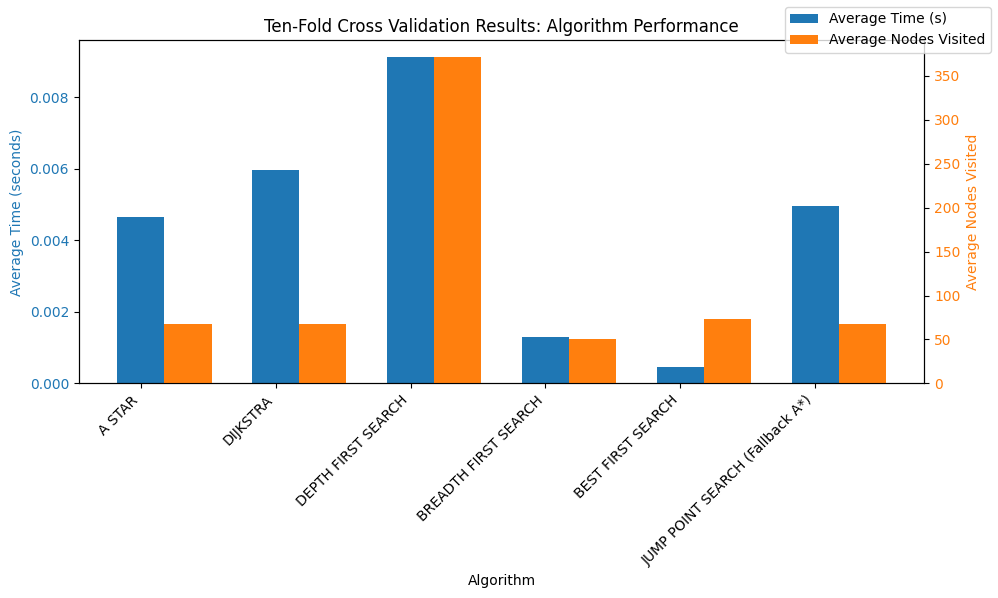

In [ ]:
def input_coordinates():
    print(bold_green("ENTER THE COORDINATE (LATITUDE LONGITUDE) ONE PER LINE. TYPE 'DONE' WHEN FINISHED.\n"))
    print(bold("=" * 42) + "\n")
    coords = []
    while True:
        line = input(bold_green("LATITUDE | LONGITUDE: ")).strip()
        if line.lower() == 'done':
            if len(coords) >= 2:
                break
            else:
                print(bold_red("NEED AT LEAST TWO COORDINATES TO COMPUTE ROUTES!\n"))
                continue
        parts = line.split()
        if len(parts) != 2:
            print(bold_red("INVALID INPUT. PLEASE ENTER TWO NUMERIC VALUES (LATITUDE LONGITUDE).\n"))
            continue
        try:
            lat = float(parts[0])
            lon = float(parts[1])
            coords.append((lat, lon))
        except ValueError:
            print(bold_red("PLEASE ENTER VALID NUMERIC VALUES.\n"))
    return coords

def best_first_search(graph, start, goal):
    import heapq
    def heuristic(u, v):
        ux, uy = graph.nodes[u]['x'], graph.nodes[u]['y']
        vx, vy = graph.nodes[v]['x'], graph.nodes[v]['y']
        return sqrt((ux - vx)**2 + (uy - vy)**2)

    visited = set()
    heap = [(heuristic(start, goal), start, [start])]
    while heap:
        _, current, path = heapq.heappop(heap)
        if current == goal:
            return path
        if current in visited:
            continue
        visited.add(current)
        for neighbor in graph.neighbors(current):
            if neighbor not in visited:
                heapq.heappush(heap, (heuristic(neighbor, goal), neighbor, path + [neighbor]))
    return None

def dfs_path(graph, start, goal):
    stack = [(start, [start])]
    visited = set()
    while stack:
        vertex, path = stack.pop()
        if vertex == goal:
            return path
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph.neighbors(vertex):
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor]))
    return None

def bfs_path(graph, start, goal):
    from collections import deque
    queue = deque([(start, [start])])
    visited = set([start])
    while queue:
        vertex, path = queue.popleft()
        if vertex == goal:
            return path
        for neighbor in graph.neighbors(vertex):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None

def jps_path(graph, start, goal):
    try:
        return nx.astar_path(graph, start, goal, weight='length')
    except nx.NetworkXNoPath:
        return None

def print_colored_summary_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bold bright_cyan")
    columns = df.columns.tolist()
    for col in columns:
        table.add_column(col)

    for _, row in df.iterrows():
        avg_time = row['AVERAGE TIME (s)']
        if avg_time is None:
            time_str = "[bright_red]N/A[/bright_red]"
        elif avg_time > 1:
            time_str = f"[bold bright_red]{avg_time:.4f}[/bold bright_red]"
        elif avg_time > 0.1:
            time_str = f"[bold bright_yellow]{avg_time:.4f}[/bold bright_yellow]"
        else:
            time_str = f"[bold bright_green]{avg_time:.4f}[/bold bright_green]"

        avg_nodes = row['AVERAGE NODE']
        nodes_str = f"{avg_nodes:.1f}" if avg_nodes is not None else "[red]N/A[/red]"

        table.add_row(
            str(row['ALGORITHM']),
            time_str,
            nodes_str,
            str(row['TOTAL ROUTES'])
        )

    console.print(table)

def compare_algorithms_ten_fold(coordinates):
    start_coords = coordinates[0]
    print()
    print(bold("=" * 42) + "\n")
    print(bold_green("LOADING ROAD NETWORK GRAPH AROUND START POINT..."))
    G = ox.graph_from_point(start_coords, dist=5000, network_type='drive', simplify=False)
    start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])

    algorithms = {
        "A STAR"                               : lambda G, s, t: nx.astar_path(G, s, t, weight='length'),
        "DIJKSTRA"                            : lambda G, s, t: nx.dijkstra_path(G, s, t, weight='length'),
        "DEPTH FIRST SEARCH"                  : dfs_path,
        "BREADTH FIRST SEARCH"                : bfs_path,
        "BEST FIRST SEARCH"                   : best_first_search,
        "JUMP POINT SEARCH (Fallback A*)"    : jps_path
    }

    coords_array = np.array(coordinates[1:])
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    fold_results = {algo: {"time": [], "nodes": []} for algo in algorithms.keys()}

    for fold_idx, (_, test_idx) in enumerate(kf.split(coords_array)):
        print(bold_green(f"\n✔️FOLD {fold_idx + 1}"))
        print()
        test_coords = coords_array[test_idx]

        for algo_name, func in algorithms.items():
            total_time = 0
            total_nodes = 0
            success_count = 0

            for coord in test_coords:
                end_node = ox.nearest_nodes(G, coord[1], coord[0])
                try:
                    start_time = time.time()
                    route = func(G, start_node, end_node)
                    elapsed = time.time() - start_time
                    if route is None:
                        continue
                    total_time += elapsed
                    total_nodes += len(route)
                    success_count += 1
                except (nx.NetworkXNoPath, KeyError):
                    continue

            if success_count > 0:
                avg_time = total_time / success_count
                avg_nodes = total_nodes / success_count
            else:
                avg_time = None
                avg_nodes = None

            fold_results[algo_name]["time"].append(avg_time)
            fold_results[algo_name]["nodes"].append(avg_nodes)

    summary_results = []
    for algo_name in algorithms.keys():
        times = [t for t in fold_results[algo_name]["time"] if t is not None]
        nodes = [n for n in fold_results[algo_name]["nodes"] if n is not None]

        avg_time = np.mean(times) if times else None
        avg_nodes = np.mean(nodes) if nodes else None

        summary_results.append({
            "ALGORITHM": algo_name,
            "AVERAGE TIME (s)": avg_time,
            "AVERAGE NODE": avg_nodes,
            "TOTAL ROUTES": len(coords_array)
        })

    df = pd.DataFrame(summary_results)
    print(bold("=" * 42))
    print(bold_red("\nSUMMARY"))
    print()
    print_colored_summary_table(df)
    df.to_excel("TEN_FOLD.xlsx", index=False)
    print(bold_green("\nSummary saved to 'TEN_FOLD.xlsx'"))

    return df

def visualize_summary(df):
    df_clean = df.dropna(subset=['AVERAGE TIME (s)', 'AVERAGE NODE'])

    algos = df_clean['ALGORITHM']
    times = df_clean['AVERAGE TIME (s)']
    nodes = df_clean['AVERAGE NODE']

    x = range(len(algos))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(10, 6))

    bars1 = ax1.bar(x, times, width, label='Average Time (s)', color='tab:blue')
    ax1.set_xlabel('Algorithm')
    ax1.set_ylabel('Average Time (seconds)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_xticks(x)
    ax1.set_xticklabels(algos, rotation=45, ha='right')

    ax2 = ax1.twinx()
    bars2 = ax2.bar([i + width for i in x], nodes, width, label='Average Nodes Visited', color='tab:orange')
    ax2.set_ylabel('Average Nodes Visited', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    plt.title('Ten-Fold Cross Validation Results: Algorithm Performance')
    fig.legend([bars1, bars2], ['Average Time (s)', 'Average Nodes Visited'], loc='upper right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    coords = input_coordinates()
    df_summary = compare_algorithms_ten_fold(coords)
    visualize_summary(df_summary)


## ***DJIKSTRA AVERAGE***

In [ ]:
def load_coordinates_from_csv(file_path):
    df = pd.read_csv(file_path)
    required_columns = {'ID', 'LATITUDE', 'LONGITUDE'}
    if not required_columns.issubset(df.columns):
        raise ValueError("CSV must contain columns: ID, LATITUDE, LONGITUDE")
    df = df.sort_values('ID')
    return df

def compute_routes_from_id1(df, trial_count):
    coordinates = list(zip(df['LATITUDE'], df['LONGITUDE']))
    id_list = df['ID'].tolist()

    start_index = id_list.index(1)
    start_coord = coordinates[start_index]

    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    print(bold_green("LOADING ROAD NETWORK GRAPH..."))
    start_time = time.time()
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=True)
    print(bold(f"GRAPH LOADED IN {time.time() - start_time:.2f} SECONDS\n"))

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []

    for trial in range(trial_count):
        print(bold_yellow(f"Running trial {trial + 1}/{trial_count}..."))

        for idx, (lat, lon) in enumerate(coordinates):
            if idx == start_index:
                continue

            target_id = id_list[idx]
            target_node = ox.nearest_nodes(G, lon, lat)

            print(bold_yellow(f"Calculating route: ID 1 → ID {target_id}"))

            try:
                route_start = time.time()
                route = nx.dijkstra_path(G, start_node, target_node, weight='length')
                route_time = time.time() - route_start
            except nx.NetworkXNoPath:
                print(bold_red(f"No path found from ID 1 to ID {target_id}. Skipping.\n"))
                continue

            total_distance = 0
            for j in range(1, len(route)):
                u, v = route[j-1], route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    total_distance += edge_data[list(edge_data.keys())[0]]['length']

            total_distance_km = total_distance / 1000
            results.append({
                'Trial': trial + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(route_time, 4)
            })

    return results

def calculate_averages(df):
    avg_distance = df['Jarak Rute (km)'].mean()
    avg_nodes = df['Jumlah Node Dilewati'].mean()
    avg_time = df['Waktu Komputasi (detik)'].mean()

    return avg_distance, avg_nodes, avg_time

def display_average_performance(avg_distance, avg_nodes, avg_time):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Metric", style="bold")
    table.add_column("Value", style="bold")

    table.add_row("Average Distance (km)", f"{avg_distance:.2f}")
    table.add_row("Average Nodes", f"{avg_nodes:.2f}")
    table.add_row("Average Computation Time (s)", f"{avg_time:.4f}")

    console.print(table)

def display_results(results):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Trial", style="bold")
    table.add_column("Jarak Rute (km)", style="bold")
    table.add_column("Jumlah Node Dilewati", style="bold")
    table.add_column("Waktu Komputasi (detik)", style="bold")

    for result in results:
        trial = str(result['Trial'])
        jarak = result['Jarak Rute (km)']
        nodes = str(result['Jumlah Node Dilewati'])
        waktu = str(result['Waktu Komputasi (detik)'])

        if float(jarak) > 15:
            jarak_str = f"[red]{jarak}[/red]"
        elif float(jarak) > 5:
            jarak_str = f"[yellow]{jarak}[/yellow]"
        else:
            jarak_str = f"[green]{jarak}[/green]"

        if float(waktu) > 0.05:
            waktu_str = f"[red]{waktu}[/red]"
        else:
            waktu_str = f"[green]{waktu}[/green]"

        table.add_row(trial, jarak_str, nodes, waktu_str)

    console.print(table)

def main():
    file_path = 'FOLD VALIDATION.csv'
    df = load_coordinates_from_csv(file_path)
    trial_count = 10
    results = compute_routes_from_id1(df, trial_count)

    display_results(results)

    avg_distance, avg_nodes, avg_time = calculate_averages(pd.DataFrame(results))
    display_average_performance(avg_distance, avg_nodes, avg_time)

if __name__ == "__main__":
    main()


LOADING ROAD NETWORK GRAPH...
GRAPH LOADED IN 3.31 SECONDS

Running trial 1/10...
Calculating route: ID 1 → ID 5
Calculating route: ID 1 → ID 10
Calculating route: ID 1 → ID 15
Calculating route: ID 1 → ID 20
Calculating route: ID 1 → ID 25
Calculating route: ID 1 → ID 30
Calculating route: ID 1 → ID 35
Calculating route: ID 1 → ID 40
Calculating route: ID 1 → ID 45
Calculating route: ID 1 → ID 50
Calculating route: ID 1 → ID 55
Calculating route: ID 1 → ID 60
Calculating route: ID 1 → ID 65
Calculating route: ID 1 → ID 70
Calculating route: ID 1 → ID 75
Calculating route: ID 1 → ID 80
Calculating route: ID 1 → ID 85
Calculating route: ID 1 → ID 90
Calculating route: ID 1 → ID 95
Calculating route: ID 1 → ID 100
Calculating route: ID 1 → ID 105
Calculating route: ID 1 → ID 110
Calculating route: ID 1 → ID 115
Calculating route: ID 1 → ID 120
Calculating route: ID 1 → ID 125
Calculating route: ID 1 → ID 130
Calculating route: ID 1 → ID 135
Calculating route: ID 1 → ID 140
Calculating ro

┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1     │ 0.722           │ 5                    │ 0.0011                  │
│ 1     │ 0.529           │ 6                    │ 0.0002                  │
│ 1     │ 0.884           │ 9                    │ 0.0003                  │
│ 1     │ 0.71            │ 8                    │ 0.0002                  │
│ 1     │ 0.558           │ 7                    │ 0.0002                  │
│ 1     │ 1.769           │ 12                   │ 0.0005                  │
│ 1     │ 2.104           │ 13                   │ 0.0006                  │
│ 1     │ 1.604           │ 11                   │ 0.0004                  │
│ 1     │ 2.264           │ 13                   │ 0.0006                  │
│ 1     │ 2.693           │ 15                   │ 0.0008                  │
│ 1     │ 2.392           │ 16                   │ 0.0006                  │
│ 1     │ 2.573           │ 16                   │ 0.0007                  │
│ 1     │ 0.506           │ 4                    │ 0.0001                  │
│ 1     │ 1.5             │ 8                    │ 0.0003                  │
│ 1     │ 1.744           │ 11                   │ 0.0004                  │
│ 1     │ 2.615           │ 14                   │ 0.0008                  │
│ 1     │ 1.886           │ 10                   │ 0.0005                  │
│ 1     │ 2.757           │ 15                   │ 0.0008                  │
│ 1     │ 3.147           │ 17                   │ 0.0009                  │
│ 1     │ 3.088           │ 16                   │ 0.0009                  │
│ 1     │ 2.392           │ 9                    │ 0.0006                  │
│ 1     │ 1.602           │ 8                    │ 0.0003                  │
│ 1     │ 1.128           │ 8                    │ 0.0002                  │
│ 1     │ 2.392           │ 9                    │ 0.0006                  │
│ 1     │ 2.609           │ 14                   │ 0.0007                  │
│ 1     │ 2.851           │ 15                   │ 0.0009                  │
│ 1     │ 2.069           │ 11                   │ 0.0006                  │
│ 1     │ 2.55            │ 15                   │ 0.0007                  │
│ 1     │ 3.36            │ 17                   │ 0.001                   │
│ 1     │ 3.433           │ 19                   │ 0.001                   │
│ 1     │ 3.035           │ 20                   │ 0.0008                  │
│ 1     │ 3.567           │ 21                   │ 0.001                   │
│ 1     │ 3.245           │ 21                   │ 0.0008                  │
│ 1     │ 3.356           │ 18                   │ 0.0009                  │
│ 1     │ 3.946           │ 24                   │ 0.0011                  │
│ 1     │ 5.082           │ 30                   │ 0.0012                  │
│ 1     │ 4.751           │ 26                   │ 0.0011                  │
│ 2     │ 0.722           │ 5                    │ 0.0002                  │
│ 2     │ 0.529           │ 6                    │ 0.0003                  │
│ 2     │ 0.884           │ 9                    │ 0.0002                  │
│ 2     │ 0.71            │ 8                    │ 0.0002                  │
│ 2     │ 0.558           │ 7                    │ 0.0001                  │
│ 2     │ 1.769           │ 12                   │ 0.0005                  │
│ 2     │ 2.104           │ 13                   │ 0.0006                  │
│ 2     │ 1.604           │ 11                   │ 0.0004                  │
│ 2     │ 2.264           │ 13                   │ 0.0006                  │
│ 2     │ 2.693           │ 15                   │ 0.0008                  │
│ 2     │ 2.392           │ 16                   │ 0.0006                  │
│ 2     │ 2.573           │ 16                   │ 0.0007                

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric                       ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Average Distance (km)        │ 2.36   │
│ Average Nodes                │ 13.81  │
│ Average Computation Time (s) │ 0.0007 │
└──────────────────────────────┴────────┘

## ***A STAR AVERAGE***

In [ ]:
def load_coordinates_from_csv(file_path):
    df = pd.read_csv(file_path)
    required_columns = {'ID', 'LATITUDE', 'LONGITUDE'}
    if not required_columns.issubset(df.columns):
        raise ValueError("CSV must contain columns: ID, LATITUDE, LONGITUDE")
    df = df.sort_values('ID')
    return df

def euclidean_heuristic(G, node1, node2):
    x1 = G.nodes[node1]['x']
    y1 = G.nodes[node1]['y']
    x2 = G.nodes[node2]['x']
    y2 = G.nodes[node2]['y']
    return sqrt((x1 - x2)**2 + (y1 - y2)**2)

def compute_routes_astar(df, trial_count):
    coordinates = list(zip(df['LATITUDE'], df['LONGITUDE']))
    id_list = df['ID'].tolist()

    start_index = id_list.index(1)
    start_coord = coordinates[start_index]

    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    print(bold_green("LOADING ROAD NETWORK GRAPH..."))
    start_time = time.time()
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=True)
    print(bold(f"GRAPH LOADED IN {time.time() - start_time:.2f} SECONDS\n"))

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []

    for trial in range(trial_count):
        print(bold_yellow(f"Running trial {trial + 1}/{trial_count}..."))

        for idx, (lat, lon) in enumerate(coordinates):
            if idx == start_index:
                continue

            target_id = id_list[idx]
            target_node = ox.nearest_nodes(G, lon, lat)

            print(bold_yellow(f"Calculating A* route: ID 1 → ID {target_id}"))

            try:
                route_start = time.time()
                route = nx.astar_path(G, start_node, target_node, heuristic=lambda u, v: euclidean_heuristic(G, u, v), weight='length')
                route_time = time.time() - route_start
            except nx.NetworkXNoPath:
                print(bold_red(f"No path found from ID 1 to ID {target_id}. Skipping.\n"))
                continue

            total_distance = 0
            for j in range(1, len(route)):
                u, v = route[j-1], route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    total_distance += edge_data[list(edge_data.keys())[0]]['length']

            total_distance_km = total_distance / 1000
            results.append({
                'Trial': trial + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(route_time, 4)
            })

    return results

def calculate_averages(df):
    avg_distance = df['Jarak Rute (km)'].mean()
    avg_nodes = df['Jumlah Node Dilewati'].mean()
    avg_time = df['Waktu Komputasi (detik)'].mean()

    return avg_distance, avg_nodes, avg_time

def display_average_performance(avg_distance, avg_nodes, avg_time):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Metric", style="bold")
    table.add_column("Value", style="bold")

    table.add_row("Average Distance (km)", f"{avg_distance:.2f}")
    table.add_row("Average Nodes", f"{avg_nodes:.2f}")
    table.add_row("Average Computation Time (s)", f"{avg_time:.4f}")

    console.print(table)

def display_results(results):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Trial", style="bold")
    table.add_column("Jarak Rute (km)", style="bold")
    table.add_column("Jumlah Node Dilewati", style="bold")
    table.add_column("Waktu Komputasi (detik)", style="bold")

    for result in results:
        trial = str(result['Trial'])
        jarak = result['Jarak Rute (km)']
        nodes = str(result['Jumlah Node Dilewati'])
        waktu = str(result['Waktu Komputasi (detik)'])

        if float(jarak) > 15:
            jarak_str = f"[red]{jarak}[/red]"
        elif float(jarak) > 5:
            jarak_str = f"[yellow]{jarak}[/yellow]"
        else:
            jarak_str = f"[green]{jarak}[/green]"

        if float(waktu) > 0.05:
            waktu_str = f"[red]{waktu}[/red]"
        else:
            waktu_str = f"[green]{waktu}[/green]"

        table.add_row(trial, jarak_str, nodes, waktu_str)

    console.print(table)

def main():
    file_path = 'FOLD VALIDATION.csv'
    df = load_coordinates_from_csv(file_path)
    trial_count = 10
    results = compute_routes_astar(df, trial_count)

    display_results(results)

    avg_distance, avg_nodes, avg_time = calculate_averages(pd.DataFrame(results))
    display_average_performance(avg_distance, avg_nodes, avg_time)

if __name__ == "__main__":
    main()


LOADING ROAD NETWORK GRAPH...
GRAPH LOADED IN 3.57 SECONDS

Running trial 1/10...
Calculating A* route: ID 1 → ID 5
Calculating A* route: ID 1 → ID 10
Calculating A* route: ID 1 → ID 15
Calculating A* route: ID 1 → ID 20
Calculating A* route: ID 1 → ID 25
Calculating A* route: ID 1 → ID 30
Calculating A* route: ID 1 → ID 35
Calculating A* route: ID 1 → ID 40
Calculating A* route: ID 1 → ID 45
Calculating A* route: ID 1 → ID 50
Calculating A* route: ID 1 → ID 55
Calculating A* route: ID 1 → ID 60
Calculating A* route: ID 1 → ID 65
Calculating A* route: ID 1 → ID 70
Calculating A* route: ID 1 → ID 75
Calculating A* route: ID 1 → ID 80
Calculating A* route: ID 1 → ID 85
Calculating A* route: ID 1 → ID 90
Calculating A* route: ID 1 → ID 95
Calculating A* route: ID 1 → ID 100
Calculating A* route: ID 1 → ID 105
Calculating A* route: ID 1 → ID 110
Calculating A* route: ID 1 → ID 115
Calculating A* route: ID 1 → ID 120
Calculating A* route: ID 1 → ID 125
Calculating A* route: ID 1 → ID 130
Ca

┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1     │ 0.722           │ 5                    │ 0.0006                  │
│ 1     │ 0.529           │ 6                    │ 0.0002                  │
│ 1     │ 0.884           │ 9                    │ 0.0003                  │
│ 1     │ 0.71            │ 8                    │ 0.0002                  │
│ 1     │ 0.558           │ 7                    │ 0.0002                  │
│ 1     │ 1.769           │ 12                   │ 0.0006                  │
│ 1     │ 2.104           │ 13                   │ 0.0008                  │
│ 1     │ 1.604           │ 11                   │ 0.0005                  │
│ 1     │ 2.264           │ 13                   │ 0.0008                  │
│ 1     │ 2.693           │ 15                   │ 0.001                   │
│ 1     │ 2.392           │ 16                   │ 0.0008                  │
│ 1     │ 2.573           │ 16                   │ 0.001                   │
│ 1     │ 0.506           │ 4                    │ 0.0001                  │
│ 1     │ 1.5             │ 8                    │ 0.0004                  │
│ 1     │ 1.744           │ 11                   │ 0.0005                  │
│ 1     │ 2.615           │ 14                   │ 0.0009                  │
│ 1     │ 1.886           │ 10                   │ 0.0006                  │
│ 1     │ 2.757           │ 15                   │ 0.0011                  │
│ 1     │ 3.147           │ 17                   │ 0.0012                  │
│ 1     │ 3.088           │ 16                   │ 0.0011                  │
│ 1     │ 2.392           │ 9                    │ 0.0007                  │
│ 1     │ 1.602           │ 8                    │ 0.0005                  │
│ 1     │ 1.128           │ 8                    │ 0.0003                  │
│ 1     │ 2.392           │ 9                    │ 0.0008                  │
│ 1     │ 2.609           │ 14                   │ 0.0009                  │
│ 1     │ 2.851           │ 15                   │ 0.001                   │
│ 1     │ 2.069           │ 11                   │ 0.0006                  │
│ 1     │ 2.55            │ 15                   │ 0.0009                  │
│ 1     │ 3.36            │ 17                   │ 0.0013                  │
│ 1     │ 3.433           │ 19                   │ 0.0013                  │
│ 1     │ 3.035           │ 20                   │ 0.0011                  │
│ 1     │ 3.567           │ 21                   │ 0.0012                  │
│ 1     │ 3.245           │ 21                   │ 0.0011                  │
│ 1     │ 3.356           │ 18                   │ 0.0011                  │
│ 1     │ 3.946           │ 24                   │ 0.0013                  │
│ 1     │ 5.082           │ 30                   │ 0.0018                  │
│ 1     │ 4.751           │ 26                   │ 0.0014                  │
│ 2     │ 0.722           │ 5                    │ 0.0002                  │
│ 2     │ 0.529           │ 6                    │ 0.0002                  │
│ 2     │ 0.884           │ 9                    │ 0.0004                  │
│ 2     │ 0.71            │ 8                    │ 0.0003                  │
│ 2     │ 0.558           │ 7                    │ 0.0003                  │
│ 2     │ 1.769           │ 12                   │ 0.0007                  │
│ 2     │ 2.104           │ 13                   │ 0.0007                  │
│ 2     │ 1.604           │ 11                   │ 0.0005                  │
│ 2     │ 2.264           │ 13                   │ 0.0007                  │
│ 2     │ 2.693           │ 15                   │ 0.001                   │
│ 2     │ 2.392           │ 16                   │ 0.0012                  │
│ 2     │ 2.573           │ 16                   │ 0.0009                

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric                       ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Average Distance (km)        │ 2.36   │
│ Average Nodes                │ 13.81  │
│ Average Computation Time (s) │ 0.0012 │
└──────────────────────────────┴────────┘

## ***DEPTH FIRST SEARCH AVERAGE***

In [ ]:
def load_coordinates_from_csv(file_path):
    df = pd.read_csv(file_path)
    required_columns = {'ID', 'LATITUDE', 'LONGITUDE'}
    if not required_columns.issubset(df.columns):
        raise ValueError("CSV must contain columns: ID, LATITUDE, LONGITUDE")
    df = df.sort_values('ID')
    return df

def dfs_path(graph, start, goal, visited=None, path=None):
    if visited is None:
        visited = set()
    if path is None:
        path = []

    visited.add(start)
    path.append(start)

    if start == goal:
        return path

    for neighbor in graph.neighbors(start):
        if neighbor not in visited:
            result = dfs_path(graph, neighbor, goal, visited, path)
            if result:
                return result
    path.pop()
    return None

def compute_routes_dfs(df, trial_count):
    coordinates = list(zip(df['LATITUDE'], df['LONGITUDE']))
    id_list = df['ID'].tolist()

    start_index = id_list.index(1)
    start_coord = coordinates[start_index]

    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    print(bold_green("LOADING ROAD NETWORK GRAPH..."))
    start_time = time.time()
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=True)
    print(bold(f"GRAPH LOADED IN {time.time() - start_time:.2f} SECONDS\n"))

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []

    for trial in range(trial_count):
        print(bold_yellow(f"Running trial {trial + 1}/{trial_count}..."))

        for idx, (lat, lon) in enumerate(coordinates):
            if idx == start_index:
                continue

            target_id = id_list[idx]
            target_node = ox.nearest_nodes(G, lon, lat)

            print(bold_yellow(f"Calculating DFS route: ID 1 → ID {target_id}"))

            try:
                route_start = time.time()
                route = dfs_path(G, start_node, target_node)
                route_time = time.time() - route_start
            except nx.NetworkXNoPath:
                print(bold_red(f"No path found from ID 1 to ID {target_id}. Skipping.\n"))
                continue

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j-1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    total_distance += edge_data[list(edge_data.keys())[0]]['length']

            total_distance_km = total_distance / 1000
            results.append({
                'Trial': trial + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(route_time, 4)
            })

    return results

def calculate_averages(df):
    avg_distance = df['Jarak Rute (km)'].mean()
    avg_nodes = df['Jumlah Node Dilewati'].mean()
    avg_time = df['Waktu Komputasi (detik)'].mean()

    return avg_distance, avg_nodes, avg_time

def display_average_performance(avg_distance, avg_nodes, avg_time):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Metric", style="bold")
    table.add_column("Value", style="bold")

    table.add_row("Average Distance (km)", f"{avg_distance:.2f}")
    table.add_row("Average Nodes", f"{avg_nodes:.2f}")
    table.add_row("Average Computation Time (s)", f"{avg_time:.4f}")

    console.print(table)

def display_results(results):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Trial", style="bold")
    table.add_column("Jarak Rute (km)", style="bold")
    table.add_column("Jumlah Node Dilewati", style="bold")
    table.add_column("Waktu Komputasi (detik)", style="bold")

    for result in results:
        trial = str(result['Trial'])
        jarak = result['Jarak Rute (km)']
        nodes = str(result['Jumlah Node Dilewati'])
        waktu = str(result['Waktu Komputasi (detik)'])

        if float(jarak) > 15:
            jarak_str = f"[red]{jarak}[/red]"
        elif float(jarak) > 5:
            jarak_str = f"[yellow]{jarak}[/yellow]"
        else:
            jarak_str = f"[green]{jarak}[/green]"

        if float(waktu) > 0.05:
            waktu_str = f"[red]{waktu}[/red]"
        else:
            waktu_str = f"[green]{waktu}[/green]"

        table.add_row(trial, jarak_str, nodes, waktu_str)

    console.print(table)

def main():
    file_path = 'FOLD VALIDATION.csv'
    df = load_coordinates_from_csv(file_path)
    trial_count = 10
    results = compute_routes_dfs(df, trial_count)

    display_results(results)

    avg_distance, avg_nodes, avg_time = calculate_averages(pd.DataFrame(results))
    display_average_performance(avg_distance, avg_nodes, avg_time)

if __name__ == "__main__":
    main()


LOADING ROAD NETWORK GRAPH...
GRAPH LOADED IN 3.38 SECONDS

Running trial 1/10...
Calculating DFS route: ID 1 → ID 5
Calculating DFS route: ID 1 → ID 10
Calculating DFS route: ID 1 → ID 15
Calculating DFS route: ID 1 → ID 20
Calculating DFS route: ID 1 → ID 25
Calculating DFS route: ID 1 → ID 30
Calculating DFS route: ID 1 → ID 35
Calculating DFS route: ID 1 → ID 40
Calculating DFS route: ID 1 → ID 45
Calculating DFS route: ID 1 → ID 50
Calculating DFS route: ID 1 → ID 55
Calculating DFS route: ID 1 → ID 60
Calculating DFS route: ID 1 → ID 65
Calculating DFS route: ID 1 → ID 70
Calculating DFS route: ID 1 → ID 75
Calculating DFS route: ID 1 → ID 80
Calculating DFS route: ID 1 → ID 85
Calculating DFS route: ID 1 → ID 90
Calculating DFS route: ID 1 → ID 95
Calculating DFS route: ID 1 → ID 100
Calculating DFS route: ID 1 → ID 105
Calculating DFS route: ID 1 → ID 110
Calculating DFS route: ID 1 → ID 115
Calculating DFS route: ID 1 → ID 120
Calculating DFS route: ID 1 → ID 125
Calculating D

┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1     │ 1.255           │ 9                    │ 0.0                     │
│ 1     │ 2.154           │ 15                   │ 0.0                     │
│ 1     │ 1.767           │ 13                   │ 0.0                     │
│ 1     │ 8.085           │ 40                   │ 0.0001                  │
│ 1     │ 2.182           │ 16                   │ 0.0                     │
│ 1     │ 18.349          │ 87                   │ 0.0014                  │
│ 1     │ 18.684          │ 88                   │ 0.0012                  │
│ 1     │ 7.19            │ 37                   │ 0.0                     │
│ 1     │ 8.357           │ 41                   │ 0.0001                  │
│ 1     │ 18.512          │ 88                   │ 0.0011                  │
│ 1     │ 17.218          │ 78                   │ 0.0012                  │
│ 1     │ 17.908          │ 84                   │ 0.0012                  │
│ 1     │ 0.654           │ 6                    │ 0.0                     │
│ 1     │ 14.844          │ 75                   │ 0.0002                  │
│ 1     │ 17.017          │ 88                   │ 0.0002                  │
│ 1     │ 14.57           │ 73                   │ 0.0002                  │
│ 1     │ 6.947           │ 37                   │ 0.0013                  │
│ 1     │ 13.326          │ 67                   │ 0.0002                  │
│ 1     │ 13.716          │ 69                   │ 0.0002                  │
│ 1     │ 13.658          │ 68                   │ 0.0002                  │
│ 1     │ 17.908          │ 89                   │ 0.0002                  │
│ 1     │ 16.874          │ 85                   │ 0.0001                  │
│ 1     │ 2.752           │ 17                   │ 0.0                     │
│ 1     │ 17.908          │ 89                   │ 0.0002                  │
│ 1     │ 4.248           │ 23                   │ 0.0                     │
│ 1     │ 4.496           │ 25                   │ 0.0                     │
│ 1     │ 14.5            │ 74                   │ 0.0002                  │
│ 1     │ 8.733           │ 43                   │ 0.0001                  │
│ 1     │ 5.024           │ 28                   │ 0.0012                  │
│ 1     │ 5.361           │ 29                   │ 0.0                     │
│ 1     │ 9.737           │ 49                   │ 0.0012                  │
│ 1     │ 9.751           │ 49                   │ 0.0001                  │
│ 1     │ 16.358          │ 74                   │ 0.0012                  │
│ 1     │ 18.428          │ 85                   │ 0.0011                  │
│ 1     │ 19.576          │ 88                   │ 0.0011                  │
│ 1     │ 11.481          │ 59                   │ 0.0012                  │
│ 1     │ 17.707          │ 77                   │ 0.0016                  │
│ 2     │ 1.255           │ 9                    │ 0.0                     │
│ 2     │ 2.154           │ 15                   │ 0.0                     │
│ 2     │ 1.767           │ 13                   │ 0.0                     │
│ 2     │ 8.085           │ 40                   │ 0.0001                  │
│ 2     │ 2.182           │ 16                   │ 0.0001                  │
│ 2     │ 18.349          │ 87                   │ 0.0012                  │
│ 2     │ 18.684          │ 88                   │ 0.0012                  │
│ 2     │ 7.19            │ 37                   │ 0.0                     │
│ 2     │ 8.357           │ 41                   │ 0.0001                  │
│ 2     │ 18.512          │ 88                   │ 0.0012                  │
│ 2     │ 17.218          │ 78                   │ 0.0012                  │
│ 2     │ 17.908          │ 84                   │ 0.0011                

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric                       ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Average Distance (km)        │ 11.28  │
│ Average Nodes                │ 55.73  │
│ Average Computation Time (s) │ 0.0005 │
└──────────────────────────────┴────────┘

## ***BREADTH FIRST SEARCH AVERAGE***

In [ ]:
def load_coordinates_from_csv(file_path):
    df = pd.read_csv(file_path)
    required_columns = {'ID', 'LATITUDE', 'LONGITUDE'}
    if not required_columns.issubset(df.columns):
        raise ValueError("CSV must contain columns: ID, LATITUDE, LONGITUDE")
    df = df.sort_values('ID')
    return df

def bfs_path(graph, start, goal):
    queue = deque([(start, [start])])
    visited = set([start])
    while queue:
        vertex, path = queue.popleft()
        if vertex == goal:
            return path
        for neighbor in graph.neighbors(vertex):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None

def compute_routes_bfs(df, trial_count):
    coordinates = list(zip(df['LATITUDE'], df['LONGITUDE']))
    id_list = df['ID'].tolist()

    start_index = id_list.index(1)
    start_coord = coordinates[start_index]

    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    print(bold_green("LOADING ROAD NETWORK GRAPH..."))
    start_time = time.time()
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=True)
    print(bold(f"GRAPH LOADED IN {time.time() - start_time:.2f} SECONDS\n"))

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []

    for trial in range(trial_count):
        print(bold_yellow(f"Running trial {trial + 1}/{trial_count}..."))

        for idx, (lat, lon) in enumerate(coordinates):
            if idx == start_index:
                continue

            target_id = id_list[idx]
            target_node = ox.nearest_nodes(G, lon, lat)

            print(bold_yellow(f"Calculating BFS route: ID 1 → ID {target_id}"))

            try:
                route_start = time.time()
                route = bfs_path(G, start_node, target_node)
                route_time = time.time() - route_start
            except nx.NetworkXNoPath:
                print(bold_red(f"No path found from ID 1 to ID {target_id}. Skipping.\n"))
                continue

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j-1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    total_distance += edge_data[list(edge_data.keys())[0]]['length']

            total_distance_km = total_distance / 1000
            results.append({
                'Trial': trial + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(route_time, 4)
            })

    return results

def calculate_averages(df):
    avg_distance = df['Jarak Rute (km)'].mean()
    avg_nodes = df['Jumlah Node Dilewati'].mean()
    avg_time = df['Waktu Komputasi (detik)'].mean()

    return avg_distance, avg_nodes, avg_time

def display_average_performance(avg_distance, avg_nodes, avg_time):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Metric", style="bold")
    table.add_column("Value", style="bold")

    table.add_row("Average Distance (km)", f"{avg_distance:.2f}")
    table.add_row("Average Nodes", f"{avg_nodes:.2f}")
    table.add_row("Average Computation Time (s)", f"{avg_time:.4f}")

    console.print(table)

def display_results(results):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Trial", style="bold")
    table.add_column("Jarak Rute (km)", style="bold")
    table.add_column("Jumlah Node Dilewati", style="bold")
    table.add_column("Waktu Komputasi (detik)", style="bold")

    for result in results:
        trial = str(result['Trial'])
        jarak = result['Jarak Rute (km)']
        nodes = str(result['Jumlah Node Dilewati'])
        waktu = str(result['Waktu Komputasi (detik)'])

        if float(jarak) > 15:
            jarak_str = f"[red]{jarak}[/red]"
        elif float(jarak) > 5:
            jarak_str = f"[yellow]{jarak}[/yellow]"
        else:
            jarak_str = f"[green]{jarak}[/green]"

        if float(waktu) > 0.05:
            waktu_str = f"[red]{waktu}[/red]"
        else:
            waktu_str = f"[green]{waktu}[/green]"

        table.add_row(trial, jarak_str, nodes, waktu_str)

    console.print(table)

def main():
    file_path = 'FOLD VALIDATION.csv'
    df = load_coordinates_from_csv(file_path)
    trial_count = 10
    results = compute_routes_bfs(df, trial_count)

    display_results(results)

    avg_distance, avg_nodes, avg_time = calculate_averages(pd.DataFrame(results))
    display_average_performance(avg_distance, avg_nodes, avg_time)

if __name__ == "__main__":
    main()


LOADING ROAD NETWORK GRAPH...
GRAPH LOADED IN 4.07 SECONDS

Running trial 1/10...
Calculating BFS route: ID 1 → ID 5
Calculating BFS route: ID 1 → ID 10
Calculating BFS route: ID 1 → ID 15
Calculating BFS route: ID 1 → ID 20
Calculating BFS route: ID 1 → ID 25
Calculating BFS route: ID 1 → ID 30
Calculating BFS route: ID 1 → ID 35
Calculating BFS route: ID 1 → ID 40
Calculating BFS route: ID 1 → ID 45
Calculating BFS route: ID 1 → ID 50
Calculating BFS route: ID 1 → ID 55
Calculating BFS route: ID 1 → ID 60
Calculating BFS route: ID 1 → ID 65
Calculating BFS route: ID 1 → ID 70
Calculating BFS route: ID 1 → ID 75
Calculating BFS route: ID 1 → ID 80
Calculating BFS route: ID 1 → ID 85
Calculating BFS route: ID 1 → ID 90
Calculating BFS route: ID 1 → ID 95
Calculating BFS route: ID 1 → ID 100
Calculating BFS route: ID 1 → ID 105
Calculating BFS route: ID 1 → ID 110
Calculating BFS route: ID 1 → ID 115
Calculating BFS route: ID 1 → ID 120
Calculating BFS route: ID 1 → ID 125
Calculating B

┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1     │ 0.722           │ 4                    │ 0.0001                  │
│ 1     │ 0.529           │ 6                    │ 0.0001                  │
│ 1     │ 1.119           │ 7                    │ 0.0001                  │
│ 1     │ 1.293           │ 8                    │ 0.0001                  │
│ 1     │ 0.558           │ 7                    │ 0.0001                  │
│ 1     │ 2.308           │ 11                   │ 0.0002                  │
│ 1     │ 2.642           │ 12                   │ 0.0002                  │
│ 1     │ 1.63            │ 9                    │ 0.0001                  │
│ 1     │ 2.296           │ 11                   │ 0.0002                  │
│ 1     │ 2.725           │ 13                   │ 0.0003                  │
│ 1     │ 2.931           │ 15                   │ 0.0003                  │
│ 1     │ 3.112           │ 15                   │ 0.0003                  │
│ 1     │ 0.516           │ 3                    │ 0.0                     │
│ 1     │ 1.609           │ 8                    │ 0.0001                  │
│ 1     │ 2.145           │ 11                   │ 0.0002                  │
│ 1     │ 2.615           │ 14                   │ 0.0002                  │
│ 1     │ 1.886           │ 10                   │ 0.0002                  │
│ 1     │ 3.116           │ 14                   │ 0.0003                  │
│ 1     │ 3.521           │ 15                   │ 0.0003                  │
│ 1     │ 3.448           │ 15                   │ 0.0003                  │
│ 1     │ 2.392           │ 9                    │ 0.0002                  │
│ 1     │ 1.602           │ 8                    │ 0.0001                  │
│ 1     │ 1.128           │ 8                    │ 0.0002                  │
│ 1     │ 2.392           │ 9                    │ 0.0001                  │
│ 1     │ 2.681           │ 11                   │ 0.0002                  │
│ 1     │ 2.908           │ 12                   │ 0.0002                  │
│ 1     │ 2.178           │ 11                   │ 0.0002                  │
│ 1     │ 2.673           │ 13                   │ 0.0002                  │
│ 1     │ 3.417           │ 14                   │ 0.0003                  │
│ 1     │ 3.493           │ 15                   │ 0.0003                  │
│ 1     │ 3.298           │ 17                   │ 0.0002                  │
│ 1     │ 3.83            │ 18                   │ 0.0003                  │
│ 1     │ 3.791           │ 19                   │ 0.0003                  │
│ 1     │ 3.894           │ 17                   │ 0.0003                  │
│ 1     │ 5.041           │ 20                   │ 0.0004                  │
│ 1     │ 6.286           │ 27                   │ 0.0007                  │
│ 1     │ 5.297           │ 24                   │ 0.0005                  │
│ 2     │ 0.722           │ 4                    │ 0.0                     │
│ 2     │ 0.529           │ 6                    │ 0.0001                  │
│ 2     │ 1.119           │ 7                    │ 0.0001                  │
│ 2     │ 1.293           │ 8                    │ 0.0001                  │
│ 2     │ 0.558           │ 7                    │ 0.0001                  │
│ 2     │ 2.308           │ 11                   │ 0.0002                  │
│ 2     │ 2.642           │ 12                   │ 0.0002                  │
│ 2     │ 1.63            │ 9                    │ 0.0001                  │
│ 2     │ 2.296           │ 11                   │ 0.0002                  │
│ 2     │ 2.725           │ 13                   │ 0.0002                  │
│ 2     │ 2.931           │ 15                   │ 0.0003                  │
│ 2     │ 3.112           │ 15                   │ 0.0003                

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric                       ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Average Distance (km)        │ 2.62   │
│ Average Nodes                │ 12.43  │
│ Average Computation Time (s) │ 0.0002 │
└──────────────────────────────┴────────┘

## ***BEST FIRST SEARCH AVERAGE***

In [ ]:
def load_coordinates_from_csv(file_path):
    df = pd.read_csv(file_path)
    required_columns = {'ID', 'LATITUDE', 'LONGITUDE'}
    if not required_columns.issubset(df.columns):
        raise ValueError("CSV must contain columns: ID, LATITUDE, LONGITUDE")
    df = df.sort_values('ID')
    return df

def best_first_heuristic(G, node1, node2):
    x1 = G.nodes[node1]['x']
    y1 = G.nodes[node1]['y']
    x2 = G.nodes[node2]['x']
    y2 = G.nodes[node2]['y']
    return sqrt((x1 - x2)**2 + (y1 - y2)**2)

def best_first_search(graph, start, goal, heuristic):
    open_list = [start]
    came_from = {start: None}
    g_cost = {start: 0}
    f_cost = {start: heuristic(graph, start, goal)}

    while open_list:
        current = min(open_list, key=lambda node: f_cost[node])
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            return path[::-1]

        open_list.remove(current)

        for neighbor in graph.neighbors(current):
            tentative_g_cost = g_cost[current] + graph[current][neighbor].get('length', 1)

            if neighbor not in g_cost or tentative_g_cost < g_cost[neighbor]:
                came_from[neighbor] = current
                g_cost[neighbor] = tentative_g_cost
                f_cost[neighbor] = tentative_g_cost + heuristic(graph, neighbor, goal)
                open_list.append(neighbor)

    return None

def compute_routes_best_first_search(df, trial_count):
    coordinates = list(zip(df['LATITUDE'], df['LONGITUDE']))
    id_list = df['ID'].tolist()

    start_index = id_list.index(1)
    start_coord = coordinates[start_index]

    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    print(bold_green("LOADING ROAD NETWORK GRAPH..."))
    start_time = time.time()
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=True)
    print(bold(f"GRAPH LOADED IN {time.time() - start_time:.2f} SECONDS\n"))

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []

    for trial in range(trial_count):
        print(bold_yellow(f"Running trial {trial + 1}/{trial_count}..."))

        for idx, (lat, lon) in enumerate(coordinates):
            if idx == start_index:
                continue

            target_id = id_list[idx]
            target_node = ox.nearest_nodes(G, lon, lat)

            print(bold_yellow(f"Calculating Best First Search route: ID 1 → ID {target_id}"))

            try:
                route_start = time.time()
                route = best_first_search(G, start_node, target_node, heuristic=best_first_heuristic)
                route_time = time.time() - route_start
            except nx.NetworkXNoPath:
                print(bold_red(f"No path found from ID 1 to ID {target_id}. Skipping.\n"))
                continue

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j-1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    total_distance += edge_data[list(edge_data.keys())[0]]['length']

            total_distance_km = total_distance / 1000
            results.append({
                'Trial': trial + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(route_time, 4)
            })

    return results

def calculate_averages(df):
    avg_distance = df['Jarak Rute (km)'].mean()
    avg_nodes = df['Jumlah Node Dilewati'].mean()
    avg_time = df['Waktu Komputasi (detik)'].mean()

    return avg_distance, avg_nodes, avg_time

def display_average_performance(avg_distance, avg_nodes, avg_time):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Metric", style="bold")
    table.add_column("Value", style="bold")

    table.add_row("Average Distance (km)", f"{avg_distance:.2f}")
    table.add_row("Average Nodes", f"{avg_nodes:.2f}")
    table.add_row("Average Computation Time (s)", f"{avg_time:.4f}")

    console.print(table)

def display_results(results):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Trial", style="bold")
    table.add_column("Jarak Rute (km)", style="bold")
    table.add_column("Jumlah Node Dilewati", style="bold")
    table.add_column("Waktu Komputasi (detik)", style="bold")

    for result in results:
        trial = str(result['Trial'])
        jarak = result['Jarak Rute (km)']
        nodes = str(result['Jumlah Node Dilewati'])
        waktu = str(result['Waktu Komputasi (detik)'])

        if float(jarak) > 15:
            jarak_str = f"[red]{jarak}[/red]"
        elif float(jarak) > 5:
            jarak_str = f"[yellow]{jarak}[/yellow]"
        else:
            jarak_str = f"[green]{jarak}[/green]"

        if float(waktu) > 0.05:
            waktu_str = f"[red]{waktu}[/red]"
        else:
            waktu_str = f"[green]{waktu}[/green]"

        table.add_row(trial, jarak_str, nodes, waktu_str)

    console.print(table)

def main():
    file_path = 'FOLD VALIDATION.csv'
    df = load_coordinates_from_csv(file_path)
    trial_count = 10
    results = compute_routes_best_first_search(df, trial_count)

    display_results(results)

    avg_distance, avg_nodes, avg_time = calculate_averages(pd.DataFrame(results))
    display_average_performance(avg_distance, avg_nodes, avg_time)

if __name__ == "__main__":
    main()


LOADING ROAD NETWORK GRAPH...
GRAPH LOADED IN 3.35 SECONDS

Running trial 1/10...
Calculating Best First Search route: ID 1 → ID 5
Calculating Best First Search route: ID 1 → ID 10
Calculating Best First Search route: ID 1 → ID 15
Calculating Best First Search route: ID 1 → ID 20
Calculating Best First Search route: ID 1 → ID 25
Calculating Best First Search route: ID 1 → ID 30
Calculating Best First Search route: ID 1 → ID 35
Calculating Best First Search route: ID 1 → ID 40
Calculating Best First Search route: ID 1 → ID 45
Calculating Best First Search route: ID 1 → ID 50
Calculating Best First Search route: ID 1 → ID 55
Calculating Best First Search route: ID 1 → ID 60
Calculating Best First Search route: ID 1 → ID 65
Calculating Best First Search route: ID 1 → ID 70
Calculating Best First Search route: ID 1 → ID 75
Calculating Best First Search route: ID 1 → ID 80
Calculating Best First Search route: ID 1 → ID 85
Calculating Best First Search route: ID 1 → ID 90
Calculating Best Fi

┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1     │ 0.722           │ 4                    │ 0.0002                  │
│ 1     │ 0.529           │ 6                    │ 0.0003                  │
│ 1     │ 1.119           │ 7                    │ 0.0004                  │
│ 1     │ 0.71            │ 8                    │ 0.0005                  │
│ 1     │ 0.558           │ 7                    │ 0.0004                  │
│ 1     │ 2.308           │ 11                   │ 0.0008                  │
│ 1     │ 2.642           │ 12                   │ 0.0009                  │
│ 1     │ 1.63            │ 9                    │ 0.0006                  │
│ 1     │ 2.296           │ 11                   │ 0.0008                  │
│ 1     │ 2.725           │ 13                   │ 0.0016                  │
│ 1     │ 2.931           │ 15                   │ 0.0013                  │
│ 1     │ 3.112           │ 15                   │ 0.0012                  │
│ 1     │ 0.516           │ 3                    │ 0.0001                  │
│ 1     │ 1.599           │ 8                    │ 0.0005                  │
│ 1     │ 1.744           │ 11                   │ 0.0008                  │
│ 1     │ 2.615           │ 14                   │ 0.0011                  │
│ 1     │ 2.207           │ 10                   │ 0.0007                  │
│ 1     │ 3.116           │ 14                   │ 0.0012                  │
│ 1     │ 3.521           │ 15                   │ 0.0013                  │
│ 1     │ 4.073           │ 15                   │ 0.0013                  │
│ 1     │ 2.392           │ 9                    │ 0.0006                  │
│ 1     │ 1.602           │ 8                    │ 0.0005                  │
│ 1     │ 1.128           │ 8                    │ 0.0005                  │
│ 1     │ 2.392           │ 9                    │ 0.0006                  │
│ 1     │ 2.681           │ 11                   │ 0.0008                  │
│ 1     │ 2.908           │ 12                   │ 0.0009                  │
│ 1     │ 2.069           │ 11                   │ 0.0008                  │
│ 1     │ 2.673           │ 13                   │ 0.001                   │
│ 1     │ 3.417           │ 14                   │ 0.0011                  │
│ 1     │ 3.493           │ 15                   │ 0.0012                  │
│ 1     │ 3.298           │ 17                   │ 0.0015                  │
│ 1     │ 4.239           │ 18                   │ 0.0016                  │
│ 1     │ 3.791           │ 19                   │ 0.0017                  │
│ 1     │ 3.894           │ 17                   │ 0.0015                  │
│ 1     │ 5.042           │ 20                   │ 0.0018                  │
│ 1     │ 6.287           │ 27                   │ 0.0032                  │
│ 1     │ 6.523           │ 24                   │ 0.0042                  │
│ 2     │ 0.722           │ 4                    │ 0.0001                  │
│ 2     │ 0.529           │ 6                    │ 0.0003                  │
│ 2     │ 1.119           │ 7                    │ 0.0004                  │
│ 2     │ 0.71            │ 8                    │ 0.0005                  │
│ 2     │ 0.558           │ 7                    │ 0.0004                  │
│ 2     │ 2.308           │ 11                   │ 0.0009                  │
│ 2     │ 2.642           │ 12                   │ 0.0009                  │
│ 2     │ 1.63            │ 9                    │ 0.0006                  │
│ 2     │ 2.296           │ 11                   │ 0.0008                  │
│ 2     │ 2.725           │ 13                   │ 0.001                   │
│ 2     │ 2.931           │ 15                   │ 0.0013                  │
│ 2     │ 3.112           │ 15                   │ 0.0013                

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric                       ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Average Distance (km)        │ 2.66   │
│ Average Nodes                │ 12.43  │
│ Average Computation Time (s) │ 0.0011 │
└──────────────────────────────┴────────┘

## ***JUMP POINT SEARCH AVERAGE***

In [ ]:
def load_coordinates_from_csv(file_path):
    df = pd.read_csv(file_path)
    required_columns = {'ID', 'LATITUDE', 'LONGITUDE'}
    if not required_columns.issubset(df.columns):
        raise ValueError("CSV must contain columns: ID, LATITUDE, LONGITUDE")
    df = df.sort_values('ID')
    return df

def jps_heuristic(G, node1, node2):
    x1 = G.nodes[node1]['x']
    y1 = G.nodes[node1]['y']
    x2 = G.nodes[node2]['x']
    y2 = G.nodes[node2]['y']
    return sqrt((x1 - x2)**2 + (y1 - y2)**2)

def jump_point_search(graph, start, goal, heuristic):
    open_list = []
    heapq.heappush(open_list, (0, start))
    came_from = {start: None}
    g_cost = {start: 0}
    f_cost = {start: heuristic(graph, start, goal)}

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:

            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            return path[::-1]

        for neighbor in graph.neighbors(current):
            tentative_g_cost = g_cost[current] + graph[current][neighbor].get('length', 1)

            if neighbor not in g_cost or tentative_g_cost < g_cost[neighbor]:
                came_from[neighbor] = current
                g_cost[neighbor] = tentative_g_cost
                f_cost[neighbor] = tentative_g_cost + heuristic(graph, neighbor, goal)
                heapq.heappush(open_list, (f_cost[neighbor], neighbor))

    return None

def compute_routes_jump_point_search(df, trial_count):
    coordinates = list(zip(df['LATITUDE'], df['LONGITUDE']))
    id_list = df['ID'].tolist()

    start_index = id_list.index(1)
    start_coord = coordinates[start_index]

    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    print(bold_green("LOADING ROAD NETWORK GRAPH..."))
    start_time = time.time()
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=True)
    print(bold(f"GRAPH LOADED IN {time.time() - start_time:.2f} SECONDS\n"))

    start_node = ox.nearest_nodes(G, start_coord[1], start_coord[0])

    results = []

    for trial in range(trial_count):
        print(bold_yellow(f"Running trial {trial + 1}/{trial_count}..."))

        for idx, (lat, lon) in enumerate(coordinates):
            if idx == start_index:
                continue

            target_id = id_list[idx]
            target_node = ox.nearest_nodes(G, lon, lat)

            print(bold_yellow(f"Calculating Jump Point Search route: ID 1 → ID {target_id}"))

            try:
                route_start = time.time()
                route = jump_point_search(G, start_node, target_node, heuristic=jps_heuristic)
                route_time = time.time() - route_start
            except nx.NetworkXNoPath:
                print(bold_red(f"No path found from ID 1 to ID {target_id}. Skipping.\n"))
                continue

            total_distance = 0
            for j in range(1, len(route)):
                u = route[j-1]
                v = route[j]
                edge_data = G.get_edge_data(u, v)
                if edge_data:
                    total_distance += edge_data[list(edge_data.keys())[0]]['length']

            total_distance_km = total_distance / 1000
            results.append({
                'Trial': trial + 1,
                'Jarak Rute (km)': round(total_distance_km, 3),
                'Jumlah Node Dilewati': len(route),
                'Waktu Komputasi (detik)': round(route_time, 4)
            })

    return results

def calculate_averages(df):
    avg_distance = df['Jarak Rute (km)'].mean()
    avg_nodes = df['Jumlah Node Dilewati'].mean()
    avg_time = df['Waktu Komputasi (detik)'].mean()

    return avg_distance, avg_nodes, avg_time

def display_average_performance(avg_distance, avg_nodes, avg_time):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Metric", style="bold")
    table.add_column("Value", style="bold")

    table.add_row("Average Distance (km)", f"{avg_distance:.2f}")
    table.add_row("Average Nodes", f"{avg_nodes:.2f}")
    table.add_row("Average Computation Time (s)", f"{avg_time:.4f}")

    console.print(table)

def display_results(results):
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")
    table.add_column("Trial", style="bold")
    table.add_column("Jarak Rute (km)", style="bold")
    table.add_column("Jumlah Node Dilewati", style="bold")
    table.add_column("Waktu Komputasi (detik)", style="bold")

    for result in results:
        trial = str(result['Trial'])
        jarak = result['Jarak Rute (km)']
        nodes = str(result['Jumlah Node Dilewati'])
        waktu = str(result['Waktu Komputasi (detik)'])

        if float(jarak) > 15:
            jarak_str = f"[red]{jarak}[/red]"
        elif float(jarak) > 5:
            jarak_str = f"[yellow]{jarak}[/yellow]"
        else:
            jarak_str = f"[green]{jarak}[/green]"

        if float(waktu) > 0.05:
            waktu_str = f"[red]{waktu}[/red]"
        else:
            waktu_str = f"[green]{waktu}[/green]"

        table.add_row(trial, jarak_str, nodes, waktu_str)

    console.print(table)


def main():
    file_path = 'FOLD VALIDATION.csv'
    df = load_coordinates_from_csv(file_path)
    trial_count = 10
    results = compute_routes_jump_point_search(df, trial_count)

    display_results(results)

    avg_distance, avg_nodes, avg_time = calculate_averages(pd.DataFrame(results))
    display_average_performance(avg_distance, avg_nodes, avg_time)

if __name__ == "__main__":
    main()


LOADING ROAD NETWORK GRAPH...
GRAPH LOADED IN 3.62 SECONDS

Running trial 1/10...
Calculating Jump Point Search route: ID 1 → ID 5
Calculating Jump Point Search route: ID 1 → ID 10
Calculating Jump Point Search route: ID 1 → ID 15
Calculating Jump Point Search route: ID 1 → ID 20
Calculating Jump Point Search route: ID 1 → ID 25
Calculating Jump Point Search route: ID 1 → ID 30
Calculating Jump Point Search route: ID 1 → ID 35
Calculating Jump Point Search route: ID 1 → ID 40
Calculating Jump Point Search route: ID 1 → ID 45
Calculating Jump Point Search route: ID 1 → ID 50
Calculating Jump Point Search route: ID 1 → ID 55
Calculating Jump Point Search route: ID 1 → ID 60
Calculating Jump Point Search route: ID 1 → ID 65
Calculating Jump Point Search route: ID 1 → ID 70
Calculating Jump Point Search route: ID 1 → ID 75
Calculating Jump Point Search route: ID 1 → ID 80
Calculating Jump Point Search route: ID 1 → ID 85
Calculating Jump Point Search route: ID 1 → ID 90
Calculating Jump Po

┏━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial ┃ Jarak Rute (km) ┃ Jumlah Node Dilewati ┃ Waktu Komputasi (detik) ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1     │ 0.722           │ 4                    │ 0.0002                  │
│ 1     │ 0.529           │ 6                    │ 0.0004                  │
│ 1     │ 1.119           │ 7                    │ 0.0005                  │
│ 1     │ 0.71            │ 8                    │ 0.0007                  │
│ 1     │ 0.558           │ 7                    │ 0.0004                  │
│ 1     │ 2.308           │ 11                   │ 0.0007                  │
│ 1     │ 2.642           │ 12                   │ 0.0007                  │
│ 1     │ 1.63            │ 9                    │ 0.0005                  │
│ 1     │ 2.296           │ 11                   │ 0.0007                  │
│ 1     │ 2.725           │ 13                   │ 0.0009                  │
│ 1     │ 2.931           │ 15                   │ 0.0011                  │
│ 1     │ 3.112           │ 15                   │ 0.0011                  │
│ 1     │ 0.516           │ 3                    │ 0.0001                  │
│ 1     │ 1.599           │ 8                    │ 0.0004                  │
│ 1     │ 1.744           │ 11                   │ 0.0007                  │
│ 1     │ 2.615           │ 14                   │ 0.001                   │
│ 1     │ 2.207           │ 10                   │ 0.0006                  │
│ 1     │ 3.116           │ 14                   │ 0.0012                  │
│ 1     │ 3.521           │ 15                   │ 0.0012                  │
│ 1     │ 4.073           │ 15                   │ 0.0012                  │
│ 1     │ 2.392           │ 9                    │ 0.0005                  │
│ 1     │ 1.602           │ 8                    │ 0.0004                  │
│ 1     │ 1.128           │ 8                    │ 0.0004                  │
│ 1     │ 2.392           │ 9                    │ 0.0005                  │
│ 1     │ 2.681           │ 11                   │ 0.0007                  │
│ 1     │ 2.908           │ 12                   │ 0.0008                  │
│ 1     │ 2.069           │ 11                   │ 0.0007                  │
│ 1     │ 2.673           │ 13                   │ 0.0016                  │
│ 1     │ 3.417           │ 14                   │ 0.001                   │
│ 1     │ 3.493           │ 15                   │ 0.0011                  │
│ 1     │ 3.298           │ 17                   │ 0.0012                  │
│ 1     │ 4.239           │ 18                   │ 0.0013                  │
│ 1     │ 3.791           │ 19                   │ 0.0015                  │
│ 1     │ 3.894           │ 17                   │ 0.0028                  │
│ 1     │ 5.042           │ 20                   │ 0.0015                  │
│ 1     │ 6.287           │ 27                   │ 0.0024                  │
│ 1     │ 6.523           │ 24                   │ 0.0019                  │
│ 2     │ 0.722           │ 4                    │ 0.0001                  │
│ 2     │ 0.529           │ 6                    │ 0.0002                  │
│ 2     │ 1.119           │ 7                    │ 0.0003                  │
│ 2     │ 0.71            │ 8                    │ 0.0004                  │
│ 2     │ 0.558           │ 7                    │ 0.0003                  │
│ 2     │ 2.308           │ 11                   │ 0.0007                  │
│ 2     │ 2.642           │ 12                   │ 0.0008                  │
│ 2     │ 1.63            │ 9                    │ 0.0005                  │
│ 2     │ 2.296           │ 11                   │ 0.0007                  │
│ 2     │ 2.725           │ 13                   │ 0.0008                  │
│ 2     │ 2.931           │ 15                   │ 0.0011                  │
│ 2     │ 3.112           │ 15                   │ 0.0013                

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric                       ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Average Distance (km)        │ 2.66   │
│ Average Nodes                │ 12.43  │
│ Average Computation Time (s) │ 0.0009 │
└──────────────────────────────┴────────┘

# **SUMMARY TRIAL AVARAGE**

In [ ]:
def display_summary(algorithms_results):
    """
    Menampilkan summary rata-rata untuk keenam algoritma
    :param algorithms_results: Dictionary yang berisi hasil rata-rata untuk masing-masing algoritma
    """
    console = Console()
    table = Table(show_header=True, header_style="bold cyan")

    table.add_column("Algorithm", style="bold")
    table.add_column("Avg Distance (km)", style="bold")
    table.add_column("Avg Nodes", style="bold")
    table.add_column("Avg Time (s)", style="bold")

    for algorithm, result in algorithms_results.items():
        table.add_row(
            algorithm,
            f"{result['avg_distance']:.2f}",
            f"{result['avg_nodes']:.2f}",
            f"{result['avg_time']:.4f}"
        )

    console.print(table)

def compute_summary_for_all_algorithms():
    """
    Menghitung rata-rata untuk masing-masing algoritma
    """
    algorithms_results = {
        'Dijkstra': {
            'avg_distance': 2.36,
            'avg_nodes': 13.81,
            'avg_time': 0.0007
        },
        'A*': {
            'avg_distance': 2.36,
            'avg_nodes': 13.81,
            'avg_time': 0.0012
        },
        'Breadth-First Search': {
            'avg_distance': 2.62,
            'avg_nodes': 12.43,
            'avg_time': 0.0002
        },
        'Depth-First Search': {
            'avg_distance': 11.28,
            'avg_nodes': 55.73,
            'avg_time': 0.0005
        },
        'Best-First Search': {
            'avg_distance': 2.66,
            'avg_nodes': 12.43,
            'avg_time': 0.0011
        },
        'Jump Point Search': {
            'avg_distance': 2.66,
            'avg_nodes': 12.43,
            'avg_time': 0.0009

        }
    }

    return algorithms_results

def main():
    algorithms_results = compute_summary_for_all_algorithms()
    display_summary(algorithms_results)

if __name__ == "__main__":
    main()


┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Algorithm            ┃ Avg Distance (km) ┃ Avg Nodes ┃ Avg Time (s) ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Dijkstra             │ 2.36              │ 13.81     │ 0.0007       │
│ A*                   │ 2.36              │ 13.81     │ 0.0012       │
│ Breadth-First Search │ 2.62              │ 12.43     │ 0.0002       │
│ Depth-First Search   │ 11.28             │ 55.73     │ 0.0005       │
│ Best-First Search    │ 2.66              │ 12.43     │ 0.0011       │
│ Jump Point Search    │ 2.66              │ 12.43     │ 0.0009       │
└──────────────────────┴───────────────────┴───────────┴──────────────┘

<ipython-input-31-950725893>:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(algorithms, rotation=45, ha='right')
<ipython-input-31-950725893>:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(algorithms, rotation=45, ha='right')
<ipython-input-31-950725893>:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(algorithms, rotation=45, ha='right')


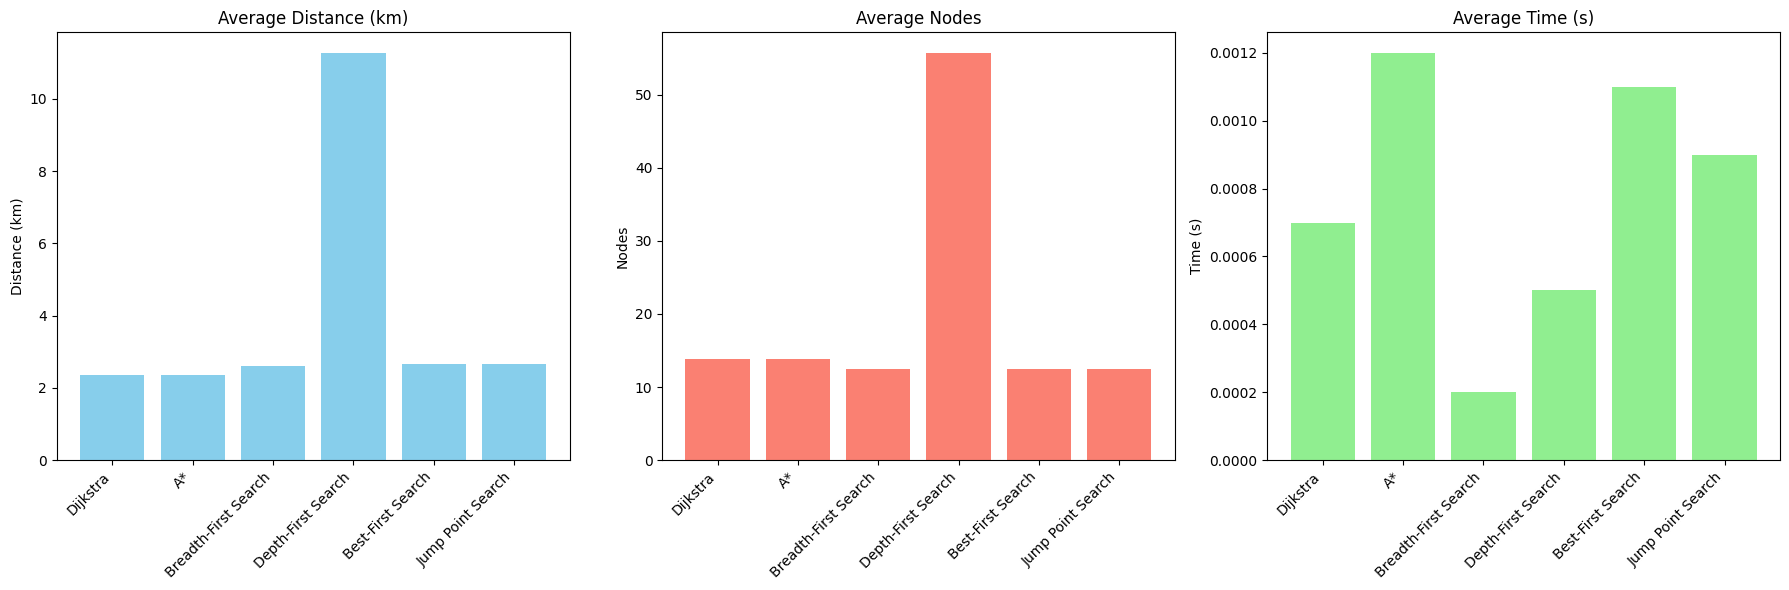

In [ ]:
algorithms_results = {
    'Dijkstra': {
        'avg_distance': 2.36,
        'avg_nodes': 13.81,
        'avg_time': 0.0007
    },
    'A*': {
        'avg_distance': 2.36,
        'avg_nodes': 13.81,
        'avg_time': 0.0012
    },
    'Breadth-First Search': {
        'avg_distance': 2.62,
        'avg_nodes': 12.43,
        'avg_time': 0.0002
    },
    'Depth-First Search': {
        'avg_distance': 11.28,
        'avg_nodes': 55.73,
        'avg_time': 0.0005
    },
    'Best-First Search': {
        'avg_distance': 2.66,
        'avg_nodes': 12.43,
        'avg_time': 0.0011
    },
    'Jump Point Search': {
        'avg_distance': 2.66,
        'avg_nodes': 12.43,
        'avg_time': 0.0009
    }
}

algorithms = list(algorithms_results.keys())
avg_distance = [algorithms_results[algo]['avg_distance'] for algo in algorithms]
avg_nodes = [algorithms_results[algo]['avg_nodes'] for algo in algorithms]
avg_time = [algorithms_results[algo]['avg_time'] for algo in algorithms]

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].bar(algorithms, avg_distance, color='skyblue')
ax[0].set_title('Average Distance (km)')
ax[0].set_ylabel('Distance (km)')
ax[0].set_xticklabels(algorithms, rotation=45, ha='right')

ax[1].bar(algorithms, avg_nodes, color='salmon')
ax[1].set_title('Average Nodes')
ax[1].set_ylabel('Nodes')
ax[1].set_xticklabels(algorithms, rotation=45, ha='right')

ax[2].bar(algorithms, avg_time, color='lightgreen')
ax[2].set_title('Average Time (s)')
ax[2].set_ylabel('Time (s)')
ax[2].set_xticklabels(algorithms, rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
def input_coordinates():
    print(bold_green("ENTER THE COORDINATE (LATITUDE | LONGITUDE) ONE PER LINE. TYPE 'DONE' WHEN FINISHED.\n"))
    print(bold("=" * 42) + "\n")
    coords = []
    while True:
        line = input(bold_green("LATITUDE | LONGITUDE: ")).strip()
        if line.lower() == 'done':
            if len(coords) >= 2:
                break
            else:
                print(bold_red("NEED AT LEAST TWO COORDINATES TO COMPUTE ROUTES!!!\n"))
                continue
        parts = line.split()
        if len(parts) != 2:
            print(bold_red("INVALID INPUT. PLEASE ENTER TWO NUMERIC VALUES (LATITUDE LONGITUDE).\n"))
            continue
        try:
            lat = float(parts[0])
            lon = float(parts[1])
            coords.append((lat, lon))
        except ValueError:
            print(bold_red("PLEASE ENTER VALID NUMERIC VALUES.\n"))
    return coords

def best_first_search(graph, start, goal):
    import heapq
    def heuristic(u, v):
        ux, uy = graph.nodes[u]['x'], graph.nodes[u]['y']
        vx, vy = graph.nodes[v]['x'], graph.nodes[v]['y']
        return sqrt((ux - vx)**2 + (uy - vy)**2)
    visited = set()
    heap = [(heuristic(start, goal), start, [start])]
    while heap:
        _, current, path = heapq.heappop(heap)
        if current == goal:
            return path
        if current in visited:
            continue
        visited.add(current)
        for neighbor in graph.neighbors(current):
            if neighbor not in visited:
                heapq.heappush(heap, (heuristic(neighbor, goal), neighbor, path + [neighbor]))
    return None

def dfs_path(graph, start, goal):
    stack = [(start, [start])]
    visited = set()
    while stack:
        vertex, path = stack.pop()
        if vertex == goal:
            return path
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph.neighbors(vertex):
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor]))
    return None

def bfs_path(graph, start, goal):
    from collections import deque
    queue = deque([(start, [start])])
    visited = set([start])
    while queue:
        vertex, path = queue.popleft()
        if vertex == goal:
            return path
        for neighbor in graph.neighbors(vertex):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None

def jps_path(graph, start, goal):
    try:
        return nx.astar_path(graph, start, goal, weight='length')
    except nx.NetworkXNoPath:
        return None

def print_colored_table(df):
    console = Console()
    table = Table(show_header=True, header_style="bright_cyan")

    for col in df.columns:
        table.add_column(col)

    for _, row in df.iterrows():
        avg_time = row['AVERAGE TIME (s)']
        if avg_time is None:
            time_str = "[bright_red]N/A[/bright_red]"
        elif avg_time > 1:
            time_str = f"[bright_red]{avg_time:.4f}[/bright_red]"
        elif avg_time > 0.1:
            time_str = f"[bright_yellow]{avg_time:.4f}[/bright_yellow]"
        else:
            time_str = f"[bright_green]{avg_time:.4f}[/bright_green]"

        avg_nodes = row['AVERAGE NODE']
        nodes_str = f"{avg_nodes:.1f}" if avg_nodes is not None else "[red]N/A[/red]"

        row_data = [
            str(row['ALGORITHM']),
            time_str,
            nodes_str,
            str(row['TOTAL ROUTES'])
        ]
        table.add_row(*row_data)

    console.print(table)

def compare_algorithms(coordinates):
    start_coords = coordinates[0]
    print(bold_green("\nLOADING ROAD NETWORK GRAPH AROUND START POINT..."))
    G = ox.graph_from_point(start_coords, dist=5000, network_type='drive', simplify=False)
    print(bold_green("GRAPH LOADED.\n"))
    print(bold("=" * 42) + "\n")

    algorithms = {
        "A STAR"                                : lambda G, s, t: nx.astar_path(G, s, t, weight='length'),
        "DJIKSTRA"                              : lambda G, s, t: nx.dijkstra_path(G, s, t, weight='length'),
        "DEPTH FIRST SEARCH"                    : dfs_path,
        "BREADTH FIRST SEARCH"                  : bfs_path,
        "BEST FIRST SEARCH"                     : best_first_search,
        "JUMP POINT SEARCH (Fallback A*)"       : jps_path
    }

    start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])

    results = []

    for name, func in algorithms.items():
        print(bold_green(f"RUNNING {name} Algorithm..."))
        total_time = 0
        total_nodes = 0
        success_count = 0

        for i in range(1, len(coordinates)):
            end_coords = coordinates[i]
            end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])

            try:
                start_time = time.time()
                route = func(G, start_node, end_node)
                elapsed = time.time() - start_time

                if route is None:
                    print(bold_red(f"NO PATH FOUND FROM POINT 0 TO POINT {i} WITH {name}. SKIPPING.\n"))
                    continue

                total_time += elapsed
                total_nodes += len(route)
                success_count += 1
            except (nx.NetworkXNoPath, KeyError):
                print(bold_red(f"NO PATH FOUND FROM POINT 0 TO POINT {i} WITH {name}. SKIPPING.\n"))
                continue

        if success_count == 0:
            avg_time = None
            avg_nodes = None
        else:
            avg_time = total_time / success_count
            avg_nodes = total_nodes / success_count

        results.append({
            'ALGORITHM': name,
            'AVERAGE TIME (s)': avg_time,
            'AVERAGE NODE': avg_nodes,
            'TOTAL ROUTES': len(coordinates) - 1
        })

    df = pd.DataFrame(results)
    print("\n" + bold_red("COMPARISON RESULT\n"))
    print_colored_table(df)

    df.to_excel("ALGORITHM_COMPARISON_RESULT.xlsx", index=False)
    print(bold_green("\nResults saved to 'ALGORITHM COMPARISON RESULT.xlsx'"))

    return G, algorithms, coordinates

def visualize_routes(coordinates, G, algorithms):
    start_coords = coordinates[0]
    avg_lat = sum([c[0] for c in coordinates]) / len(coordinates)
    avg_lon = sum([c[1] for c in coordinates]) / len(coordinates)

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    # Markers for all points
    for idx, coord in enumerate(coordinates):
        folium.Marker(
            location=coord,
            popup=f"Point {idx}",
            icon=folium.Icon(color='green' if idx == 0 else 'red')
        ).add_to(m)

    colors = list(mcolors.TABLEAU_COLORS.values())
    if len(algorithms) > len(colors):
        colormap = cm.get_cmap('tab20', len(algorithms))
        colors = [mcolors.to_hex(colormap(i)) for i in range(len(algorithms))]

    start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])

    layers = {}

    for idx_alg, (name, func) in enumerate(algorithms.items()):
        color = colors[idx_alg % len(colors)]
        algorithm_layer = folium.FeatureGroup(name=name)

        for i in range(1, len(coordinates)):
            end_coords = coordinates[i]
            end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
            try:
                route = func(G, start_node, end_node)
                if not route:
                    continue
            except (nx.NetworkXNoPath, KeyError):
                continue

            route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

            folium.PolyLine(
                locations=route_coords,
                color=color,
                weight=5,
                opacity=0.8,
                popup=f"{name} route from 0 to {i}",
                tooltip=f"{name} route to Point {i}"
            ).add_to(algorithm_layer)

            folium.CircleMarker(location=route_coords[0], radius=4, color=color, fill=True).add_to(algorithm_layer)
            folium.CircleMarker(location=route_coords[-1], radius=4, color=color, fill=True).add_to(algorithm_layer)

        layers[name] = algorithm_layer

    for layer in layers.values():
        layer.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    output_file = "COMPARISON INTERVAL.html"
    m.save(output_file)
    print(bold_green(f"Map saved to '{output_file}'."))

def main():
    coords = input_coordinates()
    G, algorithms, coordinates = compare_algorithms(coords)
    print(bold_green("\nSTARTING VISUALIZATION..."))
    visualize_routes(coordinates, G, algorithms)

if __name__ == "__main__":
    main()


ENTER THE COORDINATE (LATITUDE | LONGITUDE) ONE PER LINE. TYPE 'DONE' WHEN FINISHED.


LATITUDE | LONGITUDE: -8.1748428 112.9881571
LATITUDE | LONGITUDE: -8.204169 112.989323
LATITUDE | LONGITUDE: done

LOADING ROAD NETWORK GRAPH AROUND START POINT...
GRAPH LOADED.


RUNNING A STAR Algorithm...
RUNNING DJIKSTRA Algorithm...
RUNNING DEPTH FIRST SEARCH Algorithm...
RUNNING BREADTH FIRST SEARCH Algorithm...
RUNNING BEST FIRST SEARCH Algorithm...
RUNNING JUMP POINT SEARCH (Fallback A*) Algorithm...

COMPARISON RESULT



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ ALGORITHM                       ┃ AVERAGE TIME (s) ┃ AVERAGE NODE ┃ TOTAL ROUTES ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ A STAR                          │ 0.0101           │ 116.0        │ 1            │
│ DJIKSTRA                        │ 0.0175           │ 116.0        │ 1            │
│ DEPTH FIRST SEARCH              │ 0.0008           │ 261.0        │ 1            │
│ BREADTH FIRST SEARCH            │ 0.0021           │ 69.0         │ 1            │
│ BEST FIRST SEARCH               │ 0.0012           │ 172.0        │ 1            │
│ JUMP POINT SEARCH (Fallback A*) │ 0.0100           │ 116.0        │ 1            │
└─────────────────────────────────┴──────────────────┴──────────────┴──────────────┘


Results saved to 'ALGORITHM_COMPARISON_RESULT.xlsx'

STARTING VISUALIZATION...
Map saved to 'COMPARISON_ROUTE_5INTERVAL.html'.


# **OBSTACLE**

### ***DJIKSTRA OBSTACLE***

In [ ]:
def input_routes():
    print("\n🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO")
    print("KETIK 'DONE' UNTUK SELESAI INPUT POSKO")
    print("=" * 60)
    routes = []
    start_point = None

    while True:
        if not start_point:
            print("\nMasukkan TITIK AWAL")
            lat = input("Latitude  = ").strip()
            if lat.lower() == 'done': break
            lon = input("Longitude = ").strip()
            try: start_point = (float(lat), float(lon))
            except: print(bold_red("INPUT INVALID")); continue

        print(f"\nMasukkan KOORDINAT POSKO")
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        try:
            end_point = (float(lat), float(lon))
        except:
            print(bold_red("INPUT INVALID"))
            continue
        routes.append((start_point, end_point))

    return routes if routes else None

def input_obstacles():
    print("\n🟠 INPUT KOORDINAT OBSTACLE (opsional)")
    print("KETIK 'DONE' UNTUK MENGHENTIKAN INPUT")
    print("=" * 60)
    obstacles = []
    while True:
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        if lon.lower() == 'done': break
        try: obstacles.append((float(lat), float(lon)))
        except: print(bold_red("INPUT INVALID")); continue
    return obstacles

def calculate_routes(route_pairs, obstacles):
    print("\n⏳ LOADING ROAD NETWORK GRAPH...")
    start = time.time()
    all_points = [p for pair in route_pairs for p in pair] + obstacles
    avg_lat = sum(p[0] for p in all_points) / len(all_points)
    avg_lon = sum(p[1] for p in all_points) / len(all_points)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)

    obstacle_nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in obstacles]
    G.remove_nodes_from(obstacle_nodes)

    print(f"✅ Graph diproses dan obstacle dihindari dalam {time.time()-start:.2f} detik")

    routes_info = []
    for i, (start_coords, end_coords) in enumerate(route_pairs):
        try:
            start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
            end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
            route = nx.dijkstra_path(G, start_node, end_node, weight='length')
        except nx.NetworkXNoPath:
            print(bold_red(f"❌ TIDAK ADA JALUR KE POSKO {i+1}")); continue

        total_distance = sum(G[u][v][0]['length'] for u, v in zip(route[:-1], route[1:])) / 1000
        walking_time = (total_distance / 5) * 60

        routes_info.append({
            'index': i,
            'from': start_coords,
            'to': end_coords,
            'distance_km': total_distance,
            'walking_time_min': walking_time,
            'route_nodes': route
        })

    return G, routes_info, obstacle_nodes

def visualize_routes_with_legend(G, routes_info, obstacles):
    avg_lat = sum([info['from'][0] + info['to'][0] for info in routes_info]) / (2 * len(routes_info))
    avg_lon = sum([info['from'][1] + info['to'][1] for info in routes_info]) / (2 * len(routes_info))
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    colors = ['blue', 'green', 'orange', 'purple', 'red', 'darkred', 'cadetblue', 'darkblue', 'darkgreen']

    folium.Marker(
        routes_info[0]['from'],
        popup="Titik Awal",
        icon=folium.Icon(color='darkgreen', icon='play')
    ).add_to(m)

    for idx, info in enumerate(routes_info):
        color = colors[info['index'] % len(colors)]
        fg = folium.FeatureGroup(name=f"Rute ke Posko {info['index']+1}")
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        folium.PolyLine(
            route_coords, color=color, weight=6, opacity=0.85,
            popup=f"Rute ke Posko {info['index']+1}"
        ).add_to(fg)
        folium.Marker(
            info['to'],
            popup=f"Posko {info['index']+1}",
            icon=folium.Icon(color='red', icon='flag')
        ).add_to(fg)
        fg.add_to(m)

    for idx, (lat, lon) in enumerate(obstacles):
        folium.Marker(
            location=(lat, lon),
            popup=f"🚧 Obstacle {idx+1}",
            icon=folium.Icon(color='orange', icon='remove-sign')
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    legend_html = '''
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        width: 320px;
        max-height: 450px;
        background-color: #fff;
        border: 2px solid #888;
        border-radius: 10px;
        padding: 15px;
        font-family: Arial;
        font-size: 14px;
        overflow-y: auto;
        z-index: 9999;">
        <h4 style="margin-top:0; color:#333;">📍 Informasi Rute</h4>
    '''

    for info in routes_info:
        color = colors[info['index'] % len(colors)]
        dist = info['distance_km']
        walking = info['walking_time_min']
        motor = (dist / 30) * 60
        car = (dist / 40) * 60
        legend_html += f'''
        <div style="margin-bottom:12px; border-bottom:1px solid #ccc; padding-bottom:10px;">
            <b style="color:{color};">Rute ke Posko {info['index']+1}</b><br>
            📏 <b>Jarak</b>: {dist:.2f} km<br>
            🚶‍♂️ <b>Jalan Kaki</b>: {walking:.1f} menit<br>
            🛵 <b>Motor</b>: {motor:.1f} menit<br>
            🚗 <b>Mobil</b>: {car:.1f} menit
        </div>
        '''

    if obstacles:
        legend_html += f"<b style='color:orange;'>🚧 Jumlah Obstacle: {len(obstacles)}</b><br>"
    legend_html += '</div>'
    m.get_root().html.add_child(Element(legend_html))

    m.save("DJIKSTRA OBSTACLE.html")
    print("\n✅ Peta berhasil disimpan sebagai: DJIKSTRA OBSTACLE.html")

def main():
    route_pairs = input_routes()
    if not route_pairs:
        return

    obstacles = input_obstacles()

    print("\n" + "=" * 60)
    print("🧭  MEMULAI PROSES PERHITUNGAN JALUR EVAKUASI")
    print("=" * 60)

    start = time.time()
    G, routes_info, removed_nodes = calculate_routes(route_pairs, obstacles)
    duration = time.time() - start

    print("=" * 60)

    if routes_info:
        visualize_routes_with_legend(G, routes_info, obstacles)

        table = [
            ["Jumlah Jalur Evakuasi yang Dibuat", f"{len(routes_info)} jalur"],
            ["Jumlah Titik Obstacle Dihindari", f"{len(obstacles)} titik"],
            ["Waktu Komputasi", f"{duration:.2f} detik"],
            ["Jumlah Node Akhir", f"{len(G.nodes):,} node"]
        ]

        print("\n📊  HASIL RINGKASAN PENGOLAHAN DATA")
        print(tabulate(table, headers=["📌 Keterangan", "📈 Nilai"], tablefmt="grid"))
        print("\n✅ Peta berhasil disimpan sebagai: DJIKSTRA OBSTACLE.html\n")
        print("=" * 60 + "\n")
    else:
        print(bold_red("\n❌ Tidak ada rute ditemukan."))

if __name__ == "__main__":
    main()



🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO
KETIK 'DONE' UNTUK SELESAI INPUT POSKO

Masukkan TITIK AWAL
Latitude  = -8.1748428
Longitude = 112.9881571 

Masukkan KOORDINAT POSKO
Latitude  = -8.204333
Longitude = 112.9894642

Masukkan KOORDINAT POSKO
Latitude  = -8.2071387
Longitude = 112.9883338

Masukkan KOORDINAT POSKO
Latitude  = -8.2013192	
Longitude = 112.9995046

Masukkan KOORDINAT POSKO
Latitude  = -8.2119082
Longitude = 112.985026

Masukkan KOORDINAT POSKO
Latitude  = done

🟠 INPUT KOORDINAT OBSTACLE (opsional)
KETIK 'DONE' UNTUK MENGHENTIKAN INPUT
Latitude  = done

🧭  MEMULAI PROSES PERHITUNGAN JALUR EVAKUASI


AttributeError: 'builtin_function_or_method' object has no attribute 'time'

## ***A STAR OBSTACLE***

In [ ]:
import networkx as nx
import folium
import time
import osmnx as ox
from branca.element import Element
from tabulate import tabulate

def bold_red(text): return f"\033[1;31m{text}\033[0m"

def input_routes():
    print("\n🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO")
    print("KETIK 'DONE' UNTUK SELESAI INPUT POSKO")
    print("=" * 60)
    routes = []
    start_point = None

    while True:
        if not start_point:
            print("\nMasukkan TITIK AWAL")
            lat = input("Latitude  = ").strip()
            if lat.lower() == 'done': break
            lon = input("Longitude = ").strip()
            try: start_point = (float(lat), float(lon))
            except: print(bold_red("INPUT INVALID")); continue

        print(f"\nMasukkan KOORDINAT POSKO")
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        try: end_point = (float(lat), float(lon))
        except: print(bold_red("INPUT INVALID")); continue
        routes.append((start_point, end_point))

    return routes if routes else None

def input_obstacles():
    print("\n🟠 INPUT KOORDINAT OBSTACLE (opsional)")
    print("KETIK 'DONE' UNTUK MENGHENTIKAN INPUT")
    print("=" * 60)
    obstacles = []
    while True:
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        if lon.lower() == 'done': break
        try: obstacles.append((float(lat), float(lon)))
        except: print(bold_red("INPUT INVALID")); continue
    return obstacles

def calculate_routes_astar(route_pairs, obstacles):
    print("\n⏳ LOADING ROAD NETWORK GRAPH...")
    start = time.time()
    all_points = [p for pair in route_pairs for p in pair] + obstacles
    avg_lat = sum(p[0] for p in all_points) / len(all_points)
    avg_lon = sum(p[1] for p in all_points) / len(all_points)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)

    obstacle_nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in obstacles]
    G.remove_nodes_from(obstacle_nodes)

    def euclidean_heuristic(u, v):
        u_data = G.nodes[u]
        v_data = G.nodes[v]
        return ((u_data['y'] - v_data['y'])**2 + (u_data['x'] - v_data['x'])**2) ** 0.5

    print(f"✅ Graph diproses dan obstacle dihindari dalam {time.time()-start:.2f} detik")

    routes_info = []
    for i, (start_coords, end_coords) in enumerate(route_pairs):
        try:
            start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
            end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
            route = nx.astar_path(G, start_node, end_node, heuristic=euclidean_heuristic, weight='length')
        except nx.NetworkXNoPath:
            print(bold_red(f"❌ TIDAK ADA JALUR KE POSKO {i+1}")); continue

        total_distance = sum(G[u][v][0]['length'] for u, v in zip(route[:-1], route[1:])) / 1000
        walking_time = (total_distance / 5) * 60

        routes_info.append({
            'index': i,
            'from': start_coords,
            'to': end_coords,
            'distance_km': total_distance,
            'walking_time_min': walking_time,
            'route_nodes': route
        })

    return G, routes_info, obstacle_nodes

def visualize_routes_with_legend(G, routes_info, obstacles):
    avg_lat = sum([info['from'][0] + info['to'][0] for info in routes_info]) / (2 * len(routes_info))
    avg_lon = sum([info['from'][1] + info['to'][1] for info in routes_info]) / (2 * len(routes_info))
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    colors = ['blue', 'green', 'orange', 'purple', 'red', 'darkred', 'cadetblue', 'darkblue', 'darkgreen']
    folium.Marker(
        routes_info[0]['from'],
        popup="Titik Awal",
        icon=folium.Icon(color='darkgreen', icon='play')
    ).add_to(m)

    for idx, info in enumerate(routes_info):
        color = colors[info['index'] % len(colors)]
        fg = folium.FeatureGroup(name=f"Rute ke Posko {info['index']+1}")
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        folium.PolyLine(route_coords, color=color, weight=6, opacity=0.85, popup=f"Rute ke Posko {info['index']+1}").add_to(fg)
        folium.Marker(
            info['to'],
            popup=f"Posko {info['index']+1}",
            icon=folium.Icon(color='red', icon='flag')
        ).add_to(fg)
        fg.add_to(m)

    for idx, (lat, lon) in enumerate(obstacles):
        folium.Marker(
            location=(lat, lon),
            popup=f"🚧 Obstacle {idx+1}",
            icon=folium.Icon(color='orange', icon='remove-sign')
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    # LEGEND
    legend_html = '''
    <div style="position: fixed; bottom: 30px; left: 30px; width: 320px; max-height: 450px;
         background-color: #fff; border: 2px solid #888; border-radius: 10px; padding: 15px;
         font-family: Arial; font-size: 14px; overflow-y: auto; z-index: 9999;">
        <h4 style="margin-top:0; color:#333;">📍 Informasi Rute</h4>
    '''

    for info in routes_info:
        color = colors[info['index'] % len(colors)]
        dist = info['distance_km']
        walking = info['walking_time_min']
        motor = (dist / 30) * 60
        car = (dist / 40) * 60
        legend_html += f'''
        <div style="margin-bottom:12px; border-bottom:1px solid #ccc; padding-bottom:10px;">
            <b style="color:{color};">Rute ke Posko {info['index']+1}</b><br>
            📏 <b>Jarak</b>: {dist:.2f} km<br>
            🚶‍♂️ <b>Jalan Kaki</b>: {walking:.1f} menit<br>
            🛵 <b>Motor</b>: {motor:.1f} menit<br>
            🚗 <b>Mobil</b>: {car:.1f} menit
        </div>
        '''

    if obstacles:
        legend_html += f"<b style='color:orange;'>🚧 Jumlah Obstacle: {len(obstacles)}</b><br>"

    legend_html += '</div>'
    m.get_root().html.add_child(Element(legend_html))
    m.save("ASTAR_OBSTACLE.html")
    print("\n✅ Peta berhasil disimpan sebagai: ASTAR_OBSTACLE.html")

def main():
    route_pairs = input_routes()
    if not route_pairs: return
    obstacles = input_obstacles()

    print("\n" + "=" * 60)
    print("🧭  MEMULAI PENCARIAN JALUR MENGGUNAKAN A* (ASTAR)")
    print("=" * 60)

    start = time.time()
    G, routes_info, removed_nodes = calculate_routes_astar(route_pairs, obstacles)
    duration = time.time() - start

    print("=" * 60)
    if routes_info:
        visualize_routes_with_legend(G, routes_info, obstacles)
        table = [
            ["Jumlah Jalur Evakuasi", f"{len(routes_info)} jalur"],
            ["Jumlah Titik Obstacle", f"{len(obstacles)} titik"],
            ["Waktu Komputasi", f"{duration:.2f} detik"],
            ["Jumlah Node Akhir", f"{len(G.nodes):,} node"]
        ]
        print("\n📊  HASIL RINGKASAN:")
        print(tabulate(table, headers=["📌 Keterangan", "📈 Nilai"], tablefmt="grid"))
        print("\n✅ Peta berhasil disimpan sebagai: ASTAR_OBSTACLE.html\n")
        print("=" * 60 + "\n")
    else:
        print(bold_red("\n❌ Tidak ada rute ditemukan."))

if __name__ == "__main__":
    main()



🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO
KETIK 'DONE' UNTUK SELESAI INPUT POSKO

Masukkan TITIK AWAL
Latitude  = -8.1748428
Longitude = 112.9881571  

Masukkan KOORDINAT POSKO
Latitude  = -8.204333
Longitude = 112.9894642

Masukkan KOORDINAT POSKO
Latitude  = -8.2071387
Longitude = 112.9883338

Masukkan KOORDINAT POSKO
Latitude  = -8.2013192	
Longitude = 112.9995046

Masukkan KOORDINAT POSKO
Latitude  =  -8.2119082
Longitude = 112.985026

Masukkan KOORDINAT POSKO
Latitude  = 
Longitude = done
INPUT INVALID

Masukkan KOORDINAT POSKO
Latitude  = done

🟠 INPUT KOORDINAT OBSTACLE (opsional)
KETIK 'DONE' UNTUK MENGHENTIKAN INPUT
Latitude  = done

🧭  MEMULAI PENCARIAN JALUR MENGGUNAKAN A* (ASTAR)

⏳ LOADING ROAD NETWORK GRAPH...
✅ Graph diproses dan obstacle dihindari dalam 5.60 detik

✅ Peta berhasil disimpan sebagai: ASTAR_OBSTACLE.html

📊  HASIL RINGKASAN:
+-----------------------+-------------+
| 📌 Keterangan         | 📈 Nilai    |
+=======================+=============+
| Jumla

## ***DEPTH FIRST SEARCH***

In [ ]:
def input_routes():
    print("\n🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO")
    print("KETIK 'DONE' UNTUK SELESAI INPUT POSKO")
    print("=" * 60)
    routes = []
    start_point = None

    while True:
        if not start_point:
            print("\nMasukkan TITIK AWAL")
            lat = input("Latitude  = ").strip()
            if lat.lower() == 'done': break
            lon = input("Longitude = ").strip()
            try: start_point = (float(lat), float(lon))
            except: print(bold_red("INPUT INVALID")); continue

        print(f"\nMasukkan KOORDINAT POSKO")
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        try: end_point = (float(lat), float(lon))
        except: print(bold_red("INPUT INVALID")); continue

        routes.append((start_point, end_point))

    return routes if routes else None

# Input obstacle
def input_obstacles():
    print("\n🟠 INPUT KOORDINAT OBSTACLE (opsional)")
    print("KETIK 'DONE' UNTUK MENGHENTIKAN INPUT")
    print("=" * 60)
    obstacles = []
    while True:
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        if lon.lower() == 'done': break
        try: obstacles.append((float(lat), float(lon)))
        except: print(bold_red("INPUT INVALID")); continue
    return obstacles

# DFS path finder
def dfs_path(G, start, goal):
    stack = [(start, [start])]
    visited = set()

    while stack:
        (node, path) = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        for neighbor in G.neighbors(node):
            if neighbor == goal:
                return path + [neighbor]
            stack.append((neighbor, path + [neighbor]))
    raise nx.NetworkXNoPath

# Hitung rute DFS
def calculate_routes_dfs(route_pairs, obstacles):
    print("\n⏳ LOADING ROAD NETWORK GRAPH...")
    start_time = time.time()
    all_points = [p for pair in route_pairs for p in pair] + obstacles
    avg_lat = sum(p[0] for p in all_points) / len(all_points)
    avg_lon = sum(p[1] for p in all_points) / len(all_points)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)

    obstacle_nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in obstacles]
    G.remove_nodes_from(obstacle_nodes)

    print(f"✅ Graph diproses dan obstacle dihindari dalam {time.time()-start_time:.2f} detik")

    routes_info = []
    for i, (start_coords, end_coords) in enumerate(route_pairs):
        try:
            start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
            end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
            route = dfs_path(G, start_node, end_node)
        except nx.NetworkXNoPath:
            print(bold_red(f"❌ TIDAK ADA JALUR KE POSKO {i+1}")); continue

        total_distance = sum(G[u][v][0]['length'] for u, v in zip(route[:-1], route[1:])) / 1000
        walking_time = (total_distance / 5) * 60

        routes_info.append({
            'index': i,
            'from': start_coords,
            'to': end_coords,
            'distance_km': total_distance,
            'walking_time_min': walking_time,
            'route_nodes': route
        })

    return G, routes_info, obstacle_nodes

# Visualisasi rute
def visualize_routes_with_legend(G, routes_info, obstacles):
    avg_lat = sum([info['from'][0] + info['to'][0] for info in routes_info]) / (2 * len(routes_info))
    avg_lon = sum([info['from'][1] + info['to'][1] for info in routes_info]) / (2 * len(routes_info))
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    colors = ['blue', 'green', 'orange', 'purple', 'red', 'darkred', 'cadetblue', 'darkblue', 'darkgreen']

    folium.Marker(
        routes_info[0]['from'],
        popup="Titik Awal",
        icon=folium.Icon(color='darkgreen', icon='play')
    ).add_to(m)

    for idx, info in enumerate(routes_info):
        color = colors[info['index'] % len(colors)]
        fg = folium.FeatureGroup(name=f"Rute ke Posko {info['index']+1}")
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        folium.PolyLine(route_coords, color=color, weight=6, opacity=0.85).add_to(fg)
        folium.Marker(info['to'], popup=f"Posko {info['index']+1}", icon=folium.Icon(color='red', icon='flag')).add_to(fg)
        fg.add_to(m)

    for idx, (lat, lon) in enumerate(obstacles):
        folium.Marker(location=(lat, lon), popup=f"🚧 Obstacle {idx+1}", icon=folium.Icon(color='orange', icon='remove-sign')).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    # Legend
    legend_html = '''
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        width: 320px;
        max-height: 450px;
        background-color: #fff;
        border: 2px solid #888;
        border-radius: 10px;
        padding: 15px;
        font-family: Arial;
        font-size: 14px;
        overflow-y: auto;
        z-index: 9999;">
        <h4 style="margin-top:0; color:#333;">📍 Informasi Rute</h4>
    '''
    for info in routes_info:
        color = colors[info['index'] % len(colors)]
        dist = info['distance_km']
        walking = info['walking_time_min']
        motor = (dist / 30) * 60
        car = (dist / 40) * 60
        legend_html += f'''
        <div style="margin-bottom:12px; border-bottom:1px solid #ccc; padding-bottom:10px;">
            <b style="color:{color};">Rute ke Posko {info['index']+1}</b><br>
            📏 <b>Jarak</b>: {dist:.2f} km<br>
            🚶‍♂️ <b>Jalan Kaki</b>: {walking:.1f} menit<br>
            🛵 <b>Motor</b>: {motor:.1f} menit<br>
            🚗 <b>Mobil</b>: {car:.1f} menit
        </div>
        '''
    if obstacles:
        legend_html += f"<b style='color:orange;'>🚧 Jumlah Obstacle: {len(obstacles)}</b><br>"
    legend_html += '</div>'
    m.get_root().html.add_child(Element(legend_html))
    m.save("DFS_OBSTACLE.html")
    print("\n✅ Peta berhasil disimpan sebagai: DFS_OBSTACLE.html")

# Main
def main():
    route_pairs = input_routes()
    if not route_pairs: return
    obstacles = input_obstacles()

    print("\n🧭  MEMULAI PERHITUNGAN DENGAN ALGORITMA DFS")
    print("=" * 60)
    start = time.time()
    G, routes_info, removed_nodes = calculate_routes_dfs(route_pairs, obstacles)
    duration = time.time() - start
    print("=" * 60)

    if routes_info:
        visualize_routes_with_legend(G, routes_info, obstacles)
        table = [
            ["Jumlah Jalur Evakuasi", f"{len(routes_info)} jalur"],
            ["Jumlah Obstacle Dihindari", f"{len(obstacles)} titik"],
            ["Waktu Komputasi", f"{duration:.2f} detik"],
            ["Jumlah Node Akhir", f"{len(G.nodes):,} node"]
        ]
        print("\n📊  HASIL RINGKASAN")
        print(tabulate(table, headers=["📌 Keterangan", "📈 Nilai"], tablefmt="grid"))
        print("\n✅ Jalur divisualisasikan di: DFS_OBSTACLE.html\n")
    else:
        print(bold_red("\n❌ Tidak ada rute ditemukan."))

if __name__ == "__main__":
    main()



🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO
KETIK 'DONE' UNTUK SELESAI INPUT POSKO

Masukkan TITIK AWAL
Latitude  = -8.1748428  
Longitude = 112.9881571

Masukkan KOORDINAT POSKO
Latitude  = -8.204333
Longitude = 112.9894642

Masukkan KOORDINAT POSKO
Latitude  = -8.2071387	
Longitude = 112.9883338

Masukkan KOORDINAT POSKO
Latitude  = -8.2013192	
Longitude = 112.9995046

Masukkan KOORDINAT POSKO
Latitude  = -8.2119082
Longitude = 112.985026

Masukkan KOORDINAT POSKO
Latitude  = done

🟠 INPUT KOORDINAT OBSTACLE (opsional)
KETIK 'DONE' UNTUK MENGHENTIKAN INPUT
Latitude  = done

🧭  MEMULAI PERHITUNGAN DENGAN ALGORITMA DFS

⏳ LOADING ROAD NETWORK GRAPH...
✅ Graph diproses dan obstacle dihindari dalam 3.48 detik

✅ Peta berhasil disimpan sebagai: DFS_OBSTACLE.html

📊  HASIL RINGKASAN
+---------------------------+-------------+
| 📌 Keterangan             | 📈 Nilai    |
+===========================+=============+
| Jumlah Jalur Evakuasi     | 4 jalur     |
+---------------------------+-

## ***BREADTH FIRST SEACH***

In [ ]:
def input_routes():
    print("\n🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO")
    print("KETIK 'DONE' UNTUK SELESAI INPUT POSKO")
    print("=" * 60)
    routes = []
    start_point = None

    while True:
        if not start_point:
            print("\nMasukkan TITIK AWAL")
            lat = input("Latitude  = ").strip()
            if lat.lower() == 'done': break
            lon = input("Longitude = ").strip()
            try: start_point = (float(lat), float(lon))
            except: print(bold_red("INPUT INVALID")); continue

        print(f"\nMasukkan KOORDINAT POSKO")
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        try:
            end_point = (float(lat), float(lon))
        except:
            print(bold_red("INPUT INVALID"))
            continue
        routes.append((start_point, end_point))

    return routes if routes else None

def input_obstacles():
    print("\n🟠 INPUT KOORDINAT OBSTACLE (opsional)")
    print("KETIK 'DONE' UNTUK MENGHENTIKAN INPUT")
    print("=" * 60)
    obstacles = []
    while True:
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        if lon.lower() == 'done': break
        try: obstacles.append((float(lat), float(lon)))
        except: print(bold_red("INPUT INVALID")); continue
    return obstacles

def bfs_path(G, start, goal):
    queue = [[start]]
    visited = set()

    while queue:
        path = queue.pop(0)
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            neighbors = list(G.neighbors(node))
            for neighbor in neighbors:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)
    return None

def calculate_routes_bfs(route_pairs, obstacles):
    print("\n⏳ LOADING ROAD NETWORK GRAPH...")
    start = time.time()

    all_points = [p for pair in route_pairs for p in pair] + obstacles
    avg_lat = sum(p[0] for p in all_points) / len(all_points)
    avg_lon = sum(p[1] for p in all_points) / len(all_points)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)

    obstacle_nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in obstacles]
    G.remove_nodes_from(obstacle_nodes)

    print(f"✅ Graph diproses dan obstacle dihindari dalam {time.time()-start:.2f} detik")

    routes_info = []
    for i, (start_coords, end_coords) in enumerate(route_pairs):
        try:
            start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
            end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
            route = bfs_path(G, start_node, end_node)
            if not route:
                raise nx.NetworkXNoPath
        except nx.NetworkXNoPath:
            print(bold_red(f"❌ TIDAK ADA JALUR KE POSKO {i+1}")); continue

        total_distance = sum(G[u][v][0].get('length', 1) for u, v in zip(route[:-1], route[1:])) / 1000
        walking_time = (total_distance / 5) * 60

        routes_info.append({
            'index': i,
            'from': start_coords,
            'to': end_coords,
            'distance_km': total_distance,
            'walking_time_min': walking_time,
            'route_nodes': route
        })

    return G, routes_info, obstacle_nodes

def visualize_routes_with_legend(G, routes_info, obstacles):
    avg_lat = sum([info['from'][0] + info['to'][0] for info in routes_info]) / (2 * len(routes_info))
    avg_lon = sum([info['from'][1] + info['to'][1] for info in routes_info]) / (2 * len(routes_info))
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    colors = ['blue', 'green', 'orange', 'purple', 'red', 'darkred', 'cadetblue', 'darkblue', 'darkgreen']

    folium.Marker(
        routes_info[0]['from'],
        popup="Titik Awal",
        icon=folium.Icon(color='darkgreen', icon='play')
    ).add_to(m)

    for idx, info in enumerate(routes_info):
        color = colors[info['index'] % len(colors)]
        fg = folium.FeatureGroup(name=f"Rute ke Posko {info['index']+1}")
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        folium.PolyLine(
            route_coords, color=color, weight=6, opacity=0.85,
            popup=f"Rute ke Posko {info['index']+1}"
        ).add_to(fg)
        folium.Marker(
            info['to'],
            popup=f"Posko {info['index']+1}",
            icon=folium.Icon(color='red', icon='flag')
        ).add_to(fg)
        fg.add_to(m)

    for idx, (lat, lon) in enumerate(obstacles):
        folium.Marker(
            location=(lat, lon),
            popup=f"🚧 Obstacle {idx+1}",
            icon=folium.Icon(color='orange', icon='remove-sign')
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    legend_html = '''
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        width: 320px;
        max-height: 450px;
        background-color: #fff;
        border: 2px solid #888;
        border-radius: 10px;
        padding: 15px;
        font-family: Arial;
        font-size: 14px;
        overflow-y: auto;
        z-index: 9999;">
        <h4 style="margin-top:0; color:#333;">📍 Informasi Rute</h4>
    '''

    for info in routes_info:
        color = colors[info['index'] % len(colors)]
        dist = info['distance_km']
        walking = info['walking_time_min']
        motor = (dist / 30) * 60
        car = (dist / 40) * 60
        legend_html += f'''
        <div style="margin-bottom:12px; border-bottom:1px solid #ccc; padding-bottom:10px;">
            <b style="color:{color};">Rute ke Posko {info['index']+1}</b><br>
            📏 <b>Jarak</b>: {dist:.2f} km<br>
            🚶‍♂️ <b>Jalan Kaki</b>: {walking:.1f} menit<br>
            🛵 <b>Motor</b>: {motor:.1f} menit<br>
            🚗 <b>Mobil</b>: {car:.1f} menit
        </div>
        '''

    if obstacles:
        legend_html += f"<b style='color:orange;'>🚧 Jumlah Obstacle: {len(obstacles)}</b><br>"
    legend_html += '</div>'
    m.get_root().html.add_child(Element(legend_html))

    m.save("BFS_OBSTACLE.html")
    print("\n✅ Peta berhasil disimpan sebagai: BFS_OBSTACLE.html")

def main():
    route_pairs = input_routes()
    if not route_pairs:
        return

    obstacles = input_obstacles()

    print("\n" + "=" * 60)
    print("🧭  MEMULAI PENGUJIAN BFS (Breadth First Search)")
    print("=" * 60)

    start = time.time()
    G, routes_info, removed_nodes = calculate_routes_bfs(route_pairs, obstacles)
    duration = time.time() - start

    print("=" * 60)

    if routes_info:
        visualize_routes_with_legend(G, routes_info, obstacles)

        table = [
            ["Jumlah Jalur Evakuasi yang Dibuat", f"{len(routes_info)} jalur"],
            ["Jumlah Titik Obstacle Dihindari", f"{len(obstacles)} titik"],
            ["Waktu Komputasi", f"{duration:.2f} detik"],
            ["Jumlah Node Akhir", f"{len(G.nodes):,} node"]
        ]

        print("\n📊  HASIL RINGKASAN PENGOLAHAN DATA")
        print(tabulate(table, headers=["📌 Keterangan", "📈 Nilai"], tablefmt="grid"))
        print("\n✅ Peta berhasil disimpan sebagai: BFS OBSTACLE.html\n")
        print("=" * 60 + "\n")
    else:
        print(bold_red("\n❌ Tidak ada rute ditemukan."))

if __name__ == "__main__":
    main()



🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO
KETIK 'DONE' UNTUK SELESAI INPUT POSKO

Masukkan TITIK AWAL
Latitude  = -8.1748428  
Longitude = 112.9881571

Masukkan KOORDINAT POSKO
Latitude  = -8.204333
Longitude = 112.9894642

Masukkan KOORDINAT POSKO
Latitude  = -8.2071387	
Longitude = 112.9883338

Masukkan KOORDINAT POSKO
Latitude  = -8.2013192	
Longitude = 112.9995046

Masukkan KOORDINAT POSKO
Latitude  = -8.2119082
Longitude = 112.985026

Masukkan KOORDINAT POSKO
Latitude  = done

🟠 INPUT KOORDINAT OBSTACLE (opsional)
KETIK 'DONE' UNTUK MENGHENTIKAN INPUT
Latitude  = done

🧭  MEMULAI PENGUJIAN BFS (Breadth First Search)

⏳ LOADING ROAD NETWORK GRAPH...
✅ Graph diproses dan obstacle dihindari dalam 3.00 detik

✅ Peta berhasil disimpan sebagai: BFS_OBSTACLE.html

📊  HASIL RINGKASAN PENGOLAHAN DATA
+-----------------------------------+-------------+
| 📌 Keterangan                     | 📈 Nilai    |
+===================================+=============+
| Jumlah Jalur Evakuasi yang D

## ***BEST FIRST SEARCH***

In [ ]:
import networkx as nx
import osmnx as ox
import folium
import heapq
import time
from branca.element import Element
from tabulate import tabulate

def bold_red(text): return f"\033[1;31m{text}\033[0m"

def input_routes():
    print("\n🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO")
    print("KETIK 'DONE' UNTUK SELESAI INPUT POSKO")
    print("=" * 60)
    routes = []
    start_point = None
    while True:
        if not start_point:
            print("\nMasukkan TITIK AWAL")
            lat = input("Latitude  = ").strip()
            if lat.lower() == 'done': break
            lon = input("Longitude = ").strip()
            try: start_point = (float(lat), float(lon))
            except: print(bold_red("INPUT INVALID")); continue
        print(f"\nMasukkan KOORDINAT POSKO")
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        try: end_point = (float(lat), float(lon))
        except: print(bold_red("INPUT INVALID")); continue
        routes.append((start_point, end_point))
    return routes if routes else None

def input_obstacles():
    print("\n🟠 INPUT KOORDINAT OBSTACLE (opsional)")
    print("KETIK 'DONE' UNTUK MENGHENTIKAN INPUT")
    print("=" * 60)
    obstacles = []
    while True:
        lat = input("Latitude  = ").strip()
        if lat.lower() == 'done': break
        lon = input("Longitude = ").strip()
        if lon.lower() == 'done': break
        try: obstacles.append((float(lat), float(lon)))
        except: print(bold_red("INPUT INVALID")); continue
    return obstacles

def heuristic(G, a, b):
    lat1, lon1 = G.nodes[a]['y'], G.nodes[a]['x']
    lat2, lon2 = G.nodes[b]['y'], G.nodes[b]['x']
    return ((lat1 - lat2)**2 + (lon1 - lon2)**2)**0.5

def best_first_path(G, start, goal):
    visited = set()
    frontier = [(heuristic(G, start, goal), start)]
    came_from = {start: None}
    while frontier:
        _, current = heapq.heappop(frontier)
        if current == goal:
            break
        visited.add(current)
        for neighbor in G.neighbors(current):
            if neighbor not in visited and neighbor not in came_from:
                priority = heuristic(G, neighbor, goal)
                heapq.heappush(frontier, (priority, neighbor))
                came_from[neighbor] = current
    if goal not in came_from: return None
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = came_from[node]
    return path[::-1]

def calculate_routes_bestfirst(route_pairs, obstacles):
    print("\n⏳ LOADING ROAD NETWORK GRAPH...")
    start = time.time()
    all_points = [p for pair in route_pairs for p in pair] + obstacles
    avg_lat = sum(p[0] for p in all_points) / len(all_points)
    avg_lon = sum(p[1] for p in all_points) / len(all_points)
    G = ox.graph_from_point((avg_lat, avg_lon), dist=7000, network_type='drive', simplify=False)

    obstacle_nodes = [ox.nearest_nodes(G, lon, lat) for lat, lon in obstacles]
    G.remove_nodes_from(obstacle_nodes)

    print(f"✅ Graph diproses dan obstacle dihindari dalam {time.time()-start:.2f} detik")

    routes_info = []
    for i, (start_coords, end_coords) in enumerate(route_pairs):
        try:
            start_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
            end_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
            route = best_first_path(G, start_node, end_node)
            if not route:
                raise nx.NetworkXNoPath
        except nx.NetworkXNoPath:
            print(bold_red(f"❌ TIDAK ADA JALUR KE POSKO {i+1}")); continue

        total_distance = sum(G[u][v][0].get('length', 1) for u, v in zip(route[:-1], route[1:])) / 1000
        walking_time = (total_distance / 5) * 60

        routes_info.append({
            'index': i,
            'from': start_coords,
            'to': end_coords,
            'distance_km': total_distance,
            'walking_time_min': walking_time,
            'route_nodes': route
        })

    return G, routes_info, obstacle_nodes

def visualize_routes_with_legend(G, routes_info, obstacles):
    avg_lat = sum([info['from'][0] + info['to'][0] for info in routes_info]) / (2 * len(routes_info))
    avg_lon = sum([info['from'][1] + info['to'][1] for info in routes_info]) / (2 * len(routes_info))
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=13)

    colors = ['blue', 'green', 'orange', 'purple', 'red', 'darkred', 'cadetblue', 'darkblue', 'darkgreen']

    folium.Marker(
        routes_info[0]['from'],
        popup="Titik Awal",
        icon=folium.Icon(color='darkgreen', icon='play')
    ).add_to(m)

    for idx, info in enumerate(routes_info):
        color = colors[info['index'] % len(colors)]
        fg = folium.FeatureGroup(name=f"Rute ke Posko {info['index']+1}")
        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in info['route_nodes']]
        folium.PolyLine(
            route_coords, color=color, weight=6, opacity=0.85,
            popup=f"Rute ke Posko {info['index']+1}"
        ).add_to(fg)
        folium.Marker(
            info['to'],
            popup=f"Posko {info['index']+1}",
            icon=folium.Icon(color='red', icon='flag')
        ).add_to(fg)
        fg.add_to(m)

    for idx, (lat, lon) in enumerate(obstacles):
        folium.Marker(
            location=(lat, lon),
            popup=f"🚧 Obstacle {idx+1}",
            icon=folium.Icon(color='orange', icon='remove-sign')
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    legend_html = '''
    <div style="position: fixed; bottom: 30px; left: 30px;
        width: 320px; background-color: #fff;
        border: 2px solid #888; border-radius: 10px;
        padding: 15px; font-family: Arial; font-size: 14px;
        overflow-y: auto; z-index: 9999;">
        <h4 style="margin-top:0; color:#333;">📍 Informasi Rute</h4>
    '''

    for info in routes_info:
        color = colors[info['index'] % len(colors)]
        dist = info['distance_km']
        walking = info['walking_time_min']
        motor = (dist / 30) * 60
        car = (dist / 40) * 60
        legend_html += f'''
        <div style="margin-bottom:12px; border-bottom:1px solid #ccc; padding-bottom:10px;">
            <b style="color:{color};">Rute ke Posko {info['index']+1}</b><br>
            📏 <b>Jarak</b>: {dist:.2f} km<br>
            🚶‍♂️ <b>Jalan Kaki</b>: {walking:.1f} menit<br>
            🛵 <b>Motor</b>: {motor:.1f} menit<br>
            🚗 <b>Mobil</b>: {car:.1f} menit
        </div>
        '''
    if obstacles:
        legend_html += f"<b style='color:orange;'>🚧 Jumlah Obstacle: {len(obstacles)}</b><br>"
    legend_html += '</div>'
    m.get_root().html.add_child(Element(legend_html))
    m.save("BEST_FIRST_OBSTACLE.html")
    print("\n✅ Peta berhasil disimpan sebagai: BEST_FIRST_OBSTACLE.html")

def main():
    route_pairs = input_routes()
    if not route_pairs: return
    obstacles = input_obstacles()

    print("\n" + "=" * 60)
    print("🧭  MEMULAI PENGUJIAN BEST FIRST SEARCH")
    print("=" * 60)

    start = time.time()
    G, routes_info, removed_nodes = calculate_routes_bestfirst(route_pairs, obstacles)
    duration = time.time() - start

    print("=" * 60)

    if routes_info:
        visualize_routes_with_legend(G, routes_info, obstacles)
        table = [
            ["Jumlah Jalur Evakuasi yang Dibuat", f"{len(routes_info)} jalur"],
            ["Jumlah Titik Obstacle Dihindari", f"{len(obstacles)} titik"],
            ["Waktu Komputasi", f"{duration:.2f} detik"],
            ["Jumlah Node Akhir", f"{len(G.nodes):,} node"]
        ]
        print("\n📊  HASIL RINGKASAN PENGOLAHAN DATA")
        print(tabulate(table, headers=["📌 Keterangan", "📈 Nilai"], tablefmt="grid"))
        print("\n✅ Peta berhasil disimpan sebagai: BEST_FIRST_OBSTACLE.html\n")
        print("=" * 60 + "\n")
    else:
        print(bold_red("\n❌ Tidak ada rute ditemukan."))

if __name__ == "__main__":
    main()



🟢 INPUT KOORDINAT DARI TITIK AWAL KE POSKO-POSKO
KETIK 'DONE' UNTUK SELESAI INPUT POSKO

Masukkan TITIK AWAL
Latitude  = -8.1748428  112.9881571
Longitude = 
INPUT INVALID

Masukkan TITIK AWAL
Latitude  = -8.1748428  
Longitude = 112.9881571

Masukkan KOORDINAT POSKO
Latitude  = -8.204333
Longitude = 112.9894642

Masukkan KOORDINAT POSKO
Latitude  = -8.2071387	
Longitude = 112.9883338

Masukkan KOORDINAT POSKO
Latitude  = -8.2013192	
Longitude = 112.9995046

Masukkan KOORDINAT POSKO
Latitude  = -8.2119082
Longitude = 112.985026

Masukkan KOORDINAT POSKO
Latitude  = DONE

🟠 INPUT KOORDINAT OBSTACLE (opsional)
KETIK 'DONE' UNTUK MENGHENTIKAN INPUT
Latitude  = DONE

🧭  MEMULAI PENGUJIAN BEST FIRST SEARCH

⏳ LOADING ROAD NETWORK GRAPH...
✅ Graph diproses dan obstacle dihindari dalam 2.70 detik

✅ Peta berhasil disimpan sebagai: BEST_FIRST_OBSTACLE.html

📊  HASIL RINGKASAN PENGOLAHAN DATA
+-----------------------------------+-------------+
| 📌 Keterangan                     | 📈 Nilai    |


## ***JUMP POINT SEARCH***